In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
import pandas as pd

!pip3 install h5flow
import h5flow
from h5flow.data import dereference

In [2]:
tpc_bounds_mm = []
with h5py.File('/global/cfs/cdirs/dune/www/data/2x2/simulation/productions/MiniRun6.5_1E19_RHC/MiniRun6.5_1E19_RHC.flow/FLOW/0000000/MiniRun6.5_1E19_RHC.flow.0000000.FLOW.hdf5', 'r') as f:
    n_events = f['light/wvfm/data']['samples'].shape[0]
    mod_bounds_mm = np.array(f['geometry_info'].attrs['module_RO_bounds'])
    max_drift_distance = f['geometry_info'].attrs['max_drift_distance']
    for mod in mod_bounds_mm:
        x_min, x_max = mod[0][0], mod[1][0]
        y_min, y_max = mod[0][1], mod[1][1]
        z_min, z_max = mod[0][2], mod[1][2]
        x_min_adj = x_max - max_drift_distance
        x_max_adj = x_min + max_drift_distance
        tpc_bounds_mm.append(((x_min_adj, y_min, z_min), (x_max, y_max, z_max)))
        tpc_bounds_mm.append(((x_min, y_min, z_min), (x_max_adj, y_max, z_max)))
    tpc_bounds_mm = np.array(tpc_bounds_mm)
del f

# x-bounds: get unique first elements of each bound
tpc_bounds_rounded = tpc_bounds_mm #np.round(tpc_bounds_mm).astype(int)

x_bounds = [tuple(b) for b in tpc_bounds_rounded[:, :, 0]]
y_bounds = [tuple(b) for b in tpc_bounds_rounded[:, :, 1]]
z_bounds = [tuple(b) for b in tpc_bounds_rounded[:, :, 2]]

for i, xb in enumerate(x_bounds):
    print(f'TPC {i} X bounds (mm): {xb}')
for i, yb in enumerate(y_bounds):
    print(f'TPC {i} Y bounds (mm): {yb}')
for i, zb in enumerate(z_bounds):
    print(f'TPC {i} Z bounds (mm): {zb}')


TPC 0 X bounds (mm): (np.float64(33.65875219726563), np.float64(64.08975219726562))
TPC 1 X bounds (mm): (np.float64(2.910249948501587), np.float64(33.341249948501584))
TPC 2 X bounds (mm): (np.float64(33.65875219726563), np.float64(64.08975219726562))
TPC 3 X bounds (mm): (np.float64(2.910249948501587), np.float64(33.341249948501584))
TPC 4 X bounds (mm): (np.float64(-33.341249948501584), np.float64(-2.910249948501587))
TPC 5 X bounds (mm): (np.float64(-64.08975219726562), np.float64(-33.65875219726563))
TPC 6 X bounds (mm): (np.float64(-33.341249948501584), np.float64(-2.910249948501587))
TPC 7 X bounds (mm): (np.float64(-64.08975219726562), np.float64(-33.65875219726563))
TPC 0 Y bounds (mm): (np.float64(-62.07600021362305), np.float64(62.07600021362305))
TPC 1 Y bounds (mm): (np.float64(-62.07600021362305), np.float64(62.07600021362305))
TPC 2 Y bounds (mm): (np.float64(-62.07600021362305), np.float64(62.07600021362305))
TPC 3 Y bounds (mm): (np.float64(-62.07600021362305), np.floa

In [3]:
import scipy.stats as st
from scipy.stats import beta

def clopper_pearson_interval_numpy(k, n, alpha=0.05):
    """
    Vectorized Clopper-Pearson confidence interval for binomial proportions.

    Parameters:
    k : array-like
        Number of successes (can be an array).
    n : array-like
        Number of trials (can be an array).
    alpha : float, optional
        Significance level, default is 0.05 for a 95% confidence interval.

    Returns:
    ci_lower : ndarray
        Lower bound of the confidence interval.
    ci_upper : ndarray
        Upper bound of the confidence interval.
    """
    k = np.asarray(k, dtype=np.int64)
    n = np.asarray(n, dtype=np.int64)

    # Ensure valid values
    if np.any(k > n):
        raise ValueError("Number of successes k cannot be greater than number of trials n")

    alpha_2 = alpha / 2

    # Compute lower bound
    ci_lower = np.where(
        k > 0,
        st.beta.ppf(alpha_2, k, n - k + 1),
        0.0  # If k == 0, lower bound is 0
    )
    #ci_lower -= k/n

    # Compute upper bound
    ci_upper = np.where(
        k < n,
        st.beta.ppf(1 - alpha_2, k + 1, n - k),
        1.0  # If k == n, upper bound is 1
    )
    #ci_upper -= k/n

    return ci_lower, ci_upper

In [4]:
# define tolerance for causal link between interaction and reco hit
tol_idx = 10 # bins
tol_us = tol_idx * 16 / 1000

In [6]:
#filename = '~/dune/light_file_processing/outputs/mr6-5_1MeV/truth_reco_match_n100.csv'
filename = '/pscratch/sd/j/jvmead/to_dataframes/truth_reco_match_n1000_new.csv'

df_truth_reco = pd.read_csv(filename)
if not df_truth_reco.empty:
    print(df_truth_reco.head().to_string(index=False))
else:
    print("df_truth_reco is empty.")
print(df_truth_reco[df_truth_reco['trap_0_matched'] == 1].head().to_string(index=False))

 file_id  event_id  vertex_id  tpc_num   start_time  start_time_idx  vertex_x  vertex_y   vertex_z         enu  isCC  inelasticity        Q2  lep_pdg  nu_pdg  nphoton_tot     dE_tot  n_segments  x_mean_int  y_mean_int  z_mean_int  x_wmean_int  y_wmean_int  z_wmean_int  int_max_distance  int_tpc_num  n_int_per_tpc  delta_t0   delta_x   delta_y   delta_z   delta_R  det_0  det_0_dtime  det_0_max  det_1  det_1_dtime  det_1_max  det_2  det_2_dtime  det_2_max  det_3  det_3_dtime  det_3_max  det_4  det_4_dtime  det_4_max  det_5  det_5_dtime   det_5_max  det_6  det_6_dtime   det_6_max  det_7  det_7_dtime   det_7_max  det_8  det_8_dtime  det_8_max  det_9  det_9_dtime  det_9_max  det_10  det_10_dtime  det_10_max  det_11  det_11_dtime  det_11_max  det_12  det_12_dtime  det_12_max  det_13  det_13_dtime  det_13_max  det_14  det_14_dtime  det_14_max  det_15  det_15_dtime  det_15_max  flash_matched  flash_t0  flash_dtime    flash_max     flash_sum  flash_id  trap_0_matched  trap_0_t0  trap_0_dtime  t

 file_id  event_id  tpc_num  acl_hits  lcm_hits  flash_hits  n_int_per_tpc
       0       0.0      0.0       1.0       1.0         2.0              1
       0       0.0      1.0       1.0       1.0         2.0              1
       0       0.0      2.0       1.0       1.0         3.0              2
       0       0.0      3.0       2.0       2.0         2.0              2
       0       0.0      4.0       1.0       1.0         1.0              1


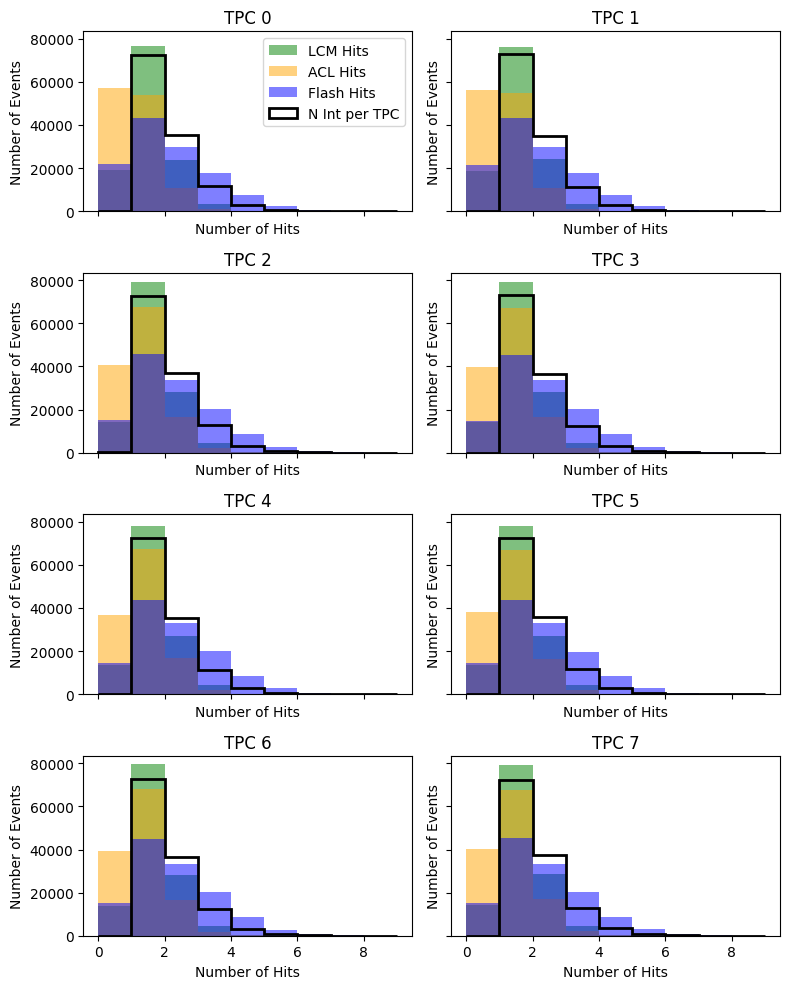

In [7]:
# define df hits: number of acl_hit, lcm_hit, flash per event_id
df_hits = df_truth_reco.groupby(['file_id', 'event_id', 'tpc_num']).agg(
    acl_hits=('trap_0_matched', 'sum'),
    lcm_hits=('trap_1_matched', 'sum'),
    flash_hits=('flash_matched', 'sum')
).reset_index()

# get n_int_per_tpc per unique file_id, event_id, tpc_num
df_int = df_truth_reco[['file_id', 'event_id', 'tpc_num', 'n_int_per_tpc']].drop_duplicates()

# merge df_hits and df_int on file_id, event_id, tpc_num
df_hits = pd.merge(df_hits, df_int, on=['file_id', 'event_id', 'tpc_num'], how='left')

print(df_hits.head().to_string(index=False))

# Define bins for histograms
bins = np.arange(0, 10, 1)
fig, axs = plt.subplots(4, 2, figsize=(8, 10), sharex=True, sharey=True)
tpc_nums = range(8)

for i, tpc in enumerate(tpc_nums):
  ax = axs[i // 2, i % 2]
  mask = df_hits['tpc_num'] == tpc
  ax.hist(df_hits.loc[mask, 'lcm_hits'], bins=bins, alpha=0.5, label='LCM Hits', color='green')
  ax.hist(df_hits.loc[mask, 'acl_hits'], bins=bins, alpha=0.5, label='ACL Hits', color='orange')
  ax.hist(df_hits.loc[mask, 'flash_hits'], bins=bins, alpha=0.5, label='Flash Hits', color='blue')
  # overlay n_int_per_tpc hist as black line (step)
  ax.hist(df_hits.loc[mask, 'n_int_per_tpc'], bins=bins, histtype='step', linewidth=2, label='N Int per TPC', color='black')
  ax.set_title(f'TPC {tpc}')
  ax.set_xlabel('Number of Hits')
  ax.set_ylabel('Number of Events')
  if i == 0:
    ax.legend()

plt.tight_layout()
plt.show()

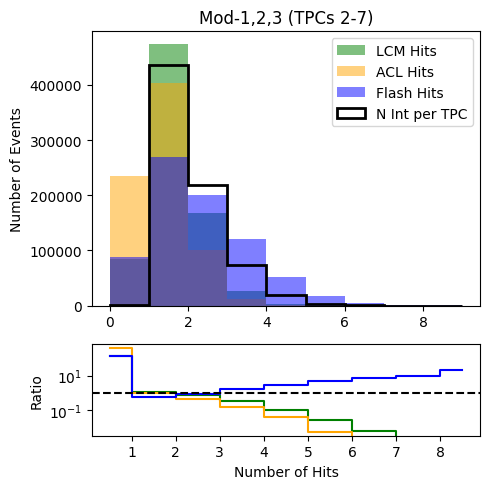

In [8]:
# include ratio subplot and combine TPCs into single plot (just Mod-1,2,3)

bins = np.arange(0, 10, 1)
fig, axs = plt.subplots(2, 1, figsize=(5, 5), gridspec_kw={'height_ratios': [3, 1]})

mask = (df_hits['tpc_num'] != 0) & (df_hits['tpc_num'] != 1)

# Histograms
hist_lcm, _ = np.histogram(df_hits.loc[mask, 'lcm_hits'], bins=bins)
hist_acl, _ = np.histogram(df_hits.loc[mask, 'acl_hits'], bins=bins)
hist_flash, _ = np.histogram(df_hits.loc[mask, 'flash_hits'], bins=bins)
hist_nint, _ = np.histogram(df_hits.loc[mask, 'n_int_per_tpc'], bins=bins)
bin_centers = (bins[:-1] + bins[1:]) / 2

axs[0].hist(df_hits.loc[mask, 'lcm_hits'], bins=bins, alpha=0.5, label='LCM Hits', color='green')
axs[0].hist(df_hits.loc[mask, 'acl_hits'], bins=bins, alpha=0.5, label='ACL Hits', color='orange')
axs[0].hist(df_hits.loc[mask, 'flash_hits'], bins=bins, alpha=0.5, label='Flash Hits', color='blue')
axs[0].hist(df_hits.loc[mask, 'n_int_per_tpc'], bins=bins, histtype='step', linewidth=2, label='N Int per TPC', color='black')
axs[0].set_title('Mod-1,2,3 (TPCs 2-7)')
axs[0].set_ylabel('Number of Events')
axs[0].legend()

# Ratio plots
ratio_lcm = np.divide(hist_lcm, hist_nint, out=np.zeros_like(hist_lcm, dtype=float), where=hist_nint != 0)
ratio_acl = np.divide(hist_acl, hist_nint, out=np.zeros_like(hist_acl, dtype=float), where=hist_nint != 0)
ratio_flash = np.divide(hist_flash, hist_nint, out=np.zeros_like(hist_flash, dtype=float), where=hist_nint != 0)

axs[1].step(bin_centers, ratio_lcm, where='mid', label='LCM/N Int', color='green')
axs[1].step(bin_centers, ratio_acl, where='mid', label='ACL/N Int', color='orange')
axs[1].step(bin_centers, ratio_flash, where='mid', label='Flash/N Int', color='blue')
axs[1].axhline(1, color='black', linestyle='--')
axs[1].set_ylabel('Ratio')
axs[1].set_xlabel('Number of Hits')
#axs[1].set_ylim(0, 2.0)
axs[1].set_yscale('log')

plt.tight_layout()
plt.show()

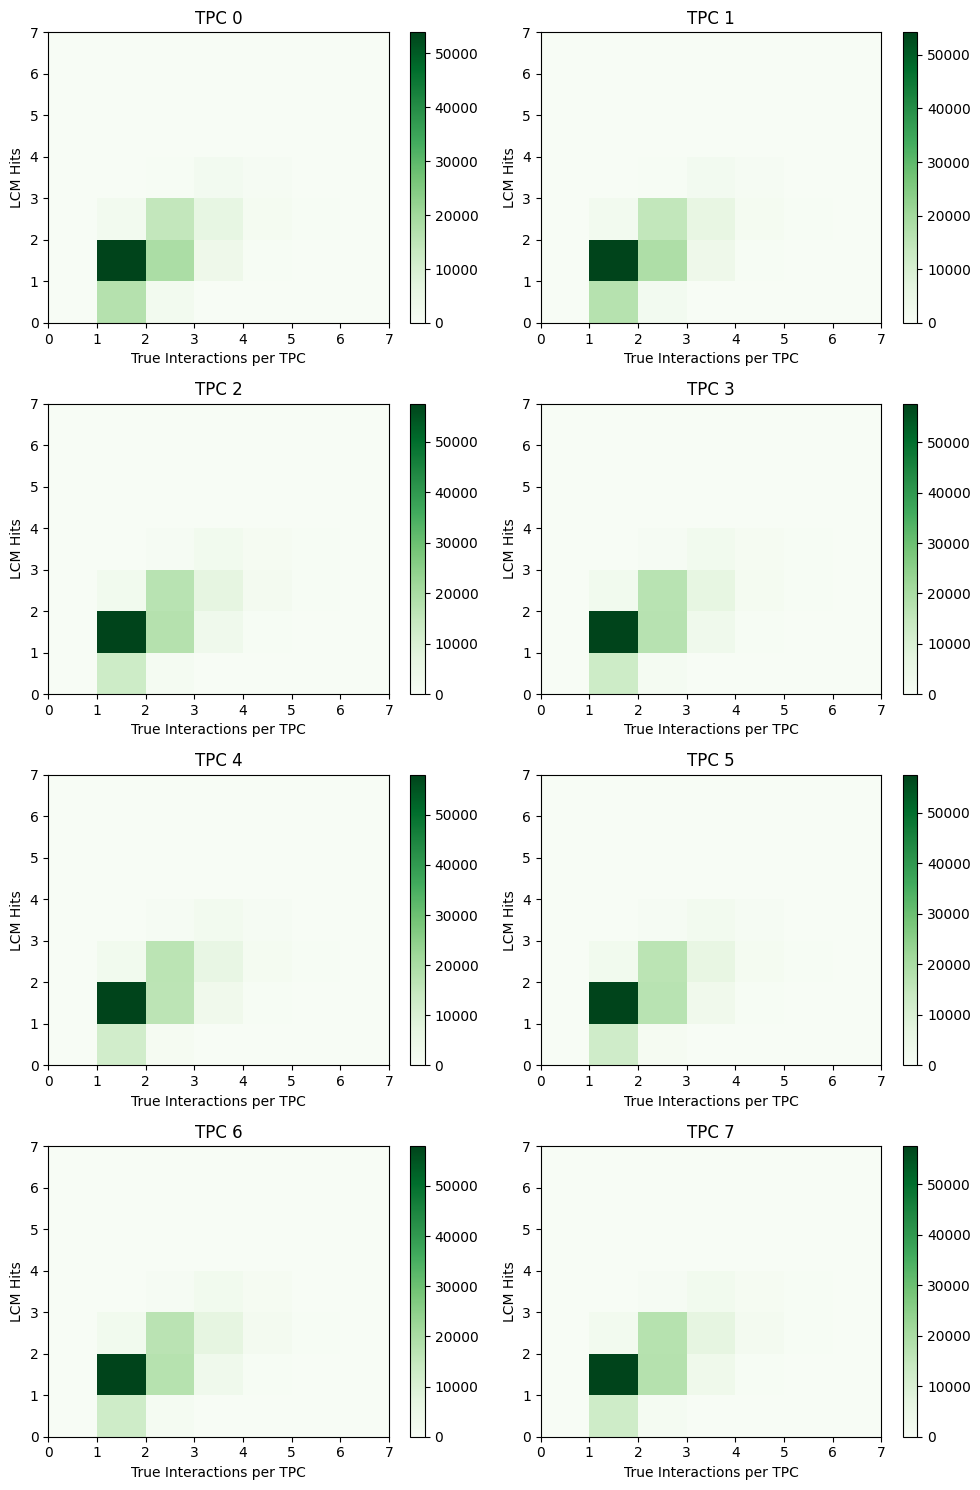

In [9]:
# plot a confusion matrix for lcm hits vs true int per tpc
# for each tpc_num, plot a 2D histogram of lcm_hits vs n_int_per_tpc
bins = np.arange(0, 8, 1)

fig, axs = plt.subplots(4, 2, figsize=(10, 15))
tpc_nums = range(8)
for i, tpc in enumerate(tpc_nums):
    ax = axs[i // 2, i % 2]
    mask = df_hits['tpc_num'] == tpc
    from matplotlib.colors import LogNorm
    h = ax.hist2d(
        df_hits.loc[mask, 'n_int_per_tpc'],
        df_hits.loc[mask, 'lcm_hits'],
        bins=[bins, bins],
        cmap='Greens',
        #norm=LogNorm()
    )
    ax.set_title(f'TPC {tpc}')
    ax.set_xlabel('True Interactions per TPC')
    ax.set_ylabel('LCM Hits')
    plt.colorbar(h[3], ax=ax)

plt.tight_layout()
plt.show()



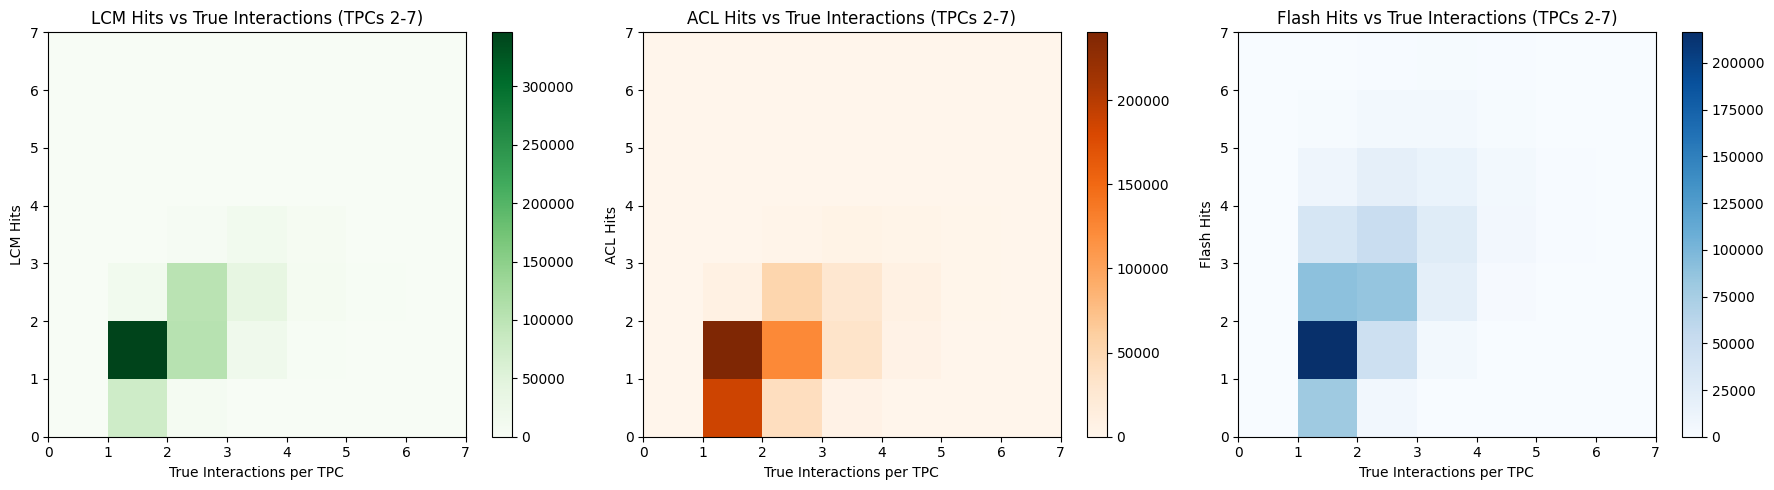

In [10]:
# plot a confusion matrix for lcm hits vs true int per tpc
# plot a 2D histogram of lcm_hits vs n_int_per_tpc
from matplotlib.colors import LogNorm
np.arange(0, 8, 1)

fig, ax = plt.subplots(1, 3, figsize=(18, 5))
mask = (df_hits['tpc_num'] != 0) & (df_hits['tpc_num'] != 1)

h = ax[0].hist2d(
    df_hits.loc[mask, 'n_int_per_tpc'],
    df_hits.loc[mask, 'lcm_hits'],
    bins=[bins, bins],
    cmap='Greens',
    #norm=LogNorm()
)
ax[0].set_title('LCM Hits vs True Interactions (TPCs 2-7)')
ax[0].set_xlabel('True Interactions per TPC')
ax[0].set_ylabel('LCM Hits')
plt.colorbar(h[3], ax=ax[0])

# ACLs
h = ax[1].hist2d(
    df_hits.loc[mask, 'n_int_per_tpc'],
    df_hits.loc[mask, 'acl_hits'],
    bins=[bins, bins],
    cmap='Oranges',
    #norm=LogNorm()
)
ax[1].set_title('ACL Hits vs True Interactions (TPCs 2-7)')
ax[1].set_xlabel('True Interactions per TPC')
ax[1].set_ylabel('ACL Hits')
plt.colorbar(h[3], ax=ax[1])

# flashes
h = ax[2].hist2d(
    df_hits.loc[mask, 'n_int_per_tpc'],
    df_hits.loc[mask, 'flash_hits'],
    bins=[bins, bins],
    cmap='Blues',
    #norm=LogNorm()
)
ax[2].set_title('Flash Hits vs True Interactions (TPCs 2-7)')
ax[2].set_xlabel('True Interactions per TPC')
ax[2].set_ylabel('Flash Hits')
plt.colorbar(h[3], ax=ax[2])

plt.tight_layout()
plt.show()

In [13]:
# add dtime_ns as residual between interaction time and reco hit in ns
df_truth_reco['trap_0_dtime_ns'] = df_truth_reco['trap_0_dtime'] * 1e3
df_truth_reco['trap_1_dtime_ns'] = df_truth_reco['trap_1_dtime'] * 1e3
df_truth_reco['flash_dtime_ns'] = df_truth_reco['flash_dtime'] * 1e3

# all interactions
all_true = df_truth_reco[df_truth_reco['vertex_id'].notna()]

acl_rec = df_truth_reco[df_truth_reco['trap_0_matched'] == 1]
acl_true_rec = df_truth_reco[(df_truth_reco['trap_0_matched'] == 1) & (df_truth_reco['vertex_id'].notna())]

lcm_rec = df_truth_reco[df_truth_reco['trap_1_matched'] == 1]
lcm_true_rec = df_truth_reco[(df_truth_reco['trap_1_matched'] == 1) & (df_truth_reco['vertex_id'].notna())]
flash_rec = df_truth_reco[df_truth_reco['flash_matched'] == 1]
flash_true_rec = df_truth_reco[(df_truth_reco['flash_matched'] == 1) & (df_truth_reco['vertex_id'].notna())]


# 1 interaction
all_true_1int = all_true[all_true['n_int_per_tpc'] == 1].copy()
df_truth_reco_1int = df_truth_reco[df_truth_reco['n_int_per_tpc'] == 1].copy()

acl_rec_1int = df_truth_reco_1int[df_truth_reco_1int['trap_0_matched'] == 1]
acl_true_rec_1int = df_truth_reco_1int[(df_truth_reco_1int['trap_0_matched'] == 1) & (df_truth_reco_1int['vertex_id'].notna())]

lcm_rec_1int = df_truth_reco_1int[df_truth_reco_1int['trap_1_matched'] == 1]
lcm_true_rec_1int = df_truth_reco_1int[(df_truth_reco_1int['trap_1_matched'] == 1) & (df_truth_reco_1int['vertex_id'].notna())]
flash_rec_1int = df_truth_reco_1int[df_truth_reco_1int['flash_matched'] == 1]
flash_true_rec_1int = df_truth_reco_1int[(df_truth_reco_1int['flash_matched'] == 1) & (df_truth_reco_1int['vertex_id'].notna())]


# 2 interactions
all_true_2int = all_true[all_true['n_int_per_tpc'] == 2].copy()
df_truth_reco_2int = df_truth_reco[df_truth_reco['n_int_per_tpc'] == 2].copy()

acl_rec_2int = df_truth_reco_2int[df_truth_reco_2int['trap_0_matched'] == 1]
acl_true_rec_2int = df_truth_reco_2int[(df_truth_reco_2int['trap_0_matched'] == 1) & (df_truth_reco_2int['vertex_id'].notna())]

lcm_rec_2int = df_truth_reco_2int[df_truth_reco_2int['trap_1_matched'] == 1]
lcm_true_rec_2int = df_truth_reco_2int[(df_truth_reco_2int['trap_1_matched'] == 1) & (df_truth_reco_2int['vertex_id'].notna())]

flash_rec_2int = df_truth_reco_2int[df_truth_reco_2int['flash_matched'] == 1]
flash_true_rec_2int = df_truth_reco_2int[(df_truth_reco_2int['flash_matched'] == 1) & (df_truth_reco_2int['vertex_id'].notna())]

In [14]:
# overall efficiencies

# acl efficiency
acl_eff = len(acl_true_rec) / len(all_true)
acl_eff_cp_int = clopper_pearson_interval_numpy(len(acl_true_rec), len(all_true), 0.05)
print(f"ACL efficiency: {acl_eff:.2f} ({acl_eff_cp_int[0]:.2f}, {acl_eff_cp_int[1]:.2f})")
# acl fake rate
acl_fake = 1 - (len(acl_true_rec) / len(acl_rec))
acl_fake_cp_int = clopper_pearson_interval_numpy(len(acl_rec) - len(acl_true_rec), len(acl_rec), 0.05)
print(f"ACL fake rate: {acl_fake:.2f} ({acl_fake_cp_int[0]:.2f}, {acl_fake_cp_int[1]:.2f})")

# lcm efficiency
lcm_eff = len(lcm_true_rec) / len(all_true)
lcm_eff_cp_int = clopper_pearson_interval_numpy(len(lcm_true_rec), len(all_true), 0.05)
print(f"LCM efficiency: {lcm_eff:.2f} ({lcm_eff_cp_int[0]:.2f}, {lcm_eff_cp_int[1]:.2f})")
# lcm fake rate
lcm_fake = 1 - (len(lcm_true_rec) / len(lcm_rec))
lcm_fake_cp_int = clopper_pearson_interval_numpy(len(lcm_rec) - len(lcm_true_rec), len(lcm_rec), 0.05)
print(f"LCM fake rate: {lcm_fake:.2f} ({lcm_fake_cp_int[0]:.2f}, {lcm_fake_cp_int[1]:.2f})")

# flash efficiency
flash_eff = len(flash_true_rec) / len(all_true)
flash_eff_cp_int = clopper_pearson_interval_numpy(len(flash_true_rec), len(all_true), 0.05)
print(f"Flash efficiency: {flash_eff:.2f} ({flash_eff_cp_int[0]:.2f}, {flash_eff_cp_int[1]:.2f})")
# flash fake rate
flash_fake = 1 - (len(flash_true_rec) / len(flash_rec))
flash_fake_cp_int = clopper_pearson_interval_numpy(len(flash_rec) - len(flash_true_rec), len(flash_rec), 0.05)
print(f"Flash fake rate: {flash_fake:.2f} ({flash_fake_cp_int[0]:.2f}, {flash_fake_cp_int[1]:.2f})")

ACL efficiency: 0.49 (0.49, 0.49)
ACL fake rate: 0.04 (0.03, 0.04)
LCM efficiency: 0.71 (0.71, 0.71)
LCM fake rate: 0.04 (0.04, 0.04)
Flash efficiency: 0.76 (0.76, 0.76)
Flash fake rate: 0.32 (0.32, 0.32)


In [15]:
# plot for comparing different hit types

def plot_histogram_ratio_with_error(df_A, df_B, legend, cols, bins, xlabel, ylabel,
                                    alpha=0.05, neg=False, yscale='linear', xscale='linear'):

    if len(df_A) != len(df_B):
        raise ValueError("df_A and df_B must have the same length")

    # Initialize the plot
    if len(df_A) > 1:
        fig, axs = plt.subplots(2, 1, figsize=(6, 4), gridspec_kw={'height_ratios': [3, 1]}, sharex=True)
        ax = axs[0]
    else:
        fig, ax = plt.subplots(figsize=(8, 4))

    # Iterate over the datasets
    frac_0 = None
    for i, (data_A, data_B) in enumerate(zip(df_A, df_B)):
        # Compute histograms
        hist_A, _ = np.histogram(data_A, bins=bins)
        hist_B, _ = np.histogram(data_B, bins=bins)

        # Compute bin centers
        bin_centers = (bins[:-1])# + bins[1:]) / 2 - 0.5

        # Compute ratio A/B
        frac = np.divide(hist_A, hist_B, out=np.zeros_like(hist_A, dtype=float), where=hist_B != 0)
        frac = 1 - frac if neg else frac

        # Store the first ratio for later use
        if i == 0:
            frac_0 = frac

        # Compute Clopper-Pearson intervals for ratio
        lower_bounds, upper_bounds = clopper_pearson_interval_numpy(hist_A, hist_B, alpha=alpha)
        if neg:
            lower_bounds = 1 - lower_bounds
            upper_bounds = 1 - upper_bounds

        # Plot the ratio with error bands
        ax.step(bin_centers, frac, alpha=0.8, label=legend[i], color=cols[i])
        ax.fill_between(bin_centers, lower_bounds, upper_bounds, step='pre', alpha=0.2, color=cols[i])
        #ax.set_ylim(0,1)

        # Plot the ratio of each entry to frac[0] if len(df_A) > 1
        if len(df_A) > 1:
            axs[1].step(bin_centers, frac / frac_0, alpha=0.8, label=f"Ratio to {legend[0]}", color=cols[i])
            axs[1].fill_between(bin_centers, lower_bounds / frac_0, upper_bounds / frac_0, step='pre', alpha=0.2, color=cols[i])
            axs[1].set_ylabel('Ratio')
            axs[1].set_xlim(bins[0], bins[-2])
            axs[1].set_xlabel(xlabel)
            axs[1].set_ylabel(ylabel)

    # Formatting
    #ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    ax.set_yscale(yscale)
    ax.set_xscale(xscale)

    ax.set_xlim(bins[0], bins[-2])
    ax.legend()

    plt.tight_layout()
    plt.show()


In [16]:
# plot for comparing same hit type with different conditions (in this case, different n_int_per_tpc)

def plot_histogram_ratio_with_error2(df_A, df_B, legend, bins, xlabel, ylabel, alpha=0.05, neg=False, yscale='linear', xscale='linear', hline=None):

    if len(df_A) != len(df_B):
        raise ValueError("df_A and df_B must have the same length")

    # Initialize the plot
    if len(df_A) > 1:
        fig, axs = plt.subplots(2, 1, figsize=(6, 4), gridspec_kw={'height_ratios': [3, 1]}, sharex=True)
        ax = axs[0]
    else:
        fig, ax = plt.subplots(figsize=(8, 4))

    # Iterate over the datasets
    frac_0 = None
    for i, (data_A, data_B) in enumerate(zip(df_A, df_B)):
        # Compute histograms
        hist_A, _ = np.histogram(data_A, bins=bins)
        hist_B, _ = np.histogram(data_B, bins=bins)

        # Compute bin centers
        bin_centers = (bins[:-1])# + bins[1:]) / 2 - 0.5

        # Compute ratio A/B
        frac = np.divide(hist_A, hist_B, out=np.zeros_like(hist_A, dtype=float), where=hist_B != 0)
        frac = 1 - frac if neg else frac

        # Store the first ratio for later use
        if i == 0:
            frac_0 = frac

        # Compute Clopper-Pearson intervals for ratio
        lower_bounds, upper_bounds = clopper_pearson_interval_numpy(hist_A, hist_B, alpha=alpha)
        if neg:
            lower_bounds = 1 - lower_bounds
            upper_bounds = 1 - upper_bounds

        # Plot the ratio with error bands
        ax.step(bin_centers, frac, alpha=0.8, label=legend[i])
        ax.fill_between(bin_centers, lower_bounds, upper_bounds, step='pre', alpha=0.2)
        ax.set_ylim(0,1)

        # Plot the ratio of each entry to frac[0] if len(df_A) > 1
        if len(df_A) > 1:
            axs[1].step(bin_centers, frac / frac_0, alpha=0.8, label=f"Ratio to {legend[0]}")
            axs[1].fill_between(bin_centers, lower_bounds / frac_0, upper_bounds / frac_0, step='pre', alpha=0.2)
            axs[1].set_ylabel('Ratio')
            axs[1].set_xlim(bins[0], bins[-2])
            axs[1].set_xlabel(xlabel)
            axs[1].set_ylabel(ylabel)

    # Formatting
    #ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    ax.set_yscale(yscale)
    ax.set_xscale(xscale)

    ax.set_xlim(bins[0], bins[-2])

    if hline is not None:
        ax.axhline(y=hline, color='k', linestyle='--', label='no pileup')

    ax.legend()

    plt.tight_layout()
    plt.show()


0.7928515706887249 0.8086168797918807 0.5301611412193672 0.8195778505568977


/tmp/ipykernel_215088/725115847.py:47: RuntimeWarning: invalid value encountered in divide
  axs[1].step(bin_centers, frac / frac_0, alpha=0.8, label=f"Ratio to {legend[0]}", color=cols[i])
/tmp/ipykernel_215088/725115847.py:48: RuntimeWarning: invalid value encountered in divide
  axs[1].fill_between(bin_centers, lower_bounds / frac_0, upper_bounds / frac_0, step='pre', alpha=0.2, color=cols[i])
/tmp/ipykernel_215088/725115847.py:48: RuntimeWarning: divide by zero encountered in divide
  axs[1].fill_between(bin_centers, lower_bounds / frac_0, upper_bounds / frac_0, step='pre', alpha=0.2, color=cols[i])


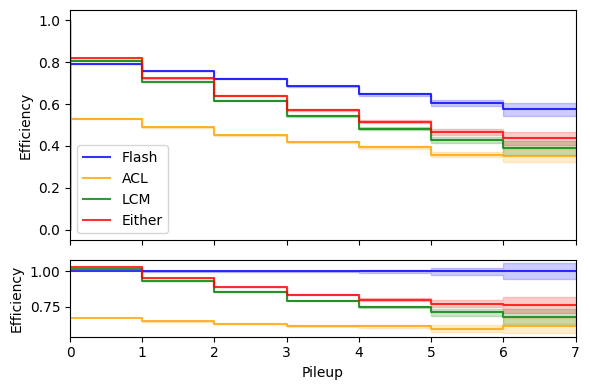

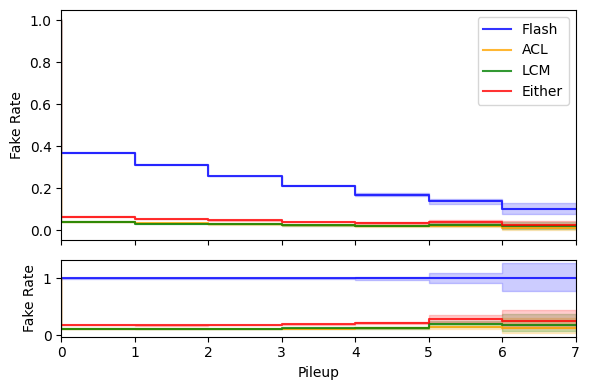

In [18]:
# Define nint histogram bins
all_true_nint = all_true['n_int_per_tpc'].dropna()

acl_reco_nint = acl_rec['n_int_per_tpc'].dropna()
acl_true_reco_nint = acl_true_rec['n_int_per_tpc'].dropna()

lcm_reco_nint = lcm_rec['n_int_per_tpc'].dropna()
lcm_true_reco_nint = lcm_true_rec['n_int_per_tpc'].dropna()

either_reco_nint = df_truth_reco.loc[(df_truth_reco['trap_0_matched'] == True) | (df_truth_reco['trap_1_matched'] == True), 'n_int_per_tpc'].dropna()
either_true_reco_nint = df_truth_reco.loc[(df_truth_reco['vertex_id'].notna()) & ((df_truth_reco['trap_0_matched'] == True) | (df_truth_reco['trap_1_matched'] == True)), 'n_int_per_tpc'].dropna()

flash_reco_nint = flash_rec['n_int_per_tpc'].dropna()
flash_true_reco_nint = flash_true_rec['n_int_per_tpc'].dropna()

xrange = (0, 7)  # Range for the histogram bins
bins = np.linspace(xrange[0], xrange[1]+1, xrange[1]+2)

# print efficiency for first bin (1 interaction)
flash_1int_eff = len(flash_true_reco_nint[flash_true_reco_nint == 1]) / len(all_true_nint[all_true_nint == 1])
lcm_1int_eff = len(lcm_true_reco_nint[lcm_true_reco_nint == 1]) / len(all_true_nint[all_true_nint == 1])
acl_1int_eff = len(acl_true_reco_nint[acl_true_reco_nint == 1]) / len(all_true_nint[all_true_nint == 1])
either_1int_eff = len(either_true_reco_nint[either_true_reco_nint == 1]) / len(all_true_nint[all_true_nint == 1])
print(flash_1int_eff, lcm_1int_eff, acl_1int_eff, either_1int_eff)


# Plot the ratio of the two histograms with Clopper-Pearson intervals
plot_histogram_ratio_with_error(
    df_A=[flash_true_reco_nint, acl_true_reco_nint, lcm_true_reco_nint, either_true_reco_nint],
    df_B=[all_true_nint, all_true_nint, all_true_nint, all_true_nint],
    legend=['Flash', 'ACL', 'LCM', 'Either'],
    cols=['blue', 'orange', 'green', 'red'],
    bins=bins,
    xlabel='Pileup',
    ylabel='Efficiency'
)


# Fake rate here will assume anything below threshold is fake, either:
# - remake with minimal threshold for fake rate plots
# - threshold for n_photons_det should be better
# - get full truth backtracking for light fixed!

# Plot the ratio of the two histograms with Clopper-Pearson intervals
plot_histogram_ratio_with_error(
    df_A=[flash_true_reco_nint, acl_true_reco_nint, lcm_true_reco_nint, either_true_reco_nint],
    df_B=[flash_reco_nint, acl_reco_nint, lcm_reco_nint, either_reco_nint],
    legend=['Flash', 'ACL', 'LCM', 'Either'],
    cols=['blue', 'orange', 'green', 'red'],
    bins=bins,
    xlabel='Pileup',
    ylabel='Fake Rate',
    neg=True,
)

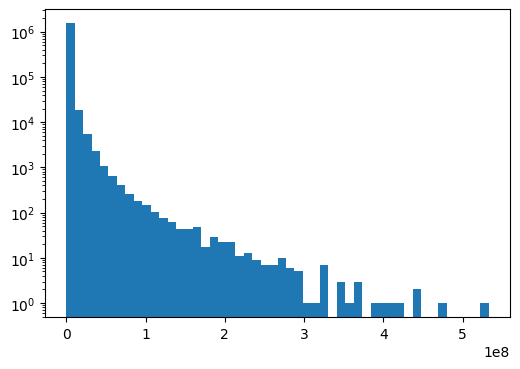

/tmp/ipykernel_215088/725115847.py:47: RuntimeWarning: invalid value encountered in divide
  axs[1].step(bin_centers, frac / frac_0, alpha=0.8, label=f"Ratio to {legend[0]}", color=cols[i])
/tmp/ipykernel_215088/725115847.py:48: RuntimeWarning: invalid value encountered in divide
  axs[1].fill_between(bin_centers, lower_bounds / frac_0, upper_bounds / frac_0, step='pre', alpha=0.2, color=cols[i])
/tmp/ipykernel_215088/725115847.py:48: RuntimeWarning: divide by zero encountered in divide
  axs[1].fill_between(bin_centers, lower_bounds / frac_0, upper_bounds / frac_0, step='pre', alpha=0.2, color=cols[i])


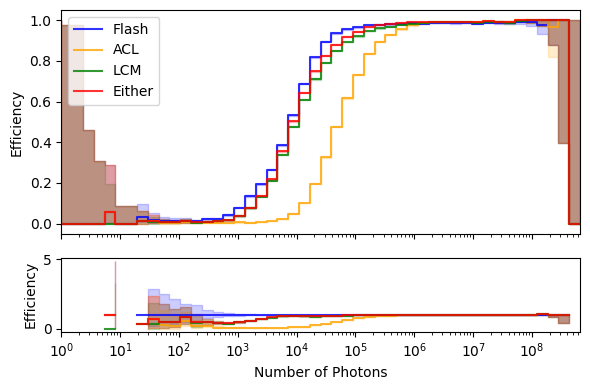

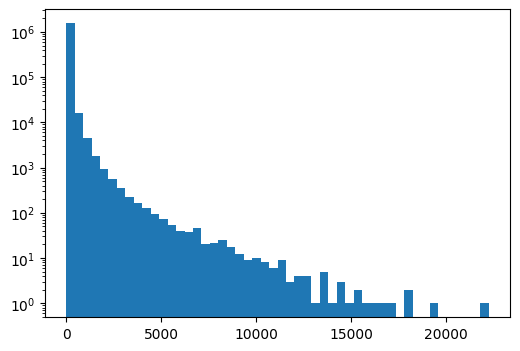

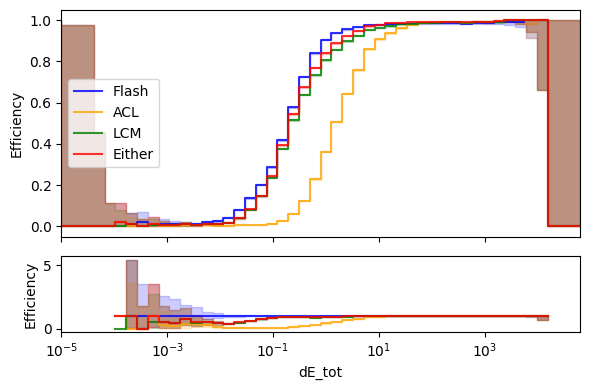

In [25]:
# Define n_photons histogram bins
all_true_nphotons = all_true['nphoton_tot'].dropna()

acl_reco_nphotons = acl_rec['nphoton_tot'].dropna()
acl_true_reco_nphotons = acl_true_rec['nphoton_tot'].dropna()

lcm_reco_nphotons = lcm_rec['nphoton_tot'].dropna()
lcm_true_reco_nphotons = lcm_true_rec['nphoton_tot'].dropna()

either_reco_nphotons = df_truth_reco.loc[(df_truth_reco['trap_0_matched'] == True) | (df_truth_reco['trap_1_matched'] == True), 'nphoton_tot'].dropna()
either_true_reco_nphotons = df_truth_reco.loc[(df_truth_reco['vertex_id'].notna()) & ((df_truth_reco['trap_0_matched'] == True) | (df_truth_reco['trap_1_matched'] == True)), 'nphoton_tot'].dropna()

flash_reco_nphotons = flash_rec['nphoton_tot'].dropna()
flash_true_reco_nphotons = flash_true_rec['nphoton_tot'].dropna()

# plot the histogram of nphoton_tot for all_true
plt.figure(figsize=(6,4))
plt.hist(all_true_nphotons, bins=50)
plt.yscale('log')
plt.show()

# Define histogram bins
xrange = (0, 9)  # Range for the histogram bins
bins = np.logspace(xrange[0], xrange[1], num=50, base=10)
# Plot the ratio of the two histograms with Clopper-Pearson intervals
plot_histogram_ratio_with_error(
    df_A=[flash_true_reco_nphotons, acl_true_reco_nphotons, lcm_true_reco_nphotons, either_true_reco_nphotons],
    df_B=[all_true_nphotons, all_true_nphotons, all_true_nphotons, all_true_nphotons],
    legend=['Flash', 'ACL', 'LCM', 'Either'],
    cols=['blue', 'orange', 'green', 'red'],
    bins=bins,
    xlabel='Number of Photons',
    ylabel='Efficiency',
    xscale='log'
)



# Define dE_tot histogram bins
all_true_dE = all_true['dE_tot'].dropna()

acl_reco_dE = acl_rec['dE_tot'].dropna()
acl_true_reco_dE = acl_true_rec['dE_tot'].dropna()

lcm_reco_dE = lcm_rec['dE_tot'].dropna()
lcm_true_reco_dE = lcm_true_rec['dE_tot'].dropna()

either_reco_dE = df_truth_reco.loc[(df_truth_reco['trap_0_matched'] == True) | (df_truth_reco['trap_1_matched'] == True), 'dE_tot'].dropna()
either_true_reco_dE = df_truth_reco.loc[(df_truth_reco['vertex_id'].notna()) & ((df_truth_reco['trap_0_matched'] == True) | (df_truth_reco['trap_1_matched'] == True)), 'dE_tot'].dropna()

flash_reco_dE = flash_rec['dE_tot'].dropna()
flash_true_reco_dE = flash_true_rec['dE_tot'].dropna()

# plot the histogram of dE_tot for all_true
plt.figure(figsize=(6,4))
plt.hist(all_true_dE, bins=50)
plt.yscale('log')
plt.show()

# Define histogram bins
xrange = (-5, 5)  # Range for the histogram bins
bins = np.logspace(xrange[0], xrange[1], num=50, base=10)
# Plot the ratio of the two histograms with Clopper-Pearson intervals
plot_histogram_ratio_with_error(
    df_A=[flash_true_reco_dE, acl_true_reco_dE, lcm_true_reco_dE, either_true_reco_dE],
    df_B=[all_true_dE, all_true_dE, all_true_dE, all_true_dE],
    legend=['Flash', 'ACL', 'LCM', 'Either'],
    cols=['blue', 'orange', 'green', 'red'],
    bins=bins,
    xlabel='dE_tot',
    ylabel='Efficiency',
    xscale='log'
)

/tmp/ipykernel_215088/725115847.py:47: RuntimeWarning: invalid value encountered in divide
  axs[1].step(bin_centers, frac / frac_0, alpha=0.8, label=f"Ratio to {legend[0]}", color=cols[i])
/tmp/ipykernel_215088/725115847.py:48: RuntimeWarning: invalid value encountered in divide
  axs[1].fill_between(bin_centers, lower_bounds / frac_0, upper_bounds / frac_0, step='pre', alpha=0.2, color=cols[i])
/tmp/ipykernel_215088/725115847.py:48: RuntimeWarning: divide by zero encountered in divide
  axs[1].fill_between(bin_centers, lower_bounds / frac_0, upper_bounds / frac_0, step='pre', alpha=0.2, color=cols[i])


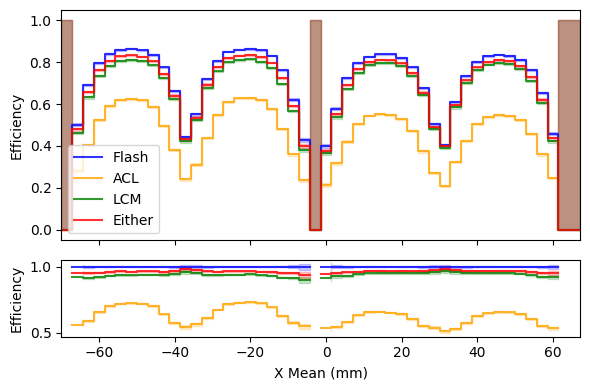

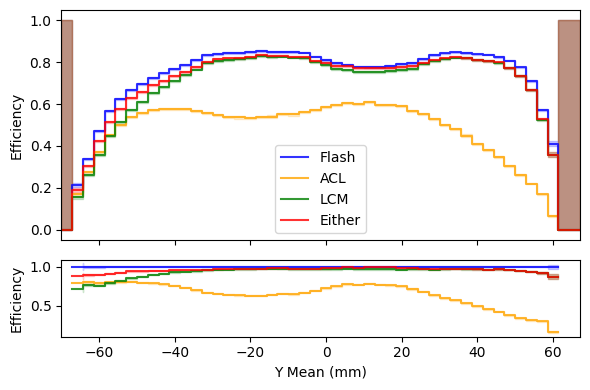

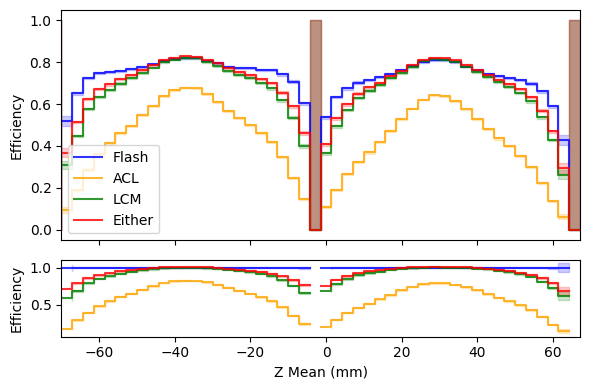

In [28]:
# x_mean, y_mean, z_mean
all_true_x = all_true['x_mean_int'].dropna()
acl_reco_x = acl_rec['x_mean_int'].dropna()
acl_true_reco_x = acl_true_rec['x_mean_int'].dropna()
lcm_reco_x = lcm_rec['x_mean_int'].dropna()
lcm_true_reco_x = lcm_true_rec['x_mean_int'].dropna()
either_reco_x = df_truth_reco.loc[(df_truth_reco['trap_0_matched'] == True) | (df_truth_reco['trap_1_matched'] == True), 'x_mean_int'].dropna()
either_true_reco_x = df_truth_reco.loc[(df_truth_reco['vertex_id'].notna()) & ((df_truth_reco['trap_0_matched'] == True) | (df_truth_reco['trap_1_matched'] == True)), 'x_mean_int'].dropna()
flash_reco_x = flash_rec['x_mean_int'].dropna()
flash_true_reco_x = flash_true_rec['x_mean_int'].dropna()

# Define histogram bins
xrange = (-70, 70)  # Range for the histogram bins
bins = np.linspace(xrange[0], xrange[1], 50)  # 100 bins from -70 to 70
# Plot the ratio of the two histograms with Clopper-Pearson intervals
plot_histogram_ratio_with_error(
    df_A=[flash_true_reco_x, acl_true_reco_x, lcm_true_reco_x, either_true_reco_x],
    df_B=[all_true_x, all_true_x, all_true_x, all_true_x],
    legend=['Flash', 'ACL', 'LCM', 'Either'],
    cols=['blue', 'orange', 'green', 'red'],
    bins=bins,
    xlabel='X Mean (mm)',
    ylabel='Efficiency',
)


# y_mean
all_true_y = all_true['y_mean_int'].dropna()
acl_reco_y = acl_rec['y_mean_int'].dropna()
acl_true_reco_y = acl_true_rec['y_mean_int'].dropna()
lcm_reco_y = lcm_rec['y_mean_int'].dropna()
lcm_true_reco_y = lcm_true_rec['y_mean_int'].dropna()
either_reco_y = df_truth_reco.loc[(df_truth_reco['trap_0_matched'] == True) | (df_truth_reco['trap_1_matched'] == True), 'y_mean_int'].dropna()
either_true_reco_y = df_truth_reco.loc[(df_truth_reco['vertex_id'].notna()) & ((df_truth_reco['trap_0_matched'] == True) | (df_truth_reco['trap_1_matched'] == True)), 'y_mean_int'].dropna()
flash_reco_y = flash_rec['y_mean_int'].dropna()
flash_true_reco_y = flash_true_rec['y_mean_int'].dropna()

# Define histogram bins
xrange = (-70, 70)  # Range for the histogram bins
bins = np.linspace(xrange[0], xrange[1], 50)  # 100 bins from -70 to 70
# Plot the ratio of the two histograms with Clopper-Pearson intervals
plot_histogram_ratio_with_error(
    df_A=[flash_true_reco_y, acl_true_reco_y, lcm_true_reco_y, either_true_reco_y],
    df_B=[all_true_y, all_true_y, all_true_y, all_true_y],
    legend=['Flash', 'ACL', 'LCM', 'Either'],
    cols=['blue', 'orange', 'green', 'red'],
    bins=bins,
    xlabel='Y Mean (mm)',
    ylabel='Efficiency',
)


# z_mean
all_true_z = all_true['z_mean_int'].dropna()
acl_reco_z = acl_rec['z_mean_int'].dropna()
acl_true_reco_z = acl_true_rec['z_mean_int'].dropna()
lcm_reco_z = lcm_rec['z_mean_int'].dropna()
lcm_true_reco_z = lcm_true_rec['z_mean_int'].dropna()
either_reco_z = df_truth_reco.loc[(df_truth_reco['trap_0_matched'] == True) | (df_truth_reco['trap_1_matched'] == True), 'z_mean_int'].dropna()
either_true_reco_z = df_truth_reco.loc[(df_truth_reco['vertex_id'].notna()) & ((df_truth_reco['trap_0_matched'] == True) | (df_truth_reco['trap_1_matched'] == True)), 'z_mean_int'].dropna()
flash_reco_z = flash_rec['z_mean_int'].dropna()
flash_true_reco_z = flash_true_rec['z_mean_int'].dropna()

# Define histogram bins
xrange = (-70, 70)  # Range for the histogram bins
bins = np.linspace(xrange[0], xrange[1], 50)  # 100 bins from -70 to 70
# Plot the ratio of the two histograms with Clopper-Pearson intervals
plot_histogram_ratio_with_error(
    df_A=[flash_true_reco_z, acl_true_reco_z, lcm_true_reco_z, either_true_reco_z],
    df_B=[all_true_z, all_true_z, all_true_z, all_true_z],
    legend=['Flash', 'ACL', 'LCM', 'Either'],
    cols=['blue', 'orange', 'green', 'red'],
    bins=bins,
    xlabel='Z Mean (mm)',
    ylabel='Efficiency',
)

/tmp/ipykernel_215088/725115847.py:47: RuntimeWarning: invalid value encountered in divide
  axs[1].step(bin_centers, frac / frac_0, alpha=0.8, label=f"Ratio to {legend[0]}", color=cols[i])
/tmp/ipykernel_215088/725115847.py:48: RuntimeWarning: invalid value encountered in divide
  axs[1].fill_between(bin_centers, lower_bounds / frac_0, upper_bounds / frac_0, step='pre', alpha=0.2, color=cols[i])
/tmp/ipykernel_215088/725115847.py:48: RuntimeWarning: divide by zero encountered in divide
  axs[1].fill_between(bin_centers, lower_bounds / frac_0, upper_bounds / frac_0, step='pre', alpha=0.2, color=cols[i])


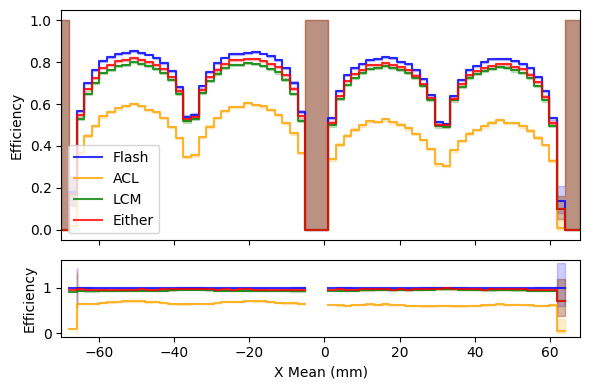

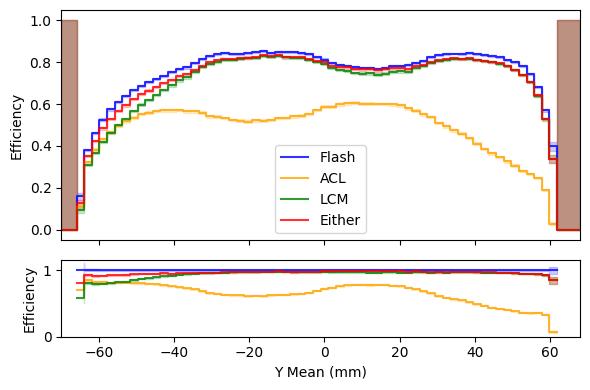

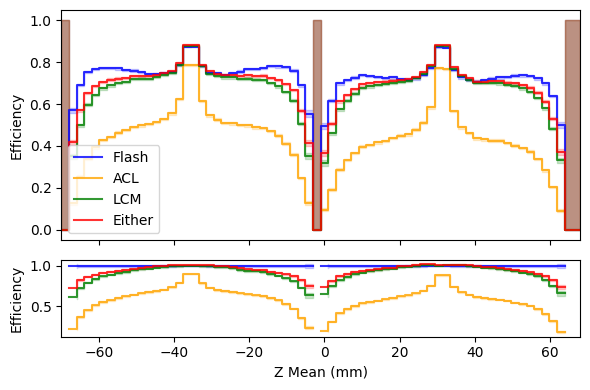

In [29]:
# x_mean, y_mean, z_mean
all_true_x = all_true['x_wmean_int'].dropna()
acl_reco_x = acl_rec['x_wmean_int'].dropna()
acl_true_reco_x = acl_true_rec['x_wmean_int'].dropna()
lcm_reco_x = lcm_rec['x_wmean_int'].dropna()
lcm_true_reco_x = lcm_true_rec['x_wmean_int'].dropna()
either_reco_x = df_truth_reco.loc[(df_truth_reco['trap_0_matched'] == True) | (df_truth_reco['trap_1_matched'] == True), 'x_wmean_int'].dropna()
either_true_reco_x = df_truth_reco.loc[(df_truth_reco['vertex_id'].notna()) & ((df_truth_reco['trap_0_matched'] == True) | (df_truth_reco['trap_1_matched'] == True)), 'x_wmean_int'].dropna()
flash_reco_x = flash_rec['x_wmean_int'].dropna()
flash_true_reco_x = flash_true_rec['x_wmean_int'].dropna()

# Define histogram bins
xrange = (-70, 70)  # Range for the histogram bins
bins = np.linspace(xrange[0], xrange[1], 70)  # 100 bins from -70 to 70
# Plot the ratio of the two histograms with Clopper-Pearson intervals
plot_histogram_ratio_with_error(
    df_A=[flash_true_reco_x, acl_true_reco_x, lcm_true_reco_x, either_true_reco_x],
    df_B=[all_true_x, all_true_x, all_true_x, all_true_x],
    legend=['Flash', 'ACL', 'LCM', 'Either'],
    cols=['blue', 'orange', 'green', 'red'],
    bins=bins,
    xlabel='X Mean (mm)',
    ylabel='Efficiency',
)



# y_mean
all_true_y = all_true['y_wmean_int'].dropna()
acl_reco_y = acl_rec['y_wmean_int'].dropna()
acl_true_reco_y = acl_true_rec['y_wmean_int'].dropna()
lcm_reco_y = lcm_rec['y_wmean_int'].dropna()
lcm_true_reco_y = lcm_true_rec['y_wmean_int'].dropna()
either_reco_y = df_truth_reco.loc[(df_truth_reco['trap_0_matched'] == True) | (df_truth_reco['trap_1_matched'] == True), 'y_wmean_int'].dropna()
either_true_reco_y = df_truth_reco.loc[(df_truth_reco['vertex_id'].notna()) & ((df_truth_reco['trap_0_matched'] == True) | (df_truth_reco['trap_1_matched'] == True)), 'y_wmean_int'].dropna()
flash_reco_y = flash_rec['y_wmean_int'].dropna()
flash_true_reco_y = flash_true_rec['y_wmean_int'].dropna()

# Define histogram bins
xrange = (-70, 70)  # Range for the histogram bins
bins = np.linspace(xrange[0], xrange[1], 70)  # 100 bins from -70 to 70
# Plot the ratio of the two histograms with Clopper-Pearson intervals
plot_histogram_ratio_with_error(
    df_A=[flash_true_reco_y, acl_true_reco_y, lcm_true_reco_y, either_true_reco_y],
    df_B=[all_true_y, all_true_y, all_true_y, all_true_y],
    legend=['Flash', 'ACL', 'LCM', 'Either'],
    cols=['blue', 'orange', 'green', 'red'],
    bins=bins,
    xlabel='Y Mean (mm)',
    ylabel='Efficiency',
)


# z_mean
all_true_z = all_true['z_wmean_int'].dropna()
acl_reco_z = acl_rec['z_wmean_int'].dropna()
acl_true_reco_z = acl_true_rec['z_wmean_int'].dropna()
lcm_reco_z = lcm_rec['z_wmean_int'].dropna()
lcm_true_reco_z = lcm_true_rec['z_wmean_int'].dropna()
either_reco_z = df_truth_reco.loc[(df_truth_reco['trap_0_matched'] == True) | (df_truth_reco['trap_1_matched'] == True), 'z_wmean_int'].dropna()
either_true_reco_z = df_truth_reco.loc[(df_truth_reco['vertex_id'].notna()) & ((df_truth_reco['trap_0_matched'] == True) | (df_truth_reco['trap_1_matched'] == True)), 'z_wmean_int'].dropna()
flash_reco_z = flash_rec['z_wmean_int'].dropna()
flash_true_reco_z = flash_true_rec['z_wmean_int'].dropna()

# Define histogram bins
xrange = (-70, 70)  # Range for the histogram bins
bins = np.linspace(xrange[0], xrange[1], 70)  # 100 bins from -70 to 70
# Plot the ratio of the two histograms with Clopper-Pearson intervals
plot_histogram_ratio_with_error(
    df_A=[flash_true_reco_z, acl_true_reco_z, lcm_true_reco_z, either_true_reco_z],
    df_B=[all_true_z, all_true_z, all_true_z, all_true_z],
    legend=['Flash', 'ACL', 'LCM', 'Either'],
    cols=['blue', 'orange', 'green', 'red'],
    bins=bins,
    xlabel='Z Mean (mm)',
    ylabel='Efficiency',
)

In [30]:
# Use subplots to include x, y, z next to one another for efficiency plots
def plot_histogram_ratio_with_error_side_by_side(
    df_A_list, df_B_list, legend, cols, bins, xlabel_list, ylabel, alpha=0.05,
    neg=False, yscale='linear', xscale='linear', hline=None):

    # df_A_list and df_B_list are lists of lists: [[x_A, ...], [y_A, ...], [z_A, ...]], same for B
    fig, axs = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
    xyz_labels = ['X', 'Y', 'Z']
    for idx, ax in enumerate(axs):
        df_A = df_A_list[idx]
        df_B = df_B_list[idx]
        for i, (data_A, data_B) in enumerate(zip(df_A, df_B)):
            hist_A, _ = np.histogram(data_A, bins=bins)
            hist_B, _ = np.histogram(data_B, bins=bins)
            bin_centers = bins[:-1]
            frac = np.divide(hist_A, hist_B, out=np.zeros_like(hist_A, dtype=float), where=hist_B != 0)
            frac = 1 - frac if neg else frac
            lower_bounds, upper_bounds = clopper_pearson_interval_numpy(hist_A, hist_B, alpha=alpha)
            if neg:
                lower_bounds = 1 - lower_bounds
                upper_bounds = 1 - upper_bounds
            ax.step(bin_centers, frac, alpha=0.8, label=legend[i], color=cols[i])
            ax.fill_between(bin_centers, lower_bounds, upper_bounds, step='pre', alpha=0.2, color=cols[i])
        ax.set_xlabel(xlabel_list[idx])
        ax.set_yscale(yscale)
        ax.set_xscale(xscale)
        ax.set_xlim(bins[0], bins[-2])
        ax.set_ylim(0, 1)
        if hline is not None:
            ax.axhline(y=hline, color='k', linestyle='--', label='no pileup')
        ax.set_title(f'{xyz_labels[idx]} Mean')
        if idx == 0:
            ax.set_ylabel(ylabel)
        ax.legend()
    plt.tight_layout()
    plt.show()

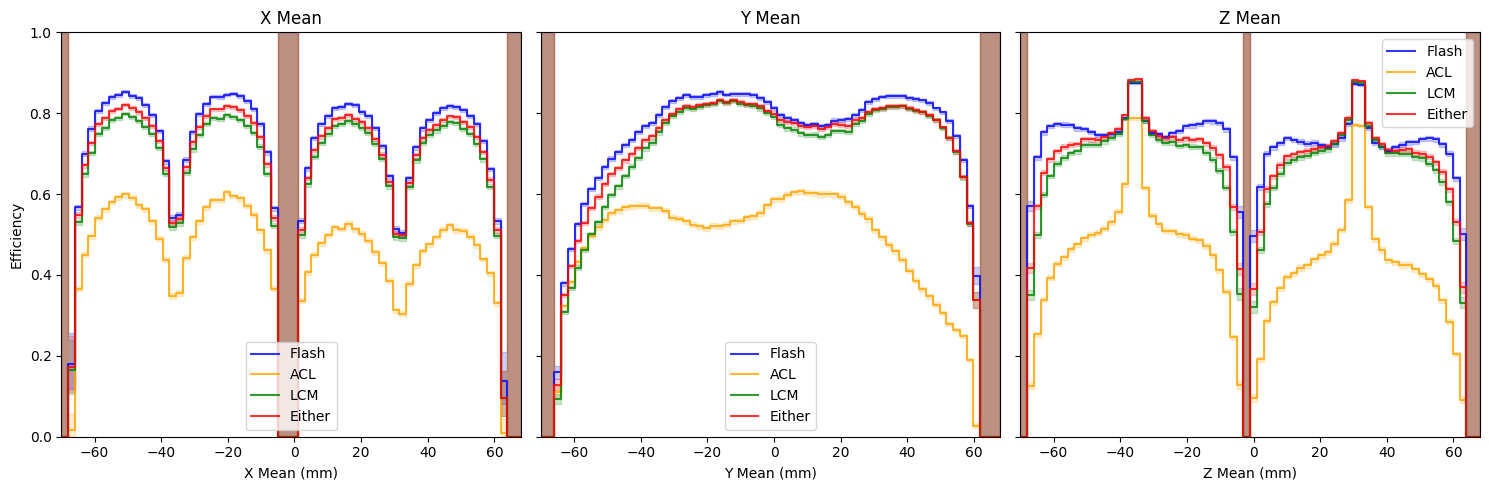

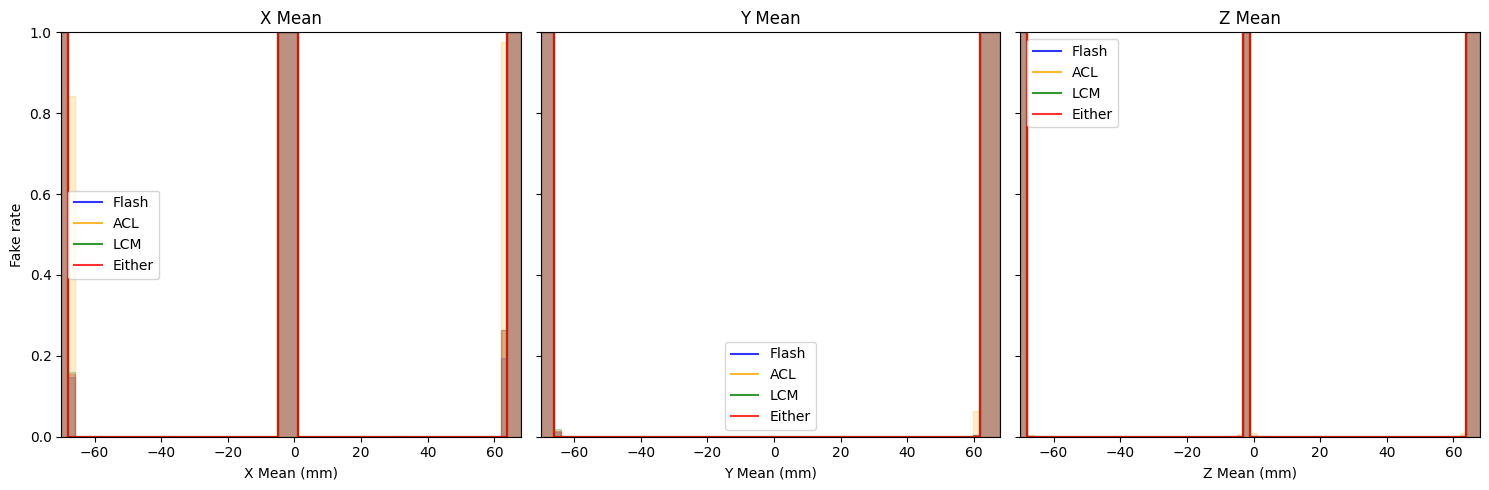

In [33]:
# Use subplots to include x, y, z next to one another for efficiency plots
plot_histogram_ratio_with_error_side_by_side(
    df_A_list=[
        [flash_true_reco_x, acl_true_reco_x, lcm_true_reco_x, either_true_reco_x],
        [flash_true_reco_y, acl_true_reco_y, lcm_true_reco_y, either_true_reco_y],
        [flash_true_reco_z, acl_true_reco_z, lcm_true_reco_z, either_true_reco_z]
    ],
    df_B_list=[
        [all_true_x, all_true_x, all_true_x, all_true_x],
        [all_true_y, all_true_y, all_true_y, all_true_y],
        [all_true_z, all_true_z, all_true_z, all_true_z]
    ],
    legend=['Flash', 'ACL', 'LCM', 'Either'],
    cols=['blue', 'orange', 'green', 'red'],
    bins=bins,
    xlabel_list=['X Mean (mm)', 'Y Mean (mm)', 'Z Mean (mm)'],
    ylabel='Efficiency'
)

# This doesnt look right! not sure why!
# repeat for fake rate
plot_histogram_ratio_with_error_side_by_side(
    df_A_list=[
        [flash_true_reco_x, acl_true_reco_x, lcm_true_reco_x, either_true_reco_x],
        [flash_true_reco_y, acl_true_reco_y, lcm_true_reco_y, either_true_reco_y],
        [flash_true_reco_z, acl_true_reco_z, lcm_true_reco_z, either_true_reco_z]
    ],
    df_B_list=[
        [flash_reco_x, acl_reco_x, lcm_reco_x, either_reco_x],
        [flash_reco_y, acl_reco_y, lcm_reco_y, either_reco_y],
        [flash_reco_z, acl_reco_z, lcm_reco_z, either_reco_z]
    ],
    legend=['Flash', 'ACL', 'LCM', 'Either'],
    cols=['blue', 'orange', 'green', 'red'],
    bins=bins,
    xlabel_list=['X Mean (mm)', 'Y Mean (mm)', 'Z Mean (mm)'],
    ylabel='Fake rate',
    neg=True
)

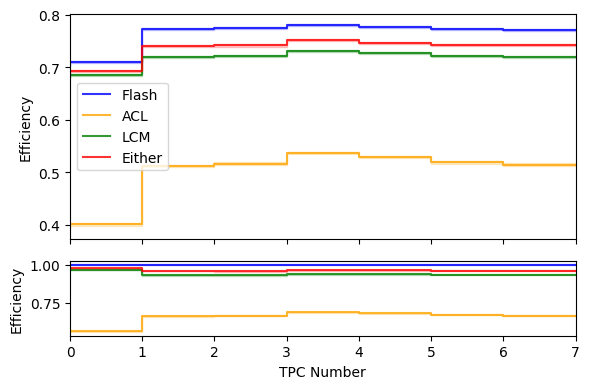

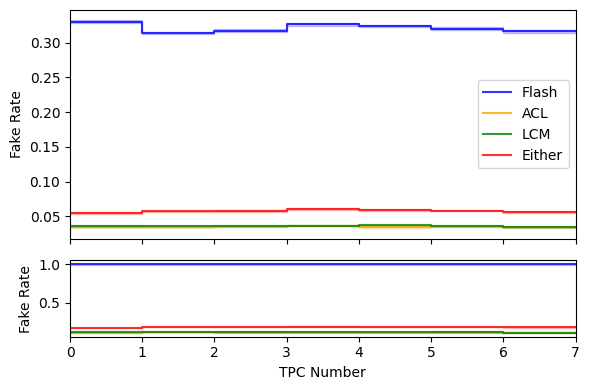

In [34]:
# Define tpc_num histogram bins
all_true_tpc = all_true['tpc_num'].dropna()

acl_reco_tpc = acl_rec['tpc_num'].dropna()
acl_true_reco_tpc = acl_true_rec['tpc_num'].dropna()

lcm_reco_tpc = lcm_rec['tpc_num'].dropna()
lcm_true_reco_tpc = lcm_true_rec['tpc_num'].dropna()

either_reco_tpc = df_truth_reco.loc[(df_truth_reco['trap_0_matched'] == True) | (df_truth_reco['trap_1_matched'] == True), 'tpc_num'].dropna()
either_true_reco_tpc = df_truth_reco.loc[(df_truth_reco['vertex_id'].notna()) & ((df_truth_reco['trap_0_matched'] == True) | (df_truth_reco['trap_1_matched'] == True)), 'tpc_num'].dropna()

flash_reco_tpc = flash_rec['tpc_num'].dropna()
flash_true_reco_tpc = flash_true_rec['tpc_num'].dropna()

# Define histogram bins for tpc_num (assuming integer TPC numbers)
xrange = (int(all_true_tpc.min()), int(all_true_tpc.max()) + 1)  # Range for the histogram bins
bins = np.arange(xrange[0], xrange[1] + 1)  # Create bins for each TPC number

# Plot the ratio of the two histograms with Clopper-Pearson intervals
plot_histogram_ratio_with_error(
  df_A=[flash_true_reco_tpc, acl_true_reco_tpc, lcm_true_reco_tpc, either_true_reco_tpc],
  df_B=[all_true_tpc, all_true_tpc, all_true_tpc, all_true_tpc],
  legend=['Flash', 'ACL', 'LCM', 'Either'],
  cols=['blue', 'orange', 'green', 'red'],
  bins=bins,
  xlabel='TPC Number',
  ylabel='Efficiency',
  xscale='linear'
)

# Plot the ratio of the two histograms with Clopper-Pearson intervals
plot_histogram_ratio_with_error(
    df_A=[flash_true_reco_tpc, acl_true_reco_tpc, lcm_true_reco_tpc, either_true_reco_tpc],
    df_B=[flash_reco_tpc, acl_reco_tpc, lcm_reco_tpc, either_reco_tpc],
    legend=['Flash', 'ACL', 'LCM', 'Either'],
    cols=['blue', 'orange', 'green', 'red'],
    bins=bins,
    xlabel='TPC Number',
    ylabel='Fake Rate',
    neg=True,
)

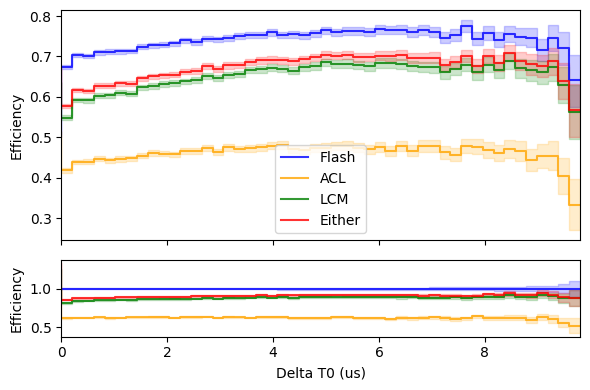

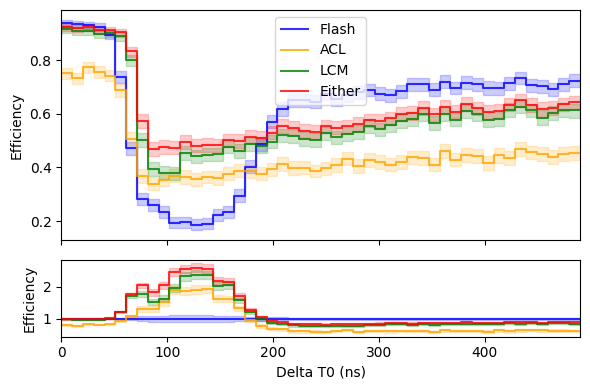

In [35]:
# Define delta_t0 histogram bins
all_true_delta_t0 = all_true['delta_t0'].dropna()*1e3

acl_reco_delta_t0 = acl_rec['delta_t0'].dropna()*1e3
acl_true_reco_delta_t0 = acl_true_rec['delta_t0'].dropna()*1e3

lcm_reco_delta_t0 = lcm_rec['delta_t0'].dropna()*1e3
lcm_true_reco_delta_t0 = lcm_true_rec['delta_t0'].dropna()*1e3

either_reco_delta_t0 = df_truth_reco.loc[(df_truth_reco['trap_0_matched'] == True) | (df_truth_reco['trap_1_matched'] == True), 'delta_t0'].dropna()*1e3
either_true_reco_delta_t0 = df_truth_reco.loc[(df_truth_reco['vertex_id'].notna()) & ((df_truth_reco['trap_0_matched'] == True) | (df_truth_reco['trap_1_matched'] == True)), 'delta_t0'].dropna()*1e3

flash_reco_delta_t0 = flash_rec['delta_t0'].dropna()*1e3
flash_true_reco_delta_t0 = flash_true_rec['delta_t0'].dropna()*1e3


# Define histogram bins
bins = np.linspace(0, 10, 50)  # To include value 11 in the last bin edge
# Plot the ratio of the two histograms with Clopper-Pearson intervals
plot_histogram_ratio_with_error(
    df_A=[flash_true_reco_delta_t0/1e3, acl_true_reco_delta_t0/1e3, lcm_true_reco_delta_t0/1e3, either_true_reco_delta_t0/1e3],
    df_B=[all_true_delta_t0/1e3, all_true_delta_t0/1e3, all_true_delta_t0/1e3, all_true_delta_t0/1e3],
    legend=['Flash', 'ACL', 'LCM', 'Either'],
    cols=['blue', 'orange', 'green', 'red'],
    bins=bins,
    xlabel='Delta T0 (us)',
    ylabel='Efficiency',
    xscale='linear'
)

# Define histogram bins
bins = np.linspace(0, 500, 50)  # To include value 11 in the last bin edge
# Plot the ratio of the two histograms with Clopper-Pearson intervals
plot_histogram_ratio_with_error(
    df_A=[flash_true_reco_delta_t0, acl_true_reco_delta_t0, lcm_true_reco_delta_t0, either_true_reco_delta_t0],
    df_B=[all_true_delta_t0, all_true_delta_t0, all_true_delta_t0, all_true_delta_t0],
    legend=['Flash', 'ACL', 'LCM', 'Either'],
    cols=['blue', 'orange', 'green', 'red'],
    bins=bins,
    xlabel='Delta T0 (ns)',
    ylabel='Efficiency',
    xscale='linear'
)

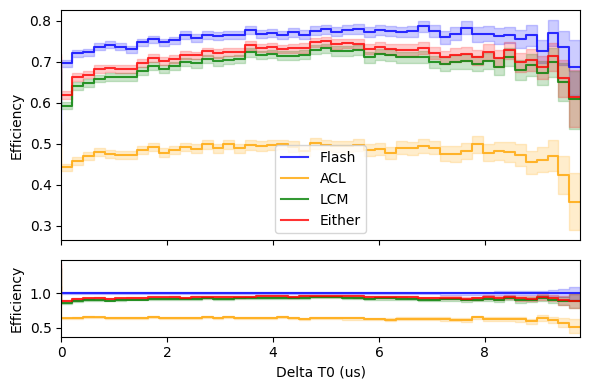

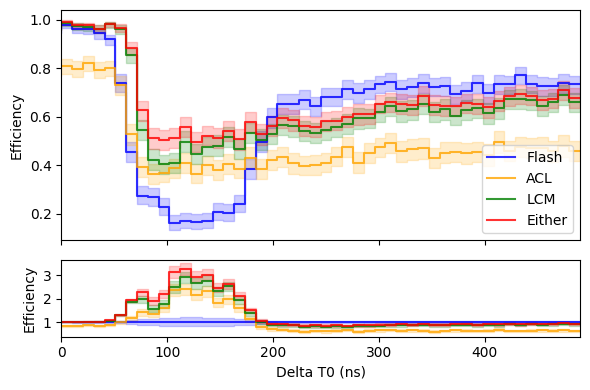

In [36]:
# Define delta_t0 histogram bins
all_true_delta_t0_2int = all_true_2int['delta_t0'].dropna()*1e3

acl_reco_delta_t0_2int = acl_rec_2int['delta_t0'].dropna()*1e3
acl_true_reco_delta_t0_2int = acl_true_rec_2int['delta_t0'].dropna()*1e3

lcm_reco_delta_t0_2int = lcm_rec_2int['delta_t0'].dropna()*1e3
lcm_true_reco_delta_t0_2int = lcm_true_rec_2int['delta_t0'].dropna()*1e3

either_reco_delta_t0_2int = df_truth_reco_2int.loc[(df_truth_reco_2int['trap_0_matched'] == True) | (df_truth_reco_2int['trap_1_matched'] == True), 'delta_t0'].dropna()*1e3
either_true_reco_delta_t0_2int = df_truth_reco_2int.loc[(df_truth_reco_2int['vertex_id'].notna()) & ((df_truth_reco_2int['trap_0_matched'] == True) | (df_truth_reco_2int['trap_1_matched'] == True)), 'delta_t0'].dropna()*1e3

flash_reco_delta_t0_2int = flash_rec_2int['delta_t0'].dropna()*1e3
flash_true_reco_delta_t0_2int = flash_true_rec_2int['delta_t0'].dropna()*1e3


# Define histogram bins
bins = np.linspace(0, 10, 50)  # To include value 11 in the last bin edge
# Plot the ratio of the two histograms with Clopper-Pearson intervals
plot_histogram_ratio_with_error(
    df_A=[flash_true_reco_delta_t0_2int/1e3, acl_true_reco_delta_t0_2int/1e3, lcm_true_reco_delta_t0_2int/1e3, either_true_reco_delta_t0_2int/1e3],
    df_B=[all_true_delta_t0_2int/1e3, all_true_delta_t0_2int/1e3, all_true_delta_t0_2int/1e3, all_true_delta_t0_2int/1e3],
    legend=['Flash', 'ACL', 'LCM', 'Either'],
    cols=['blue', 'orange', 'green', 'red'],
    bins=bins,
    xlabel='Delta T0 (us)',
    ylabel='Efficiency',
    xscale='linear'
)

# Define histogram bins
bins = np.linspace(0, 500, 50)  # To include value 11 in the last bin edge
# Plot the ratio of the two histograms with Clopper-Pearson intervals
plot_histogram_ratio_with_error(
    df_A=[flash_true_reco_delta_t0_2int, acl_true_reco_delta_t0_2int, lcm_true_reco_delta_t0_2int, either_true_reco_delta_t0_2int],
    df_B=[all_true_delta_t0_2int, all_true_delta_t0_2int, all_true_delta_t0_2int, all_true_delta_t0_2int],
    legend=['Flash', 'ACL', 'LCM', 'Either'],
    cols=['blue', 'orange', 'green', 'red'],
    bins=bins,
    xlabel='Delta T0 (ns)',
    ylabel='Efficiency',
    xscale='linear'
)

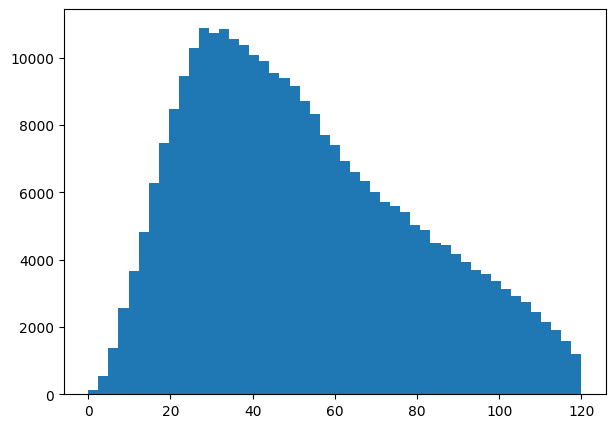

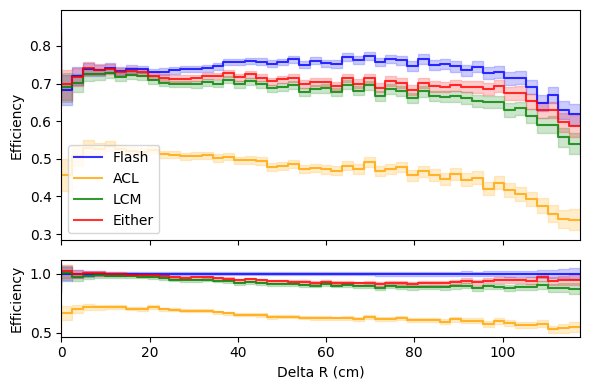

In [38]:
# Define delta_R histogram bins
all_true_delta_R_2int = all_true_2int['delta_R'].dropna()

# plot histograms of delta_R for 2 interactions
plt.figure(figsize=(7, 5))
bins = np.linspace(0, 120, 50)
plt.hist(all_true_delta_R_2int, bins=bins)
plt.show()

acl_reco_delta_R_2int = acl_rec_2int['delta_R'].dropna()
acl_true_reco_delta_R_2int = acl_true_rec_2int['delta_R'].dropna()

lcm_reco_delta_R_2int = lcm_rec_2int['delta_R'].dropna()
lcm_true_reco_delta_R_2int = lcm_true_rec_2int['delta_R'].dropna()

either_reco_delta_R_2int = df_truth_reco_2int.loc[(df_truth_reco_2int['trap_0_matched'] == True) | (df_truth_reco_2int['trap_1_matched'] == True), 'delta_R'].dropna()
either_true_reco_delta_R_2int = df_truth_reco_2int.loc[(df_truth_reco_2int['vertex_id'].notna()) & ((df_truth_reco_2int['trap_0_matched'] == True) | (df_truth_reco_2int['trap_1_matched'] == True)), 'delta_R'].dropna()

flash_reco_delta_R_2int = flash_rec_2int['delta_R'].dropna()
flash_true_reco_delta_R_2int = flash_true_rec_2int['delta_R'].dropna()

# Define histogram bins
bins = np.linspace(0, 120, 50)
# Plot the ratio of the two histograms with Clopper-Pearson intervals
plot_histogram_ratio_with_error(
  df_A=[flash_true_reco_delta_R_2int, acl_true_reco_delta_R_2int, lcm_true_reco_delta_R_2int, either_true_reco_delta_R_2int],
  df_B=[all_true_delta_R_2int, all_true_delta_R_2int, all_true_delta_R_2int, all_true_delta_R_2int],
  legend=['Flash', 'ACL', 'LCM', 'Either'],
  cols=['blue', 'orange', 'green', 'red'],
  bins=bins,
  xlabel='Delta R (cm)',
  ylabel='Efficiency',
  xscale='linear'
)


In [39]:
# Define delta_Ifrac_nphotons histogram bins
all_true_delta_Ifrac_2int = all_true_2int['delta_Ifrac_nphotons'].dropna()

acl_reco_delta_Ifrac_2int = acl_rec_2int['delta_Ifrac_nphotons'].dropna()
acl_true_reco_delta_Ifrac_2int = acl_true_rec_2int['delta_Ifrac_nphotons'].dropna()

lcm_reco_delta_Ifrac_2int = lcm_rec_2int['delta_Ifrac_nphotons'].dropna()
lcm_true_reco_delta_Ifrac_2int = lcm_true_rec_2int['delta_Ifrac_nphotons'].dropna()

either_reco_delta_Ifrac_2int = df_truth_reco_2int.loc[(df_truth_reco_2int['trap_0_matched'] == True) | (df_truth_reco_2int['trap_1_matched'] == True), 'delta_Ifrac_nphotons'].dropna()
either_true_reco_delta_Ifrac_2int = df_truth_reco_2int.loc[(df_truth_reco_2int['vertex_id'].notna()) & ((df_truth_reco_2int['acl_hit'] == True) | (df_truth_reco_2int['lcm_hit'] == True)), 'delta_Ifrac_nphotons'].dropna()

flash_reco_delta_Ifrac_2int = flash_rec_2int['delta_Ifrac_nphotons'].dropna()
flash_true_reco_delta_Ifrac_2int = flash_true_rec_2int['delta_Ifrac_nphotons'].dropna()

print(all_true_delta_Ifrac_2int.min(), all_true_delta_Ifrac_2int.max())

# plot histogram of delta_Ifrac_nphotons
#bins = np.linspace(-1, 10, 55)
bins = 50
plt.figure(figsize=(8, 6))
plt.hist(np.abs(all_true_delta_Ifrac_2int), bins=bins, alpha=0.5)
plt.yscale('log')
plt.show()

# Plot the ratio of the two histograms with Clopper-Pearson intervals
bins = np.linspace(0, 0.5, 50)
plot_histogram_ratio_with_error(
  df_A=[np.abs(flash_true_reco_delta_Ifrac_2int), np.abs(acl_true_reco_delta_Ifrac_2int), np.abs(lcm_true_reco_delta_Ifrac_2int), np.abs(either_true_reco_delta_Ifrac_2int)],
  df_B=[np.abs(all_true_delta_Ifrac_2int), np.abs(all_true_delta_Ifrac_2int), np.abs(all_true_delta_Ifrac_2int), np.abs(all_true_delta_Ifrac_2int)],
  legend=['Flash', 'ACL', 'LCM', 'Either'],
  cols=['blue', 'orange', 'green', 'red'],
  bins=bins,
  xlabel='Delta intensity (n_photons)',
  ylabel='Efficiency',
  xscale='linear'
)

# plot histogram of delta_Ifrac_nphotons
#bins = np.linspace(-1, 10, 55)
bins = 50 #np.array([-1, -0.8, 0, 5, 6, 7, 8, 9, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100])
plt.figure(figsize=(8, 6))
plt.hist(np.log10(np.abs(all_true_delta_Ifrac_2int)+1e-9), bins=bins, alpha=0.5)
plt.yscale('log')
plt.show()


bins = np.linspace(-1, 1, 50)
plot_histogram_ratio_with_error(
  df_A=[np.log10(np.abs(flash_true_reco_delta_Ifrac_2int)+1e-9),np.log10(np.abs(acl_true_reco_delta_Ifrac_2int)+1e-9), np.log10(np.abs(lcm_true_reco_delta_Ifrac_2int)+1e-9), np.log10(np.abs(either_true_reco_delta_Ifrac_2int)+1e-9)],
  df_B=[np.log10(np.abs(all_true_delta_Ifrac_2int)+1e-9), np.log10(np.abs(all_true_delta_Ifrac_2int)+1e-9), np.log10(np.abs(all_true_delta_Ifrac_2int)+1e-9), np.log10(np.abs(all_true_delta_Ifrac_2int)+1e-9)],
  legend=['Flash', 'ACL', 'LCM', 'Either'],
  cols=['blue', 'orange', 'green', 'red'],
  bins=bins,
  xlabel='Delta intensity (n_photons)',
  ylabel='Efficiency',
  xscale='linear'
)


KeyError: 'delta_Ifrac_nphotons'

In [40]:
def compute_efficiency_heatmap(df_true, df_reco, dR_bins, dt0_bins):
    # Create 2D histogram for true interactions
    true_hist, _, _ = np.histogram2d(
        df_true['delta_R'],
        df_true['delta_t0'],
        bins=[dR_bins, dt0_bins]
    )
    # Create 2D histogram for reconstructed interactions
    reco_hist, _, _ = np.histogram2d(
        df_reco['delta_R'],
        df_reco['delta_t0'],
        bins=[dR_bins, dt0_bins]
    )
    # Calculate efficiency
    efficiency = np.divide(reco_hist, true_hist, out=np.zeros_like(reco_hist, dtype=float), where=true_hist != 0)
    return efficiency, true_hist, reco_hist

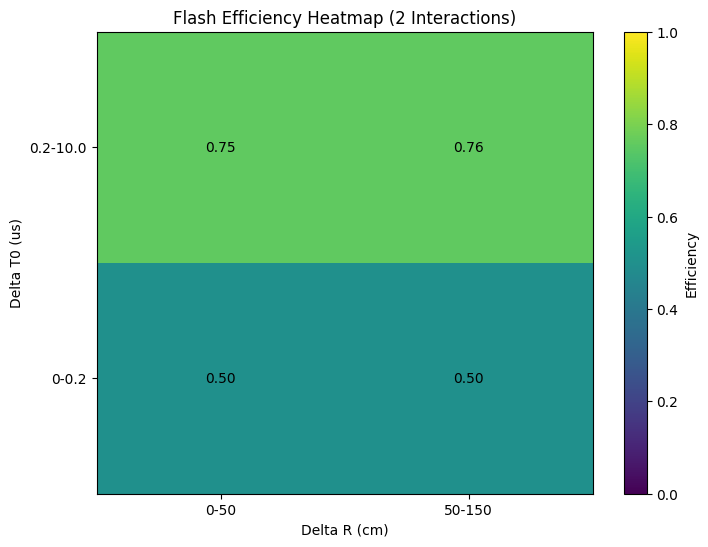

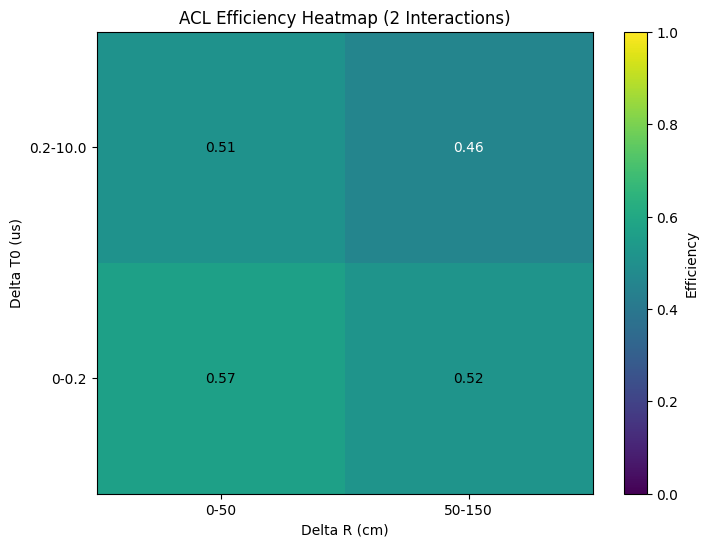

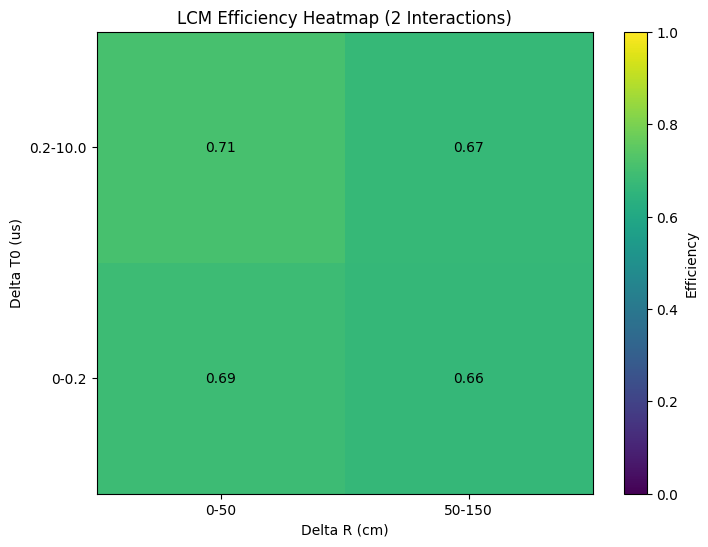

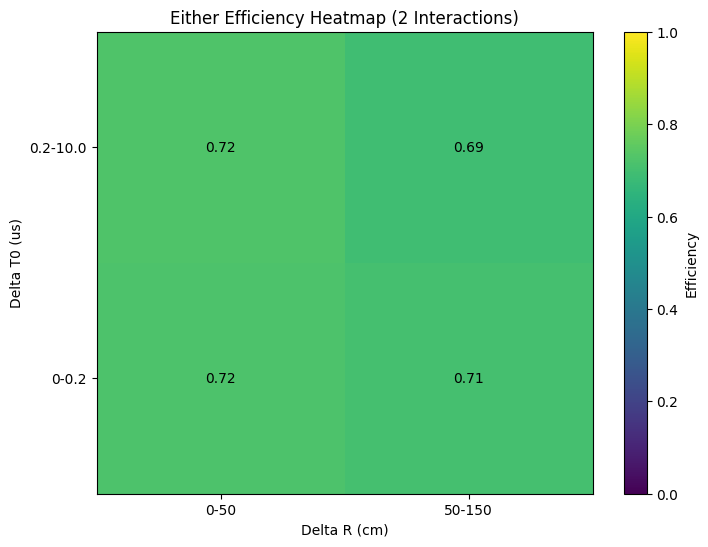

In [41]:
# make a 2D heatmap of the efficiencies in the following bins:
# delta_R: 0-50, 50-150 (cm)
# delta_t0: 0-0.2, 0.2-8.0 (us)
# for 2 interactions only

dR_bin_edges = [0, 50, 150]  # in cm
dt0_bin_edges = [0, 0.2, 10.0]  # in us

# Compute efficiency heatmaps
flash_efficiency, flash_true_hist, flash_reco_hist = compute_efficiency_heatmap(all_true_2int, flash_true_rec_2int, dR_bin_edges, dt0_bin_edges)
acl_efficiency, acl_true_hist, acl_reco_hist = compute_efficiency_heatmap(all_true_2int, acl_true_rec_2int, dR_bin_edges, dt0_bin_edges)
lcm_efficiency, lcm_true_hist, lcm_reco_hist = compute_efficiency_heatmap(all_true_2int, lcm_true_rec_2int, dR_bin_edges, dt0_bin_edges)
either_efficiency, either_true_hist, either_reco_hist = compute_efficiency_heatmap(all_true_2int, df_truth_reco_2int[(df_truth_reco_2int['trap_0_matched'] == True) | (df_truth_reco_2int['trap_1_matched'] == True)], dR_bin_edges, dt0_bin_edges)

def plot_efficiency_heatmap(efficiency, dR_bins, dt0_bins, title, equal_size=True, show_text=True):
  plt.figure(figsize=(8, 6))
  # Use pcolormesh for correct bin widths
  X, Y = np.meshgrid(dR_bins, dt0_bins)
  if equal_size:
    # Make bins equal size by rescaling axes to bin indices
    extent = [0, efficiency.shape[0], 0, efficiency.shape[1]]
    plt.imshow(
      efficiency.T,
      vmin=0, vmax=1, cmap='viridis',
      origin='lower',
      aspect='auto',
      extent=extent
    )
    plt.xticks(np.arange(len(dR_bins)-1) + 0.5, [f"{dR_bins[i]}-{dR_bins[i+1]}" for i in range(len(dR_bins)-1)])
    plt.yticks(np.arange(len(dt0_bins)-1) + 0.5, [f"{dt0_bins[j]}-{dt0_bins[j+1]}" for j in range(len(dt0_bins)-1)])
    plt.xlabel('Delta R (cm)')
    plt.ylabel('Delta T0 (us)')
  else:
    plt.pcolormesh(X, Y, efficiency.T, vmin=0, vmax=1, cmap='viridis', shading='auto')
    plt.xticks(dR_bins)
    plt.yticks(dt0_bins)
    plt.xlabel('Delta R (cm)')
    plt.ylabel('Delta T0 (us)')
  plt.colorbar(label='Efficiency')
  plt.title(title)
  plt.grid(False)

  # Add text labels
  if show_text:
    for i in range(efficiency.shape[0]):
      for j in range(efficiency.shape[1]):
        if equal_size:
          x = i + 0.5
          y = j + 0.5
        else:
          x = (dR_bins[i] + dR_bins[i+1]) / 2
          y = (dt0_bins[j] + dt0_bins[j+1]) / 2
        plt.text(
          x, y,
          f'{efficiency[i, j]:.2f}',
          color='white' if efficiency[i, j] < 0.5 else 'black',
          ha='center',
          va='center'
        )
  plt.show()

plot_efficiency_heatmap(flash_efficiency, dR_bin_edges, dt0_bin_edges, 'Flash Efficiency Heatmap (2 Interactions)')
plot_efficiency_heatmap(acl_efficiency, dR_bin_edges, dt0_bin_edges, 'ACL Efficiency Heatmap (2 Interactions)')
plot_efficiency_heatmap(lcm_efficiency, dR_bin_edges, dt0_bin_edges, 'LCM Efficiency Heatmap (2 Interactions)')
plot_efficiency_heatmap(either_efficiency, dR_bin_edges, dt0_bin_edges, 'Either Efficiency Heatmap (2 Interactions)')


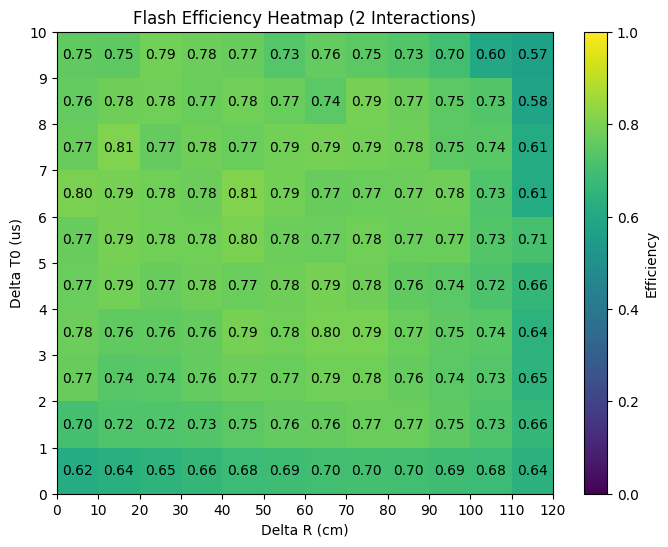

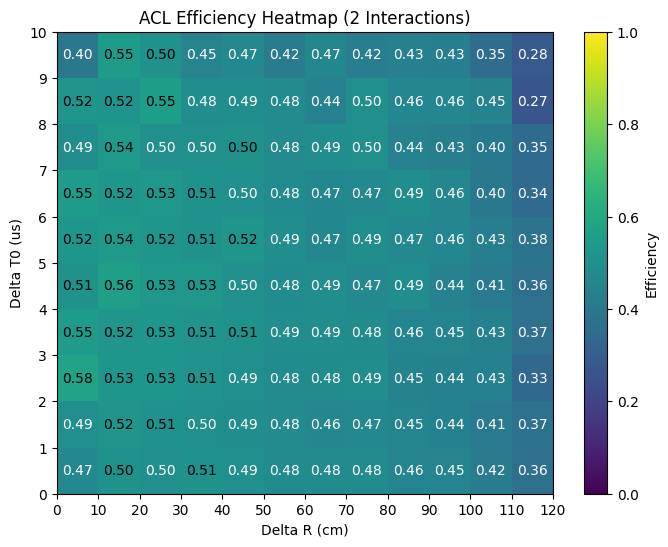

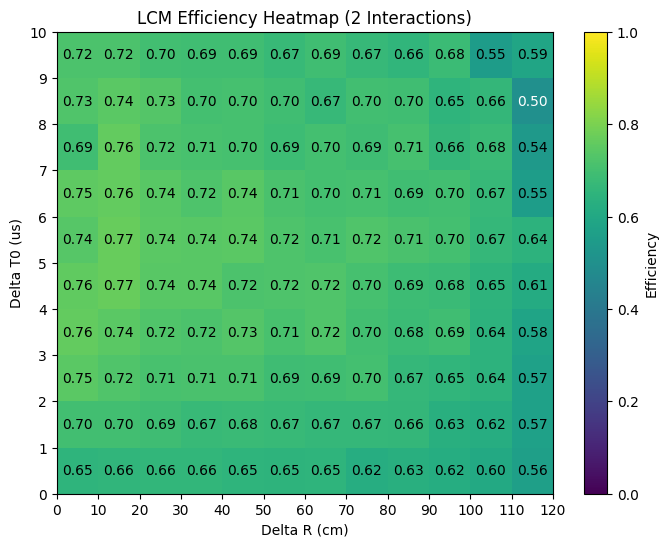

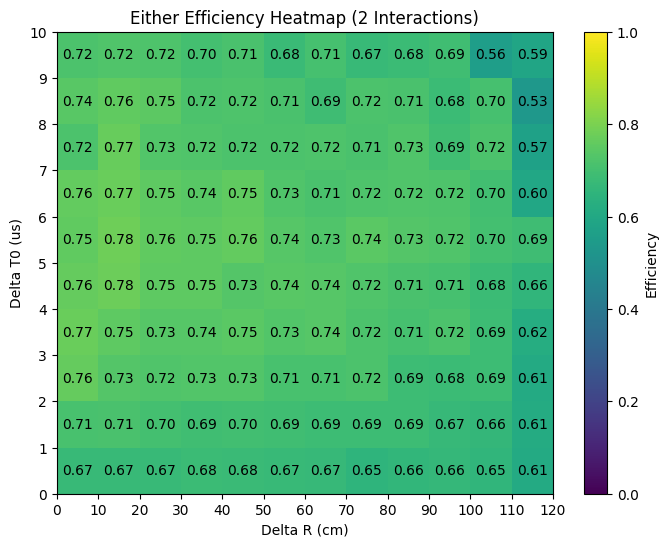

In [42]:
dR_bin_edges = np.linspace(0, 120, 13)  # in cm
dt0_bin_edges = np.linspace(0, 10, 11)  # in us

# Compute efficiency heatmaps
flash_efficiency, flash_true_hist, flash_reco_hist = compute_efficiency_heatmap(all_true_2int, flash_true_rec_2int, dR_bin_edges, dt0_bin_edges)
acl_efficiency, acl_true_hist, acl_reco_hist = compute_efficiency_heatmap(all_true_2int, acl_true_rec_2int, dR_bin_edges, dt0_bin_edges)
lcm_efficiency, lcm_true_hist, lcm_reco_hist = compute_efficiency_heatmap(all_true_2int, lcm_true_rec_2int, dR_bin_edges, dt0_bin_edges)
either_efficiency, either_true_hist, either_reco_hist = compute_efficiency_heatmap(all_true_2int, df_truth_reco_2int[(df_truth_reco_2int['trap_0_matched'] == True) | (df_truth_reco_2int['trap_1_matched'] == True)], dR_bin_edges, dt0_bin_edges)

plot_efficiency_heatmap(flash_efficiency, dR_bin_edges, dt0_bin_edges, 'Flash Efficiency Heatmap (2 Interactions)', equal_size=False)
plot_efficiency_heatmap(acl_efficiency, dR_bin_edges, dt0_bin_edges, 'ACL Efficiency Heatmap (2 Interactions)', equal_size=False)
plot_efficiency_heatmap(lcm_efficiency, dR_bin_edges, dt0_bin_edges, 'LCM Efficiency Heatmap (2 Interactions)', equal_size=False)
plot_efficiency_heatmap(either_efficiency, dR_bin_edges, dt0_bin_edges, 'Either Efficiency Heatmap (2 Interactions)', equal_size=False)

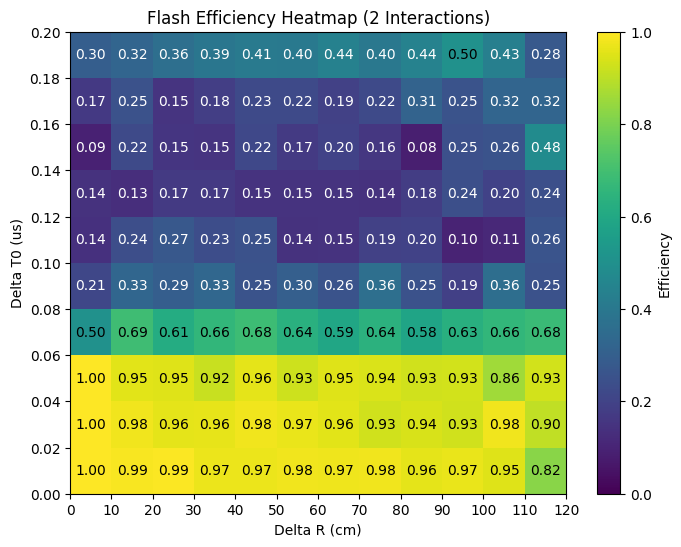

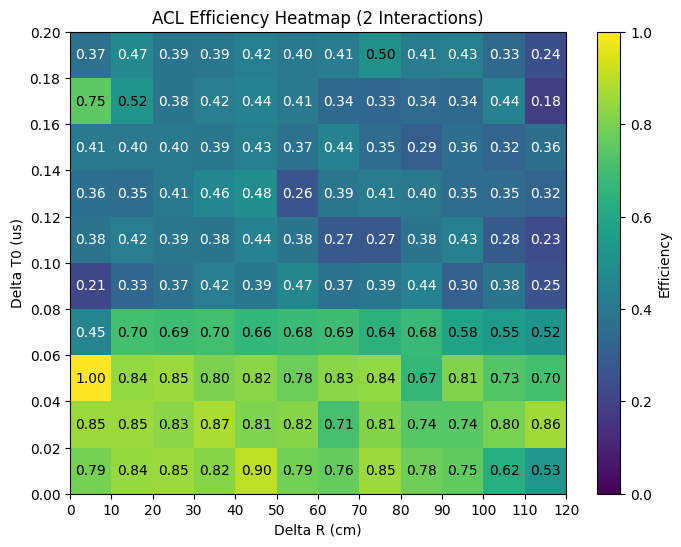

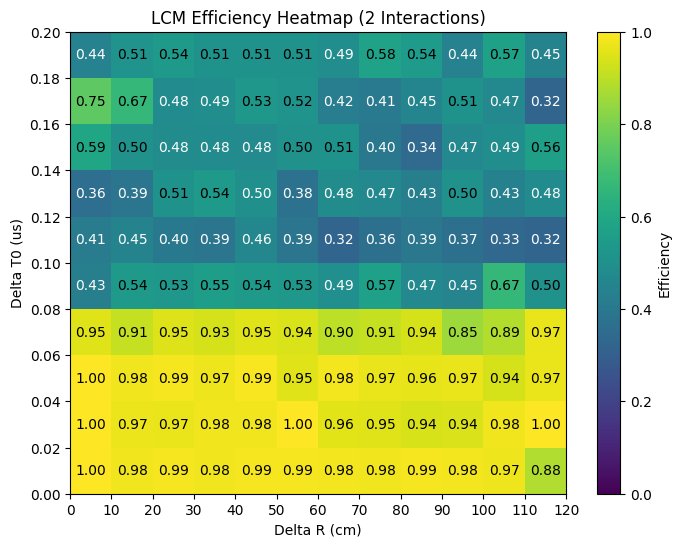

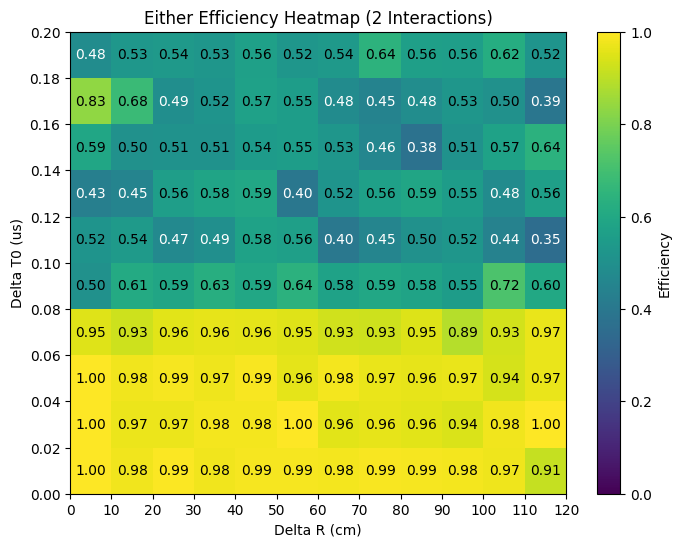

In [43]:
dR_bin_edges = np.linspace(0, 120, 13)  # in cm
dt0_bin_edges = np.linspace(0, 0.2, 11)  # in us

# Compute efficiency heatmaps
flash_efficiency, flash_true_hist, flash_reco_hist = compute_efficiency_heatmap(all_true_2int, flash_true_rec_2int, dR_bin_edges, dt0_bin_edges)
acl_efficiency, acl_true_hist, acl_reco_hist = compute_efficiency_heatmap(all_true_2int, acl_true_rec_2int, dR_bin_edges, dt0_bin_edges)
lcm_efficiency, lcm_true_hist, lcm_reco_hist = compute_efficiency_heatmap(all_true_2int, lcm_true_rec_2int, dR_bin_edges, dt0_bin_edges)
either_efficiency, either_true_hist, either_reco_hist = compute_efficiency_heatmap(all_true_2int, df_truth_reco_2int[(df_truth_reco_2int['trap_0_matched'] == True) | (df_truth_reco_2int['trap_1_matched'] == True)], dR_bin_edges, dt0_bin_edges)

plot_efficiency_heatmap(flash_efficiency, dR_bin_edges, dt0_bin_edges, 'Flash Efficiency Heatmap (2 Interactions)', equal_size=False)
plot_efficiency_heatmap(acl_efficiency, dR_bin_edges, dt0_bin_edges, 'ACL Efficiency Heatmap (2 Interactions)', equal_size=False)
plot_efficiency_heatmap(lcm_efficiency, dR_bin_edges, dt0_bin_edges, 'LCM Efficiency Heatmap (2 Interactions)', equal_size=False)
plot_efficiency_heatmap(either_efficiency, dR_bin_edges, dt0_bin_edges, 'Either Efficiency Heatmap (2 Interactions)', equal_size=False)

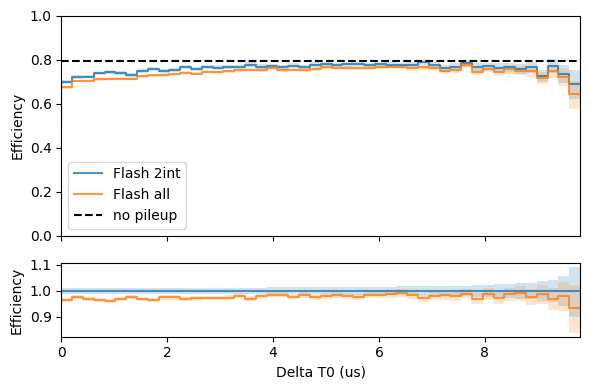

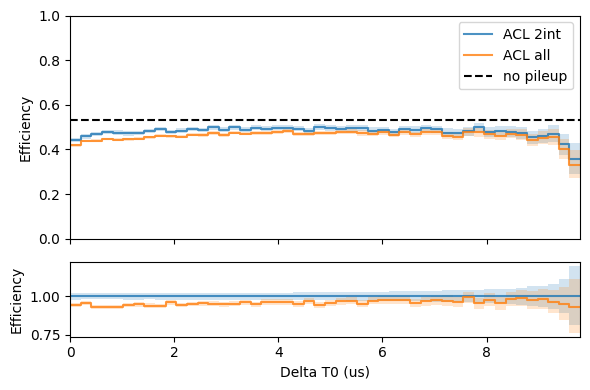

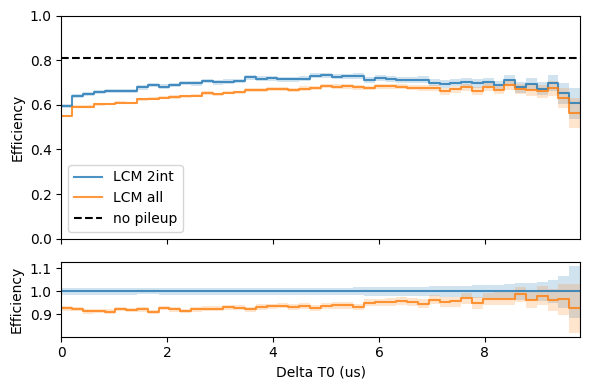

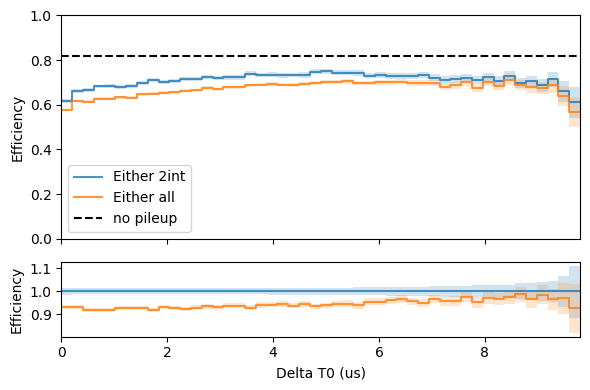

In [44]:
# Define histogram bins
bins = np.linspace(0, 10, 50)  # To include value 11 in the last bin edge

# Plot the ratio of the two histograms with Clopper-Pearson intervals
plot_histogram_ratio_with_error2(
    df_A=[flash_true_reco_delta_t0_2int/1e3, flash_true_reco_delta_t0/1e3],
    df_B=[all_true_delta_t0_2int/1e3, all_true_delta_t0/1e3],
    legend=['Flash 2int', "Flash all"],
    bins=bins,
    xlabel='Delta T0 (us)',
    ylabel='Efficiency',
    xscale='linear',
    hline = flash_1int_eff
)

# Plot the ratio of the two histograms with Clopper-Pearson intervals
plot_histogram_ratio_with_error2(
    df_A=[acl_true_reco_delta_t0_2int/1e3, acl_true_reco_delta_t0/1e3],
    df_B=[all_true_delta_t0_2int/1e3, all_true_delta_t0/1e3],
    legend=['ACL 2int', "ACL all"],
    bins=bins,
    xlabel='Delta T0 (us)',
    ylabel='Efficiency',
    xscale='linear',
    hline = acl_1int_eff
)

# Plot the ratio of the two histograms with Clopper-Pearson intervals
plot_histogram_ratio_with_error2(
    df_A=[lcm_true_reco_delta_t0_2int/1e3, lcm_true_reco_delta_t0/1e3],
    df_B=[all_true_delta_t0_2int/1e3, all_true_delta_t0/1e3],
    legend=['LCM 2int', "LCM all"],
    bins=bins,
    xlabel='Delta T0 (us)',
    ylabel='Efficiency',
    xscale='linear',
    hline = lcm_1int_eff
)

# Plot the ratio of the two histograms with Clopper-Pearson intervals
plot_histogram_ratio_with_error2(
    df_A=[either_true_reco_delta_t0_2int/1e3, either_true_reco_delta_t0/1e3],
    df_B=[all_true_delta_t0_2int/1e3, all_true_delta_t0/1e3],
    legend=['Either 2int', "Either all"],
    bins=bins,
    xlabel='Delta T0 (us)',
    ylabel='Efficiency',
    xscale='linear',
    hline = either_1int_eff
)

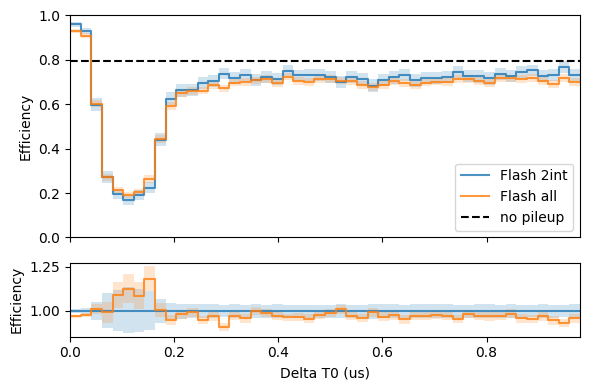

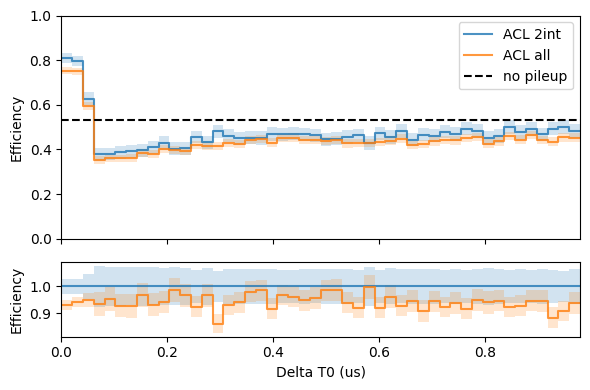

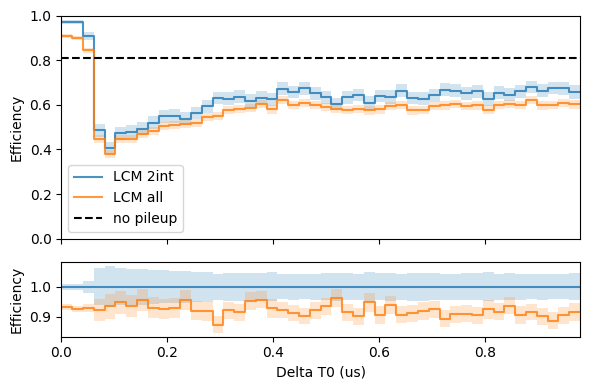

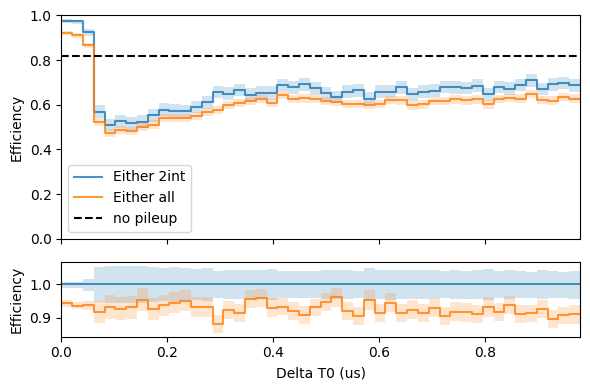

In [45]:

# Define histogram bins
bins = np.linspace(0, 1, 50)  # To include value 11 in the last bin edge

# Plot the ratio of the two histograms with Clopper-Pearson intervals
plot_histogram_ratio_with_error2(
    df_A=[flash_true_reco_delta_t0_2int/1e3, flash_true_reco_delta_t0/1e3],
    df_B=[all_true_delta_t0_2int/1e3, all_true_delta_t0/1e3],
    legend=['Flash 2int', "Flash all"],
    bins=bins,
    xlabel='Delta T0 (us)',
    ylabel='Efficiency',
    xscale='linear',
    hline = flash_1int_eff
)

# Plot the ratio of the two histograms with Clopper-Pearson intervals
plot_histogram_ratio_with_error2(
    df_A=[acl_true_reco_delta_t0_2int/1e3, acl_true_reco_delta_t0/1e3],
    df_B=[all_true_delta_t0_2int/1e3, all_true_delta_t0/1e3],
    legend=['ACL 2int', "ACL all"],
    bins=bins,
    xlabel='Delta T0 (us)',
    ylabel='Efficiency',
    xscale='linear',
    hline = acl_1int_eff
)

# Plot the ratio of the two histograms with Clopper-Pearson intervals
plot_histogram_ratio_with_error2(
    df_A=[lcm_true_reco_delta_t0_2int/1e3, lcm_true_reco_delta_t0/1e3],
    df_B=[all_true_delta_t0_2int/1e3, all_true_delta_t0/1e3],
    legend=['LCM 2int', "LCM all"],
    bins=bins,
    xlabel='Delta T0 (us)',
    ylabel='Efficiency',
    xscale='linear',
    hline = lcm_1int_eff
)

# Plot the ratio of the two histograms with Clopper-Pearson intervals
plot_histogram_ratio_with_error2(
    df_A=[either_true_reco_delta_t0_2int/1e3, either_true_reco_delta_t0/1e3],
    df_B=[all_true_delta_t0_2int/1e3, all_true_delta_t0/1e3],
    legend=['Either 2int', "Either all"],
    bins=bins,
    xlabel='Delta T0 (us)',
    ylabel='Efficiency',
    xscale='linear',
    hline = either_1int_eff
)

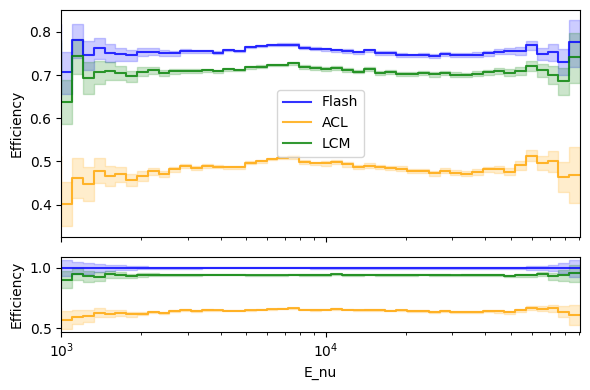

In [46]:
# Efficiency as a function of neutrino energy (E_nu)
acl_true_enu = df_truth_reco['enu'].dropna()
acl_true_reco_enu = acl_true_rec['enu'].dropna()

lcm_true_enu = df_truth_reco['enu'].dropna()
lcm_true_reco_enu = lcm_true_rec['enu'].dropna()

flash_true_enu = df_truth_reco['enu'].dropna()
flash_true_reco_enu = flash_true_rec['enu'].dropna()

# Use log bins for E_nu
bins = np.logspace(3, 5, 50)  # E_nu from 1e2 to 1e6

plot_histogram_ratio_with_error(
    df_A=[flash_true_reco_enu, acl_true_reco_enu, lcm_true_reco_enu],
    df_B=[flash_true_enu, acl_true_enu, lcm_true_enu],
    legend=['Flash', 'ACL', 'LCM'],
    cols=['blue', 'orange', 'green'],
    bins=bins,
    xlabel='E_nu',
    ylabel='Efficiency',
    neg=False,
    xscale='log'
)

/tmp/ipykernel_215088/725115847.py:47: RuntimeWarning: invalid value encountered in divide
  axs[1].step(bin_centers, frac / frac_0, alpha=0.8, label=f"Ratio to {legend[0]}", color=cols[i])
/tmp/ipykernel_215088/725115847.py:48: RuntimeWarning: divide by zero encountered in divide
  axs[1].fill_between(bin_centers, lower_bounds / frac_0, upper_bounds / frac_0, step='pre', alpha=0.2, color=cols[i])
/tmp/ipykernel_215088/725115847.py:48: RuntimeWarning: invalid value encountered in divide
  axs[1].fill_between(bin_centers, lower_bounds / frac_0, upper_bounds / frac_0, step='pre', alpha=0.2, color=cols[i])
/tmp/ipykernel_215088/725115847.py:47: RuntimeWarning: divide by zero encountered in divide
  axs[1].step(bin_centers, frac / frac_0, alpha=0.8, label=f"Ratio to {legend[0]}", color=cols[i])


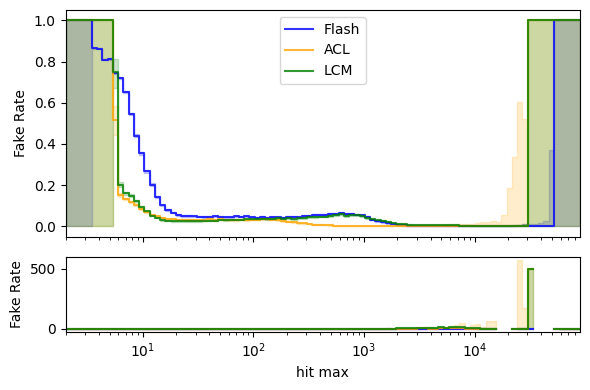

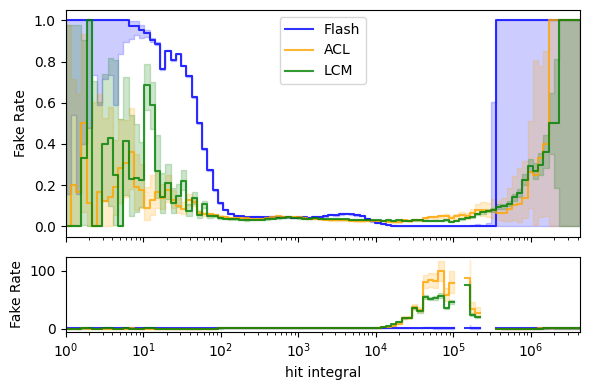

In [48]:
# fake rate as f( hit max )
acl_reco_max = acl_rec['trap_0_max'].dropna()
acl_true_reco_max = acl_true_rec['trap_0_max'].dropna()

lcm_reco_max = lcm_rec['trap_1_max'].dropna()
lcm_true_reco_max = lcm_true_rec['trap_1_max'].dropna()

flash_reco_max = flash_rec['flash_max'].dropna()
flash_true_reco_max = flash_true_rec['flash_max'].dropna()

# Define histogram bins for tpc_num (assuming integer TPC numbers)
bins = np.logspace(np.log10(2), np.log10(1e5), 100)  # Logarithmic scale for hit max

# Plot the ratio of the two histograms with Clopper-Pearson intervals
# flash max, acl max, lcm max, either max
plot_histogram_ratio_with_error(
    df_A=[flash_true_reco_max, acl_true_reco_max, lcm_true_reco_max],
    df_B=[flash_reco_max, acl_reco_max, lcm_reco_max],
    legend=['Flash', 'ACL', 'LCM'],
    cols=['blue', 'orange', 'green'],
    bins=bins,
    xlabel='hit max',
    ylabel='Fake Rate',
    neg=True,
    xscale='log'
)

# fake rate as f( hit integral )
acl_reco_int = acl_rec['trap_0_integral'].dropna()
acl_true_reco_int = acl_true_rec['trap_0_integral'].dropna()

lcm_reco_int = lcm_rec['trap_1_integral'].dropna()
lcm_true_reco_int = lcm_true_rec['trap_1_integral'].dropna()

flash_reco_int = flash_rec['flash_sum'].dropna()
flash_true_reco_int = flash_true_rec['flash_sum'].dropna()

# Define histogram bins for tpc_num (assuming integer TPC numbers)
bins = np.logspace(np.log10(1), np.log10(5e6), 100)  # Logarithmic scale for hit integral

# Plot the ratio of the two histograms with Clopper-Pearson intervals
plot_histogram_ratio_with_error(
    df_A=[flash_true_reco_int, acl_true_reco_int, lcm_true_reco_int],
    df_B=[flash_reco_int, acl_reco_int, lcm_reco_int],
    legend=['Flash', 'ACL', 'LCM'],
    cols=['blue', 'orange', 'green'],
    bins=bins,
    xlabel='hit integral',
    ylabel='Fake Rate',
    neg=True,
    xscale='log'
)

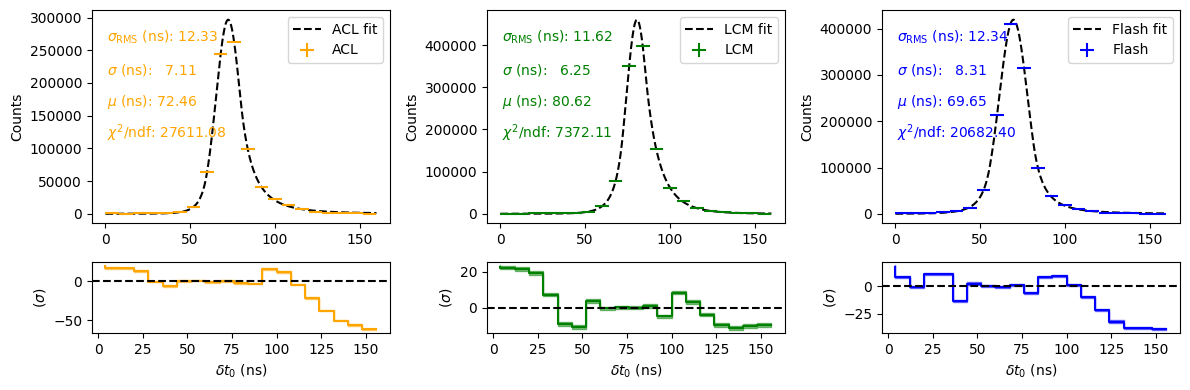

In [50]:
from pyexpat.errors import XML_ERROR_ABORTED
from matplotlib import markers
from scipy.optimize import curve_fit

def double_sided_crystal_ball(x, beta1, m1, beta2, m2, loc, scale, amplitude):
    """
    A smooth Double-Sided Crystal Ball function.

    Parameters:
    - x: Data points.
    - beta1, m1: Left tail parameters (beta1 = tail exponent, m1 = curvature).
    - beta2, m2: Right tail parameters.
    - loc: Center of the distribution (mean).
    - scale: Core width (sigma).
    - amplitude: Scaling factor.

    Returns:
    - Smooth DSCB function values.
    """

    # Normalized distance from mean
    t = (x - loc) / scale

    # Transition points
    left_cutoff = -beta1
    right_cutoff = beta2

    y = np.zeros_like(t)

    # Left tail (x < loc - beta1 * scale)
    left_mask = t < left_cutoff
    if np.any(left_mask):
        A1 = (m1 / beta1) ** m1 * np.exp(-0.5 * beta1 ** 2)
        B1 = m1 / beta1 - beta1
        y[left_mask] = A1 * (B1 - t[left_mask]) ** -m1

    # Core Gaussian (-beta1 < t < beta2)
    core_mask = (t >= left_cutoff) & (t <= right_cutoff)
    if np.any(core_mask):
        y[core_mask] = np.exp(-0.5 * t[core_mask] ** 2)

    # Right tail (x > loc + beta2 * scale)
    right_mask = t > right_cutoff
    if np.any(right_mask):
        A2 = (m2 / beta2) ** m2 * np.exp(-0.5 * beta2 ** 2)
        B2 = m2 / beta2 - beta2
        y[right_mask] = A2 * (B2 + t[right_mask]) ** -m2

    return amplitude * y


def plot_histogram_and_fit(ax_main, ax_resid, delta_t, color, label, nbins=20, print_text=False, offset=0.0, tolerance=0.16):
    # Histogram
    delta_t_ns = delta_t * 1e3
    #ax_main.hist(delta_t_ns, bins=nbins, range=(0, tolerance), histtype='step', color=color, label=label)

    # Bin calculations
    hist, bin_edges = np.histogram(delta_t_ns, bins=nbins, range=(0, tolerance))
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    sqrtN = np.sqrt(hist)
    ax_main.errorbar(bin_centers, hist, yerr=sqrtN, xerr=(bin_edges[1]-bin_edges[0])/2,
                      label=label, fmt='none', color=color, alpha=1.0)

    # Fit Double-sided Crystal Ball
    param_bounds = ([0.1, 0.1, 0.1, 0.1, -np.inf,   1e-6,   1e-6],
                    [ 10,  10,  10,  10,  np.inf, np.inf, np.inf])
    p0 = [1.5, 2.0, 1.5, 2.0, np.mean(delta_t_ns), np.std(delta_t_ns), max(hist)]

    popt, _ = curve_fit(double_sided_crystal_ball, bin_centers, hist, p0=p0, bounds=param_bounds, maxfev=1e4)
    with np.errstate(divide='ignore', invalid='ignore'):
        chisq_ndf = np.sum(np.where(sqrtN > 0, ((hist - double_sided_crystal_ball(bin_centers, *popt)) ** 2) / sqrtN, 0)) / (len(hist) - len(p0))

    # Plot fit
    ax_main.plot(interp_bin_centres, double_sided_crystal_ball(interp_bin_centres, *popt),
                 color='k', linestyle='--', label=f'{label} fit', alpha=1.0, zorder=0)

    # Labels
    ax_main.set_ylabel('Counts')
    ax_main.legend()

    # Residuals
    resids = (hist - double_sided_crystal_ball(bin_centers, *popt))
    ax_resid.step(bin_centers, resids/sqrtN, color=color)
    ax_resid.fill_between(bin_centers, (resids-sqrtN)/sqrtN, (resids+sqrtN)/sqrtN, color=color, alpha=0.5, step='pre')
    ax_resid.axhline(0, color='k', linestyle='--')
    ax_resid.set_xlabel(r'$\delta t_0$ (ns)')
    ax_resid.set_ylabel(r'($\sigma$)')

    if print_text:

        # calculate sigma from RMS of histogram
        mean = np.mean(delta_t_ns)
        rms = np.sqrt(np.mean((delta_t_ns - mean) ** 2))

        ax_main.text(
            0.05, 0.85-offset, f"$\\sigma_{{\\mathrm{{RMS}}}}$ (ns): {rms:.2f}",
            transform=ax_main.transAxes, color=color, fontsize=10)
        ax_main.text(
            0.05, 0.70-offset, f"$\\sigma$ (ns):   {popt[5]:.2f}",
            transform=ax_main.transAxes, color=color, fontsize=10)
        ax_main.text(
            0.05, 0.55-offset, f"$\\mu$ (ns): {popt[4]:.2f}",
            transform=ax_main.transAxes, color=color, fontsize=10)
        ax_main.text(
            0.05, 0.40-offset, f"$\\chi^2$/ndf: {chisq_ndf:.2f}",
            transform=ax_main.transAxes, color=color, fontsize=10)


# --- Plotting the results ---
tol_ns = tol_us * 1e3

fig, ax = plt.subplots(2, 3, figsize=(12, 4), gridspec_kw={'height_ratios': [3, 1]})
interp_bin_centres = np.linspace(0, tol_ns, 1000)

# Plot ACL
acl_dtime = df_truth_reco['trap_0_dtime'].dropna()
plot_histogram_and_fit(ax[0, 0], ax[1, 0], acl_dtime, 'orange', 'ACL', print_text=True, offset=0.0, tolerance=tol_ns, nbins=2*tol_idx)

# Plot LCM
lcm_dtime = df_truth_reco['trap_1_dtime'].dropna()
plot_histogram_and_fit(ax[0, 1], ax[1, 1], lcm_dtime, 'green', 'LCM', print_text=True, offset=0.0, tolerance=tol_ns, nbins=2*tol_idx)

# Plot Flash
flash_dtime = df_truth_reco['flash_dtime'].dropna()
plot_histogram_and_fit(ax[0, 2], ax[1, 2], flash_dtime, 'blue', 'Flash', print_text=True, offset=0.0, tolerance=tol_ns, nbins=2*tol_idx)

# Adjust layout
plt.tight_layout()
plt.show()

In [108]:
from matplotlib.colors import LogNorm

def plot_heatmap(df, x_col, y_col, xlabel, ylabel, xrange, yrange, logx, logy, title=None):
    # add extra bin to xrange
    xrange = np.append(xrange, xrange[-1])

    # Create a 2D histogram
    plt.hist2d(
        df[x_col], df[y_col],
        bins=[xrange, yrange],
        cmap='viridis',
        #norm=LogNorm(vmax=None, clip=True)
    )
    plt.colorbar(label='Counts') # (log scale)')
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    if title:
        plt.title(title)
    # now do the upper and lower quantiles
    # Compute quantiles in each x bin (log bins)
    x_bin_centers = xrange[:-1] #+ xrange[1:]) / 2
    y_upper = []
    y_centre = []
    y_lower = []

    for i in range(len(xrange) - 1):
        mask = (df[x_col] >= xrange[i]) & (df[x_col] < xrange[i+1])
        yvals = df.loc[mask, y_col]
        if len(yvals) > 0:
            y_upper.append(np.nanquantile(yvals, 0.84))
            y_centre.append(np.nanquantile(yvals, 0.5))
            y_lower.append(np.nanquantile(yvals, 0.16))
        else:
            y_upper.append(np.nan)
            y_centre.append(np.nan)
            y_lower.append(np.nan)

    plt.step(x_bin_centers, y_upper, color='red', label='68% band', linestyle='--', where='post')
    plt.step(x_bin_centers, y_centre, color='red', label='Median', linestyle=':', where='post')
    plt.step(x_bin_centers, y_lower, color='red', linestyle='--', where='post')
    # finish
    if logx:
        plt.xscale('log')
    if logy:
        plt.yscale('log')
    # set xlims
    plt.xlim(xrange[0], xrange[-1])
    plt.legend()
    plt.show()

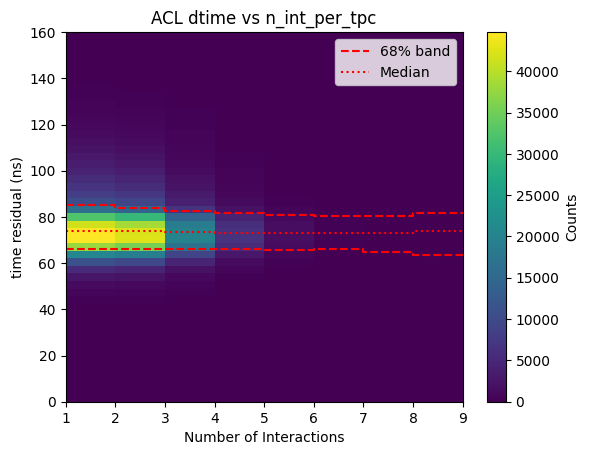

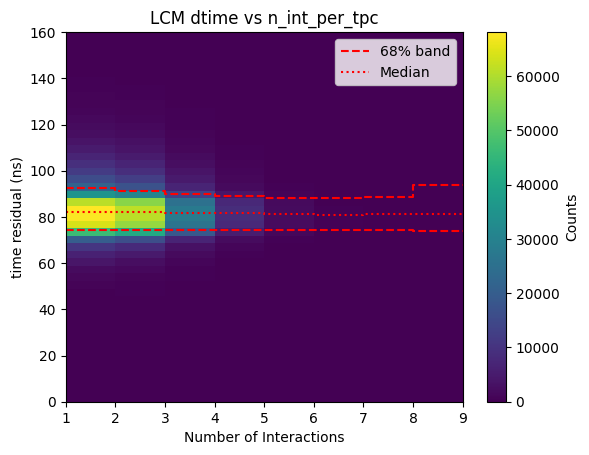

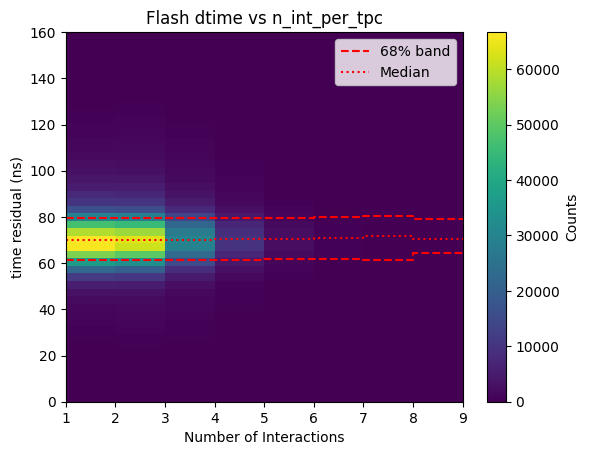

In [109]:
# for true_reco, plot the dtime vs n_int_per_tpc as a heatmap

xrange = np.linspace(1, 9, 9)  # To include value 11 in the last bin edge
yrange = np.linspace(0, 160, 50)

plot_heatmap(
    df_truth_reco,
    x_col='n_int_per_tpc',
    y_col='trap_0_dtime_ns',
    title='ACL dtime vs n_int_per_tpc',
    xlabel='Number of Interactions',
    ylabel='time residual (ns)',
    xrange=xrange,
    yrange=yrange,
    logx=False,
    logy=False
)

plot_heatmap(
    df_truth_reco,
    x_col='n_int_per_tpc',
    y_col='trap_1_dtime_ns',
    title='LCM dtime vs n_int_per_tpc',
    xlabel='Number of Interactions',
    ylabel='time residual (ns)',
    xrange=xrange,
    yrange=yrange,
    logx=False,
    logy=False
)

plot_heatmap(
    df_truth_reco,
    x_col='n_int_per_tpc',
    y_col='flash_dtime_ns',
    title='Flash dtime vs n_int_per_tpc',
    xlabel='Number of Interactions',
    ylabel='time residual (ns)',
    xrange=xrange,
    yrange=yrange,
    logx=False,
    logy=False
)

/global/homes/j/jvmead/.conda/envs/ndlar_flow/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1615: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(


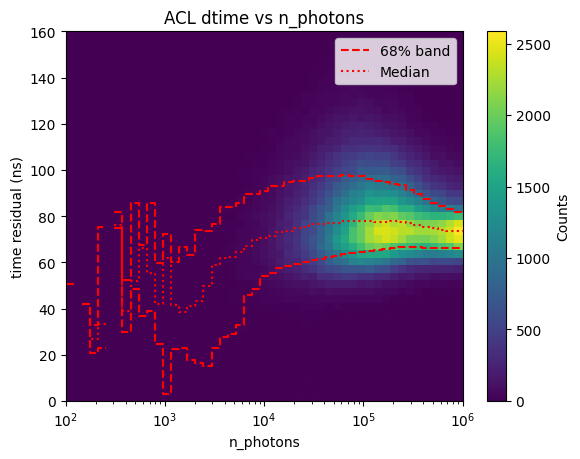

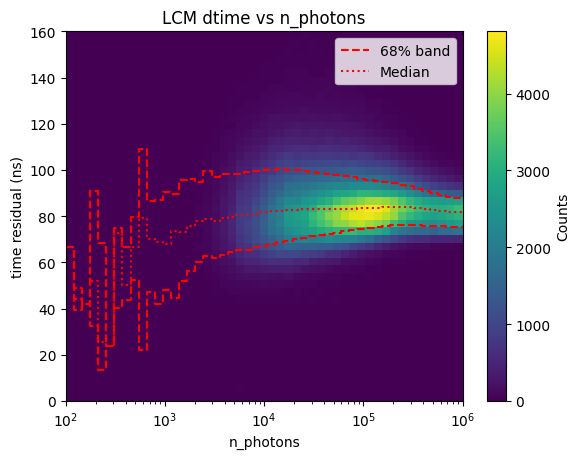

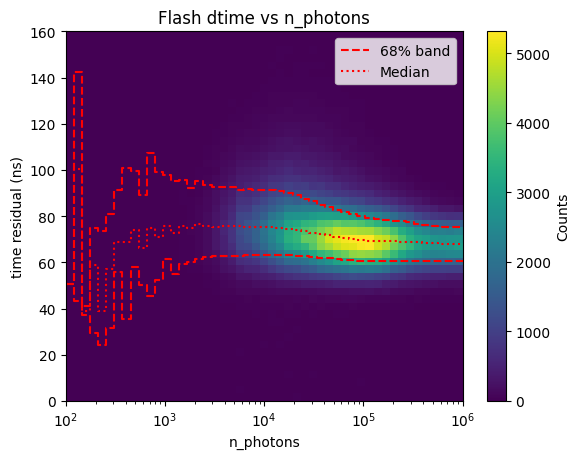

In [110]:
# for true_reco, plot the dtime vs n_photons (EMITTED) as a heatmap
# would be interesting to plot as f(n_photons_det) for actual intensity seen by the SiPMs
# using n_photons_det has some complications... WIP

xrange = np.logspace(2.0, 6.0, 50)  # To include value 11 in the last bin edge
yrange = np.linspace(0, 160, 50)

plot_heatmap(
    df_truth_reco,
    title='ACL dtime vs n_photons',
    x_col='nphoton_tot',
    y_col='trap_0_dtime_ns',
    xlabel='n_photons',
    ylabel='time residual (ns)',
    xrange=xrange,
    yrange=yrange,
    logx=True,
    logy=False
)

plot_heatmap(
    df_truth_reco,
    title='LCM dtime vs n_photons',
    x_col='nphoton_tot',
    y_col='trap_1_dtime_ns',
    xlabel='n_photons',
    ylabel='time residual (ns)',
    xrange=xrange,
    yrange=yrange,
    logx=True,
    logy=False
)

plot_heatmap(
    df_truth_reco,
    title='Flash dtime vs n_photons',
    x_col='nphoton_tot',
    y_col='flash_dtime_ns',
    xlabel='n_photons',
    ylabel='time residual (ns)',
    xrange=xrange,
    yrange=yrange,
    logx=True,
    logy=False
)

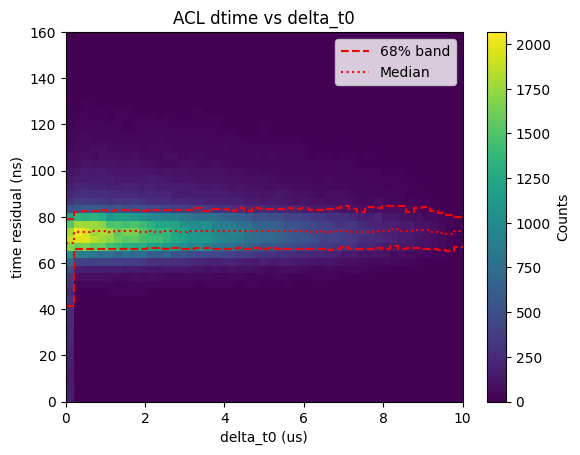

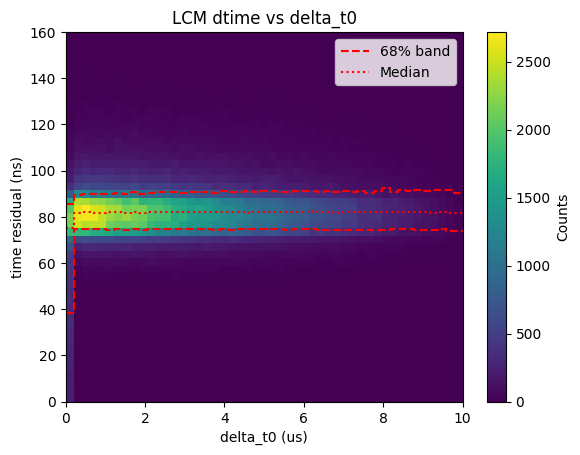

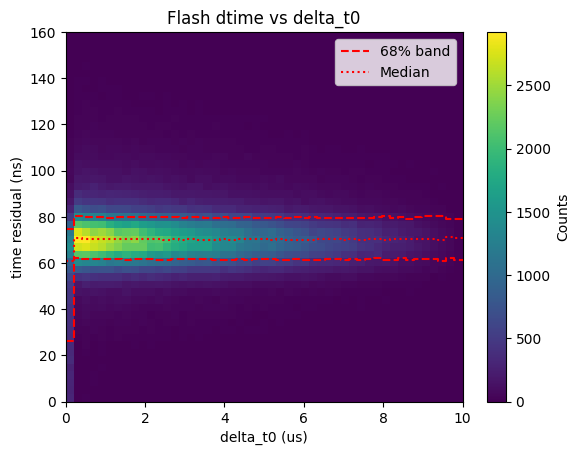

In [111]:
# for true_reco, plot the dtime vs delta_t between adjacemnt true interactions as a heatmap
# for all interactions, not just 2 int events, delta_t for hit 'i' is t_i - t_(i-1) in chronological order

xrange = np.linspace(0, 10, 50)  # To include value 11 in the last bin edge
yrange = np.linspace(0, 160, 50)

plot_heatmap(
    df_truth_reco,
    x_col='delta_t0',
    y_col='trap_0_dtime_ns',
    title='ACL dtime vs delta_t0',
    xlabel='delta_t0 (us)',
    ylabel='time residual (ns)',
    xrange=xrange,
    yrange=yrange,
    logx=False,
    logy=False
)

plot_heatmap(
    df_truth_reco,
    x_col='delta_t0',
    y_col='trap_1_dtime_ns',
    title='LCM dtime vs delta_t0',
    xlabel='delta_t0 (us)',
    ylabel='time residual (ns)',
    xrange=xrange,
    yrange=yrange,
    logx=False,
    logy=False
)

plot_heatmap(
    df_truth_reco,
    x_col='delta_t0',
    y_col='flash_dtime_ns',
    title='Flash dtime vs delta_t0',
    xlabel='delta_t0 (us)',
    ylabel='time residual (ns)',
    xrange=xrange,
    yrange=yrange,
    logx=False,
    logy=False
)

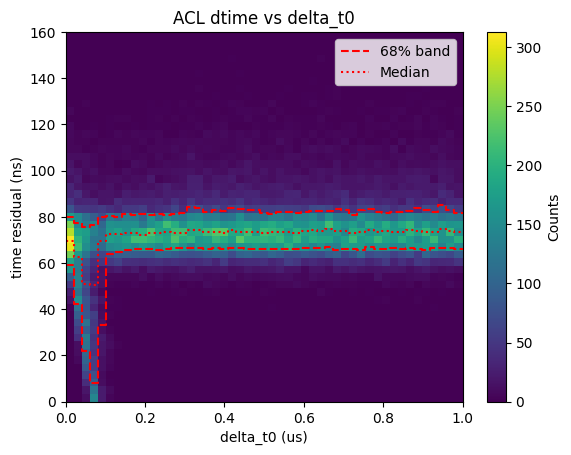

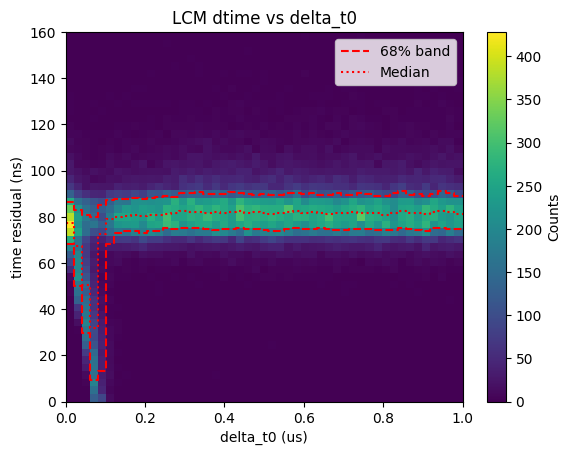

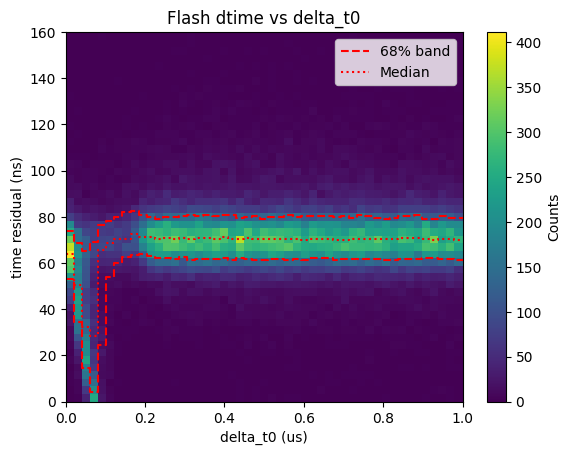

In [112]:
# for true_reco, plot the dtime vs delta_t between adjacemnt true interactions as a heatmap
# for all interactions, not just 2 int events, delta_t for hit 'i' is t_i - t_(i-1) in chronological order

xrange = np.linspace(0, 1, 50)  # To include value 11 in the last bin edge
yrange = np.linspace(0, 160, 50)

plot_heatmap(
    df_truth_reco,
    x_col='delta_t0',
    y_col='trap_0_dtime_ns',
    title='ACL dtime vs delta_t0',
    xlabel='delta_t0 (us)',
    ylabel='time residual (ns)',
    xrange=xrange,
    yrange=yrange,
    logx=False,
    logy=False
)

plot_heatmap(
    df_truth_reco,
    x_col='delta_t0',
    y_col='trap_1_dtime_ns',
    title='LCM dtime vs delta_t0',
    xlabel='delta_t0 (us)',
    ylabel='time residual (ns)',
    xrange=xrange,
    yrange=yrange,
    logx=False,
    logy=False
)

plot_heatmap(
    df_truth_reco,
    x_col='delta_t0',
    y_col='flash_dtime_ns',
    title='Flash dtime vs delta_t0',
    xlabel='delta_t0 (us)',
    ylabel='time residual (ns)',
    xrange=xrange,
    yrange=yrange,
    logx=False,
    logy=False
)

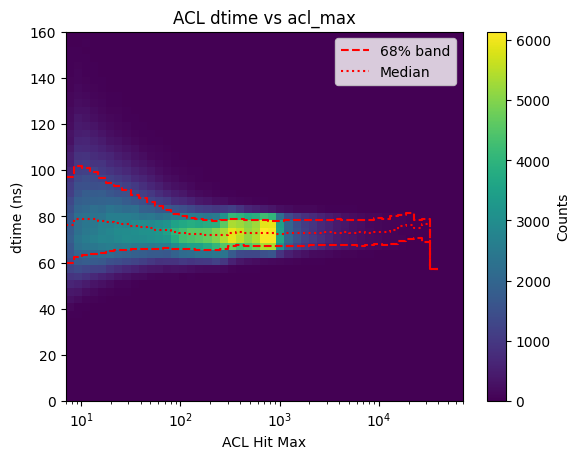

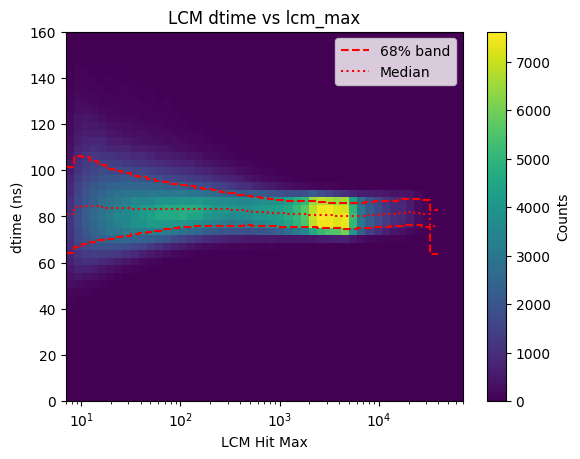

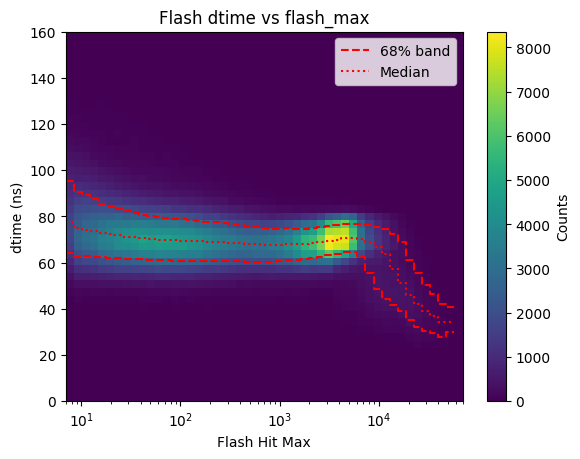

In [113]:
# for true_reco, plot the dtime vs max amplitude of reconstructed pulse as a heatmap
# as these are summed waveforms, this amplitude could be derived from a number of clipped waveforms

xrange = np.logspace(np.log10(7), np.log10(7e4), 50)  # Logarithmic scale for x-axis
yrange = np.linspace(0, 160, 50)

plot_heatmap(
    df_truth_reco,
    x_col='trap_0_max',
    y_col='trap_0_dtime_ns',
    title='ACL dtime vs acl_max',
    xlabel='ACL Hit Max',
    ylabel='dtime (ns)',
    xrange=xrange,
    yrange=yrange,
    logx=True,
    logy=False
)

plot_heatmap(
    df_truth_reco,
    x_col='trap_1_max',
    y_col='trap_1_dtime_ns',
    title='LCM dtime vs lcm_max',
    xlabel='LCM Hit Max',
    ylabel='dtime (ns)',
    xrange=xrange,
    yrange=yrange,
    logx=True,
    logy=False
)

plot_heatmap(
    df_truth_reco,
    x_col='flash_max',
    y_col='flash_dtime_ns',
    title='Flash dtime vs flash_max',
    xlabel='Flash Hit Max',
    ylabel='dtime (ns)',
    xrange=xrange,
    yrange=yrange,
    logx=True,
    logy=False
)

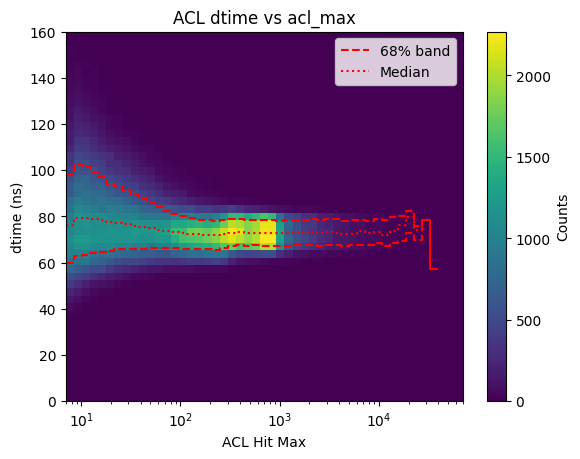

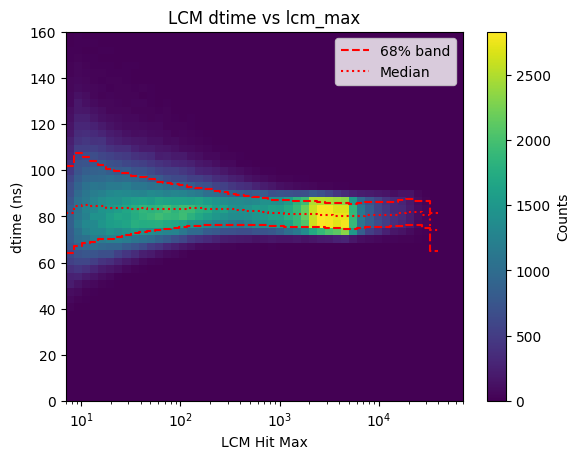

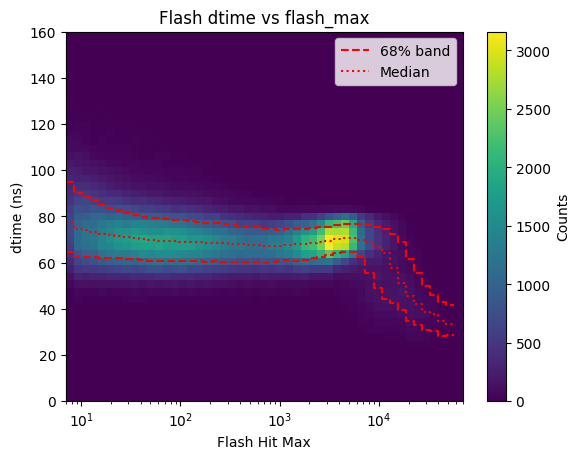

In [114]:
# for true_reco, plot the dtime vs n_int_per_tpc as a heatmap
#xrange = np.linspace(0, 1e3, 50)  # To include value 11 in the last bin edge
xrange = np.logspace(np.log10(7), np.log10(7e4), 50)  # Logarithmic scale for x-axis
yrange = np.linspace(0, 160, 50)

plot_heatmap(
    df_truth_reco_1int,
    x_col='trap_0_max',
    y_col='trap_0_dtime_ns',
    title='ACL dtime vs acl_max',
    xlabel='ACL Hit Max',
    ylabel='dtime (ns)',
    xrange=xrange,
    yrange=yrange,
    logx=True,
    logy=False
)

plot_heatmap(
    df_truth_reco_1int,
    x_col='trap_1_max',
    y_col='trap_1_dtime_ns',
    title='LCM dtime vs lcm_max',
    xlabel='LCM Hit Max',
    ylabel='dtime (ns)',
    xrange=xrange,
    yrange=yrange,
    logx=True,
    logy=False
)

plot_heatmap(
    df_truth_reco_1int,
    x_col='flash_max',
    y_col='flash_dtime_ns',
    title='Flash dtime vs flash_max',
    xlabel='Flash Hit Max',
    ylabel='dtime (ns)',
    xrange=xrange,
    yrange=yrange,
    logx=True,
    logy=False
)

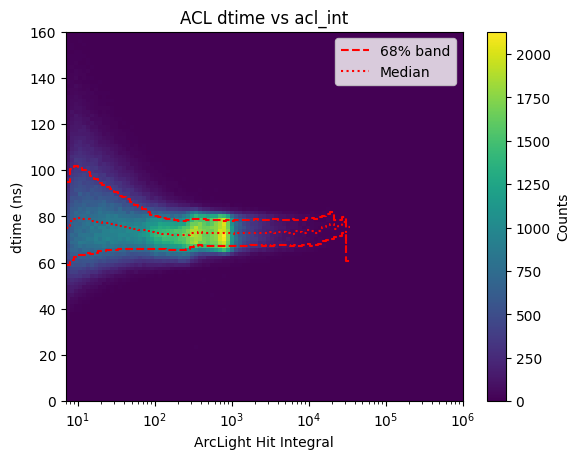

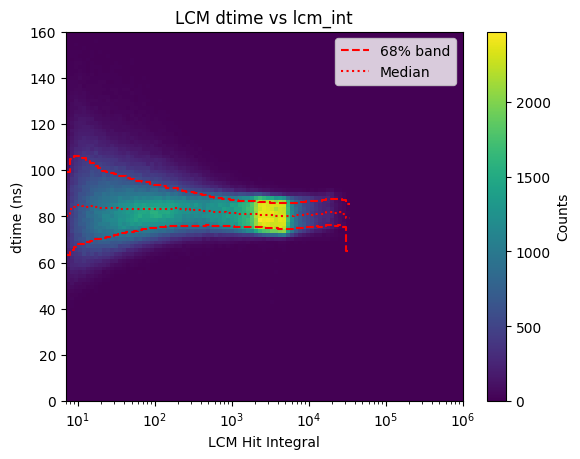

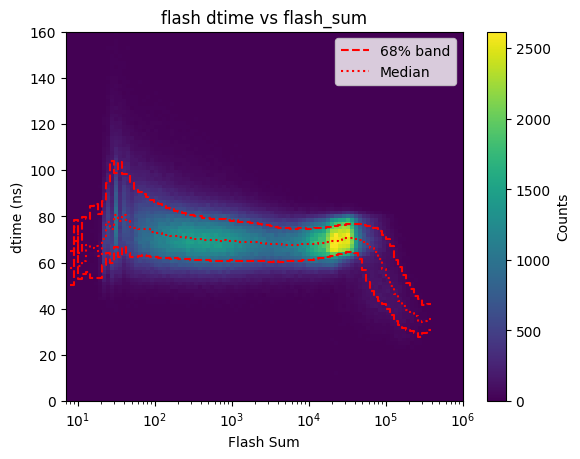

In [115]:
# dtime as function of lcm hit integral and acl hit integral
def plot_heatmap_integral(df, x_col, y_col, title, xlabel, ylabel, xrange, yrange):
    # Create a 2D histogram
    plt.hist2d(
        df[x_col], df[y_col],
        bins=[xrange, yrange],
        cmap='viridis',
        #norm=LogNorm(vmax=None, clip=True)
    )
    plt.colorbar(label='Counts (log scale)')
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    # now do the upper and lower quantiles using binning
    x_bin_centers = (xrange[:-1])
    y_upper = []
    y_centre = []
    y_lower = []

    for i in range(len(xrange) - 1):
        mask = (df[x_col] >= xrange[i]) & (df[x_col] < xrange[i+1])
        yvals = df.loc[mask, y_col]
        if len(yvals) > 0:
            y_upper.append(np.nanquantile(yvals, 0.84))
            y_centre.append(np.nanquantile(yvals, 0.5))
            y_lower.append(np.nanquantile(yvals, 0.16))
        else:
            y_upper.append(np.nan)
            y_centre.append(np.nan)
            y_lower.append(np.nan)

    plt.step(x_bin_centers, y_upper, color='red', label='68% band', linestyle='--', where='post')
    plt.step(x_bin_centers, y_centre, color='red', label='Median', linestyle=':', where='post')
    plt.step(x_bin_centers, y_lower, color='red', linestyle='--', where='post')
    # finish
    plt.xscale('log')
    plt.legend()
    plt.show()

xrange=np.logspace(np.log10(7), np.log10(1e6), 100)
yrange=np.linspace(0, 160, 100)

plot_heatmap(
    df_truth_reco,
    x_col='trap_0_max',
    y_col='trap_0_dtime_ns',
    title='ACL dtime vs acl_int',
    xlabel='ArcLight Hit Integral',
    ylabel='dtime (ns)',
    xrange=xrange,
    yrange=yrange,
    logx=True,
    logy=False
)

plot_heatmap(
    df_truth_reco,
    x_col='trap_1_max',
    y_col='trap_1_dtime_ns',
    title='LCM dtime vs lcm_int',
    xlabel='LCM Hit Integral',
    ylabel='dtime (ns)',
    xrange=xrange,
    yrange=yrange,
    logx=True,
    logy=False
)

plot_heatmap(
    df_truth_reco,
    x_col='flash_sum',
    y_col='flash_dtime_ns',
    title='flash dtime vs flash_sum',
    xlabel='Flash Sum',
    ylabel='dtime (ns)',
    xrange=xrange,
    yrange=yrange,
    logx=True,
    logy=False
)

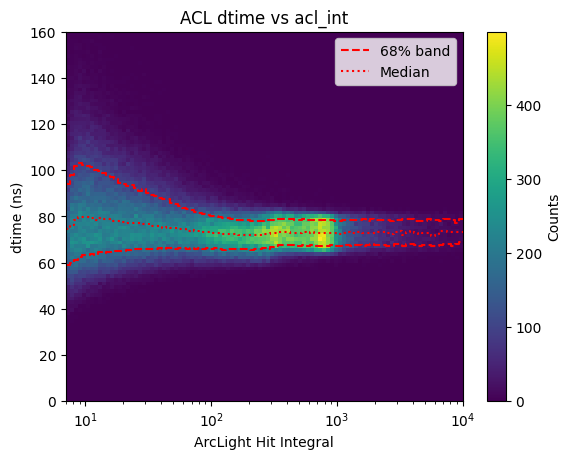

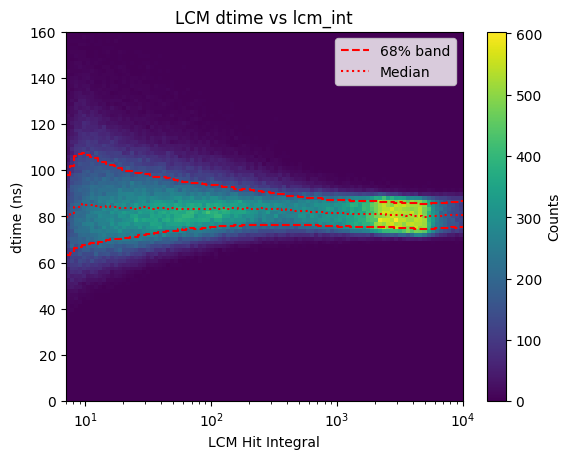

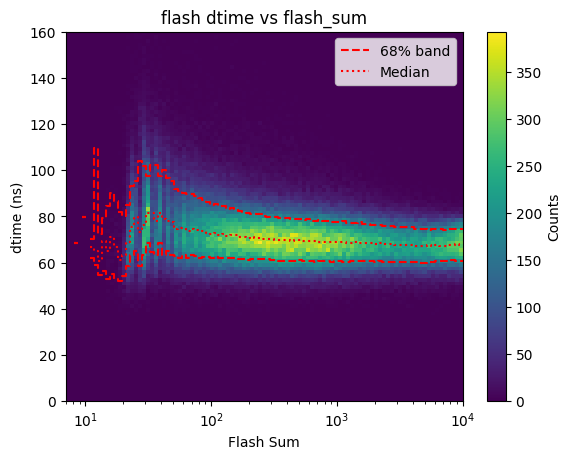

In [116]:
xrange=np.logspace(np.log10(7), np.log10(1e4), 100)
yrange=np.linspace(0, 160, 100)

plot_heatmap(
    df_truth_reco_1int,
    x_col='trap_0_max',
    y_col='trap_0_dtime_ns',
    title='ACL dtime vs acl_int',
    xlabel='ArcLight Hit Integral',
    ylabel='dtime (ns)',
    xrange=xrange,
    yrange=yrange,
    logx=True,
    logy=False
)

plot_heatmap(
    df_truth_reco_1int,
    x_col='trap_1_max',
    y_col='trap_1_dtime_ns',
    title='LCM dtime vs lcm_int',
    xlabel='LCM Hit Integral',
    ylabel='dtime (ns)',
    xrange=xrange,
    yrange=yrange,
    logx=True,
    logy=False
)

plot_heatmap(
    df_truth_reco_1int,
    x_col='flash_sum',
    y_col='flash_dtime_ns',
    title='flash dtime vs flash_sum',
    xlabel='Flash Sum',
    ylabel='dtime (ns)',
    xrange=xrange,
    yrange=yrange,
    logx=True,
    logy=False
)

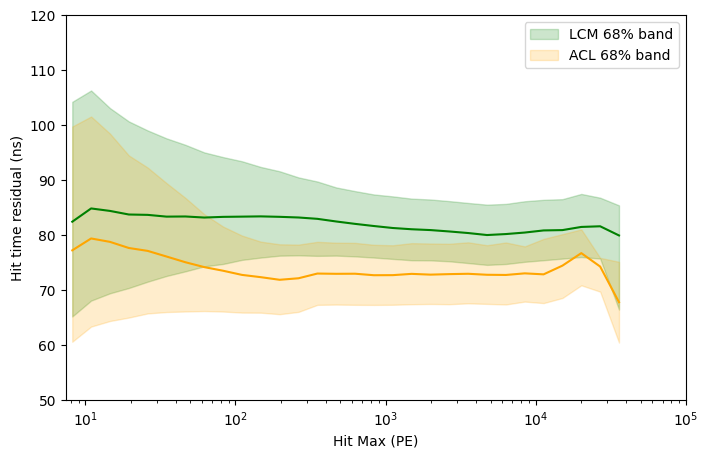

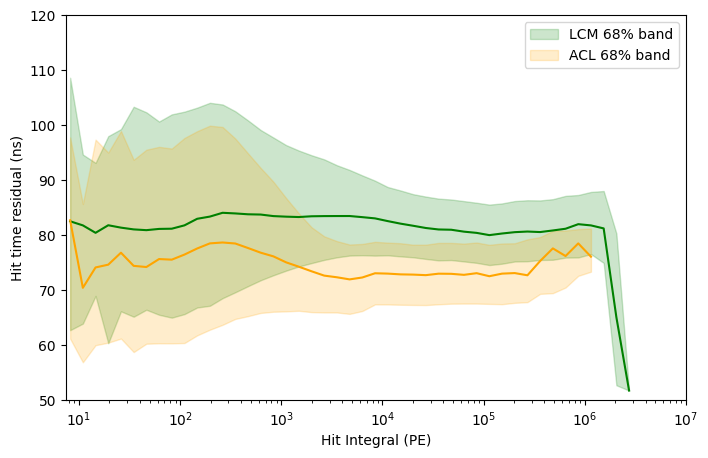

In [117]:
import seaborn as sns

def plot_bands(df, x_col, y_col, color, label, bins):
    # Compute quantiles in each x bin (log bins)
    x_bin_centers = (bins[:-1] + bins[1:]) / 2
    y_upper = []
    y_centre = []
    y_lower = []

    for i in range(len(bins) - 1):
        mask = (df[x_col] >= bins[i]) & (df[x_col] < bins[i+1])
        yvals = df.loc[mask, y_col]
        if len(yvals) > 0:
            y_upper.append(np.nanquantile(yvals, 0.84))
            y_centre.append(np.nanquantile(yvals, 0.5))
            y_lower.append(np.nanquantile(yvals, 0.16))
        else:
            y_upper.append(np.nan)
            y_centre.append(np.nan)
            y_lower.append(np.nan)

    plt.fill_between(x_bin_centers, y_lower, y_upper, color=color, alpha=0.2, label=f'{label} 68% band')
    plt.plot(x_bin_centers, y_centre, color=color)



plt.figure(figsize=(8, 5))
bins = np.logspace(np.log10(7), np.log10(1e7), 50)
plot_bands(
    df_truth_reco_1int,
    x_col='trap_1_max',
    y_col='trap_1_dtime_ns',
    color='green',
    label='LCM',
    bins=bins
)
plot_bands(
    df_truth_reco_1int,
    x_col='trap_0_max',
    y_col='trap_0_dtime_ns',
    color='orange',
    label='ACL',
    bins=bins
)
plt.xscale('log')
plt.xlabel('Hit Max (PE)')
plt.ylabel('Hit time residual (ns)')
plt.xlim(7.4, 1e5)
plt.ylim(50, 120)
plt.legend()
#plt.grid(which='both', linestyle='--', linewidth=0.5)
plt.show()


plt.figure(figsize=(8, 5))

bins = np.logspace(np.log10(7), np.log10(1e7), 50)
plot_bands(
    df_truth_reco_1int,
    x_col='trap_1_integral',
    y_col='trap_1_dtime_ns',
    color='green',
    label='LCM',
    bins=bins
)
plot_bands(
    df_truth_reco_1int,
    x_col='trap_0_integral',
    y_col='trap_0_dtime_ns',
    color='orange',
    label='ACL',
    bins=bins
)

plt.xscale('log')
plt.xlabel('Hit Integral (PE)')
plt.ylabel('Hit time residual (ns)')
plt.xlim(7.4, 1e7)
plt.ylim(50, 120)
plt.legend()
#plt.grid(which='both', linestyle='--', linewidth=0.5)
plt.show()


In [118]:
# function to plot the size of the interval containing 68% of the data as a function of x, as points with error bars
def plot_68_interval_size(df, x_col, y_col, color, label, bins):
    # Compute quantiles in each x bin (log bins)
    x_bin_centers = (bins[:-1] + bins[1:]) / 2
    y_upper = []
    y_lower = []
    y_size = []
    y_err = []

    for i in range(len(bins) - 1):
        mask = (df[x_col] >= bins[i]) & (df[x_col] < bins[i+1])
        yvals = df.loc[mask, y_col]
        n = len(yvals)
        if n > 0:
            q84 = np.nanquantile(yvals, 0.84)
            q16 = np.nanquantile(yvals, 0.16)
            y_upper.append(q84)
            y_lower.append(q16)
            size = q84 - q16
            y_size.append(size)
            # Use 0.959 * sigma / sqrt(n) as the uncertainty on the interval
            sigma = np.nanstd(yvals)
            y_err.append(0.959 * sigma / np.sqrt(n))
        else:
            y_upper.append(np.nan)
            y_lower.append(np.nan)
            y_size.append(np.nan)
            y_err.append(np.nan)

    plt.errorbar(x_bin_centers, y_size, yerr=y_err, fmt='o', color=color, label=label)
    plt.xlabel(x_col)
    plt.ylabel(f"Size of 68% interval in {y_col}")
    plt.legend()

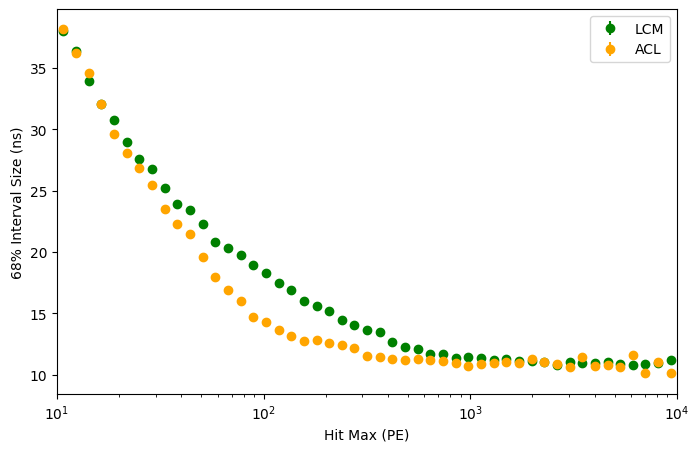

In [119]:
plt.figure(figsize=(8, 5))

bins = np.logspace(np.log10(1e1), np.log10(1e4), 50)
#bins = np.linspace(0, 1e6, 50)

plot_68_interval_size(
    df_truth_reco_1int,
    x_col='trap_1_max',
    y_col='trap_1_dtime_ns',
    color='green',
    label='LCM',
    bins=bins
)
plot_68_interval_size(
    df_truth_reco_1int,
    x_col='trap_0_max',
    y_col='trap_0_dtime_ns',
    color='orange',
    label='ACL',
    bins=bins
)
plt.xscale('log')
#plt.yscale('log')
plt.xlabel('Hit Max (PE)')
plt.ylabel('68% Interval Size (ns)')
plt.xlim(1e1, 1e4)
#plt.ylim(1, 70)
plt.legend()
#plt.grid(which='both', linestyle='--', linewidth=0.5)
plt.show()

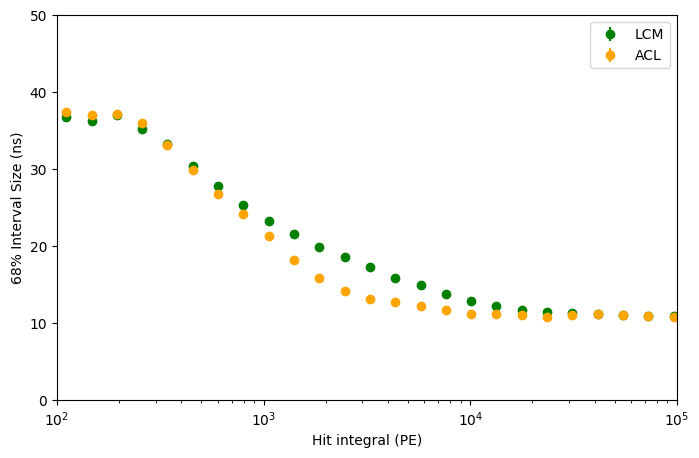

In [120]:
plt.figure(figsize=(8, 5))

bins = np.logspace(np.log10(1e1), np.log10(1e7), 50)
#bins = np.linspace(0, 1e6, 50)

plot_68_interval_size(
    df_truth_reco_1int,
    x_col='trap_1_integral',
    y_col='trap_1_dtime_ns',
    color='green',
    label='LCM',
    bins=bins
)
plot_68_interval_size(
    df_truth_reco_1int,
    x_col='trap_0_integral',
    y_col='trap_0_dtime_ns',
    color='orange',
    label='ACL',
    bins=bins
)
plt.xscale('log')
#plt.yscale('log')
plt.xlabel('Hit integral (PE)')
plt.ylabel('68% Interval Size (ns)')
plt.xlim(1e2, 1e5)
plt.ylim(0, 50)
plt.legend()
#plt.grid(which='both', linestyle='--', linewidth=0.5)
plt.show()

In [121]:
# add new info to df_truth_reco_1int
# lcm_integral * lcm_fprompt = lcm_int_prompt
df_truth_reco_1int['trap_1_int_prompt'] = df_truth_reco_1int['trap_1_integral'] * df_truth_reco_1int['trap_1_fprompt']
df_truth_reco_1int['trap_0_int_prompt'] = df_truth_reco_1int['trap_0_integral'] * df_truth_reco_1int['trap_0_fprompt']

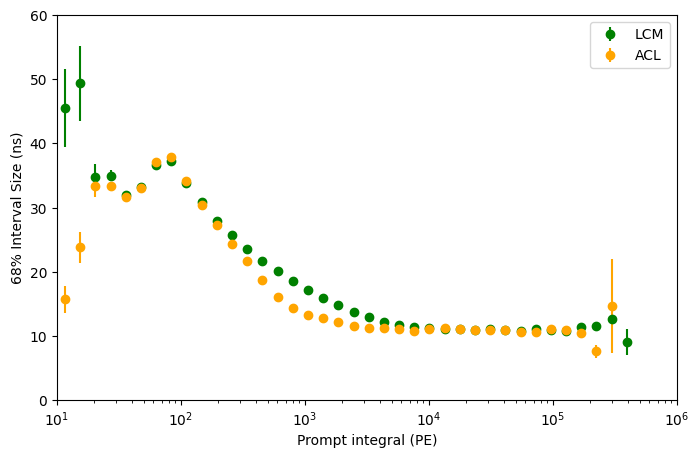

In [122]:
plt.figure(figsize=(8, 5))

bins = np.logspace(np.log10(1e1), np.log10(1e7), 50)
#bins = np.linspace(0, 1e6, 50)

plot_68_interval_size(
    df_truth_reco_1int,
    x_col='trap_1_int_prompt',
    y_col='trap_1_dtime_ns',
    color='green',
    label='LCM',
    bins=bins
)
plot_68_interval_size(
    df_truth_reco_1int,
    x_col='trap_0_int_prompt',
    y_col='trap_0_dtime_ns',
    color='orange',
    label='ACL',
    bins=bins
)
plt.xscale('log')
#plt.yscale('log')
plt.xlabel('Prompt integral (PE)')
plt.ylabel('68% Interval Size (ns)')
plt.xlim(1e1, 1e6)
plt.ylim(0, 60)
plt.legend()
#plt.grid(which='both', linestyle='--', linewidth=0.5)
plt.show()

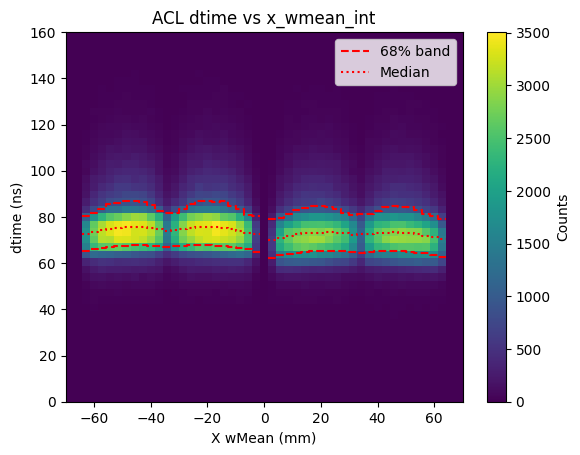

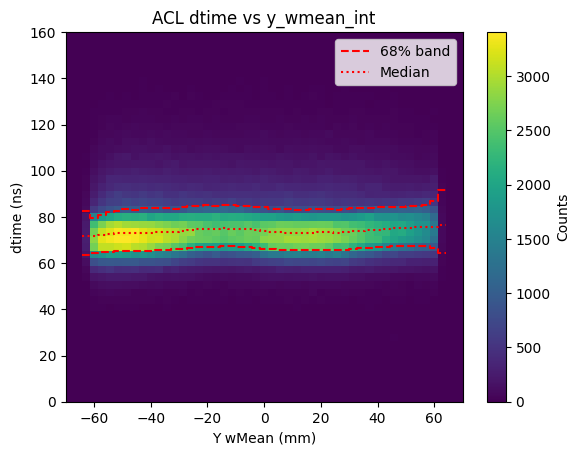

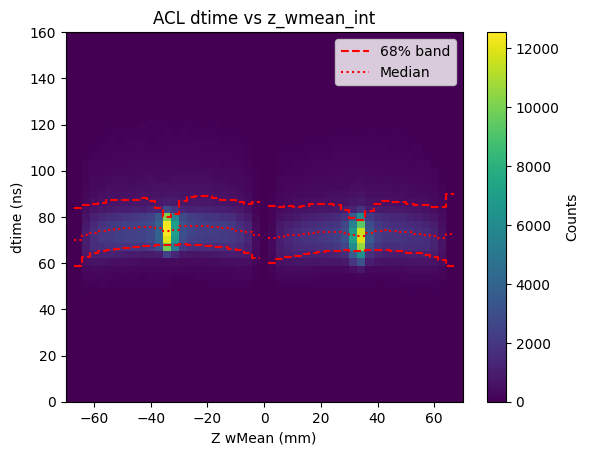

In [123]:
# plot time residual vs first segment position (x_mean, y_mean, z_mean)

plot_heatmap(
    df_truth_reco,
    x_col='x_wmean_int',
    y_col='trap_0_dtime_ns',
    title='ACL dtime vs x_wmean_int',
    xlabel='X wMean (mm)',
    ylabel='dtime (ns)',
    xrange=np.linspace(-70, 70, 50),
    yrange=np.linspace(0, 160, 50),
    logx=False,
    logy=False
)

plot_heatmap(
    df_truth_reco,
    x_col='y_wmean_int',
    y_col='trap_0_dtime_ns',
    title='ACL dtime vs y_wmean_int',
    xlabel='Y wMean (mm)',
    ylabel='dtime (ns)',
    xrange=np.linspace(-70, 70, 50),
    yrange=np.linspace(0, 160, 50),
    logx=False,
    logy=False
)

plot_heatmap(
    df_truth_reco,
    x_col='z_wmean_int',
    y_col='trap_0_dtime_ns',
    title='ACL dtime vs z_wmean_int',
    xlabel='Z wMean (mm)',
    ylabel='dtime (ns)',
    xrange=np.linspace(-70, 70, 50),
    yrange=np.linspace(0, 160, 50),
    logx=False,
    logy=False
)

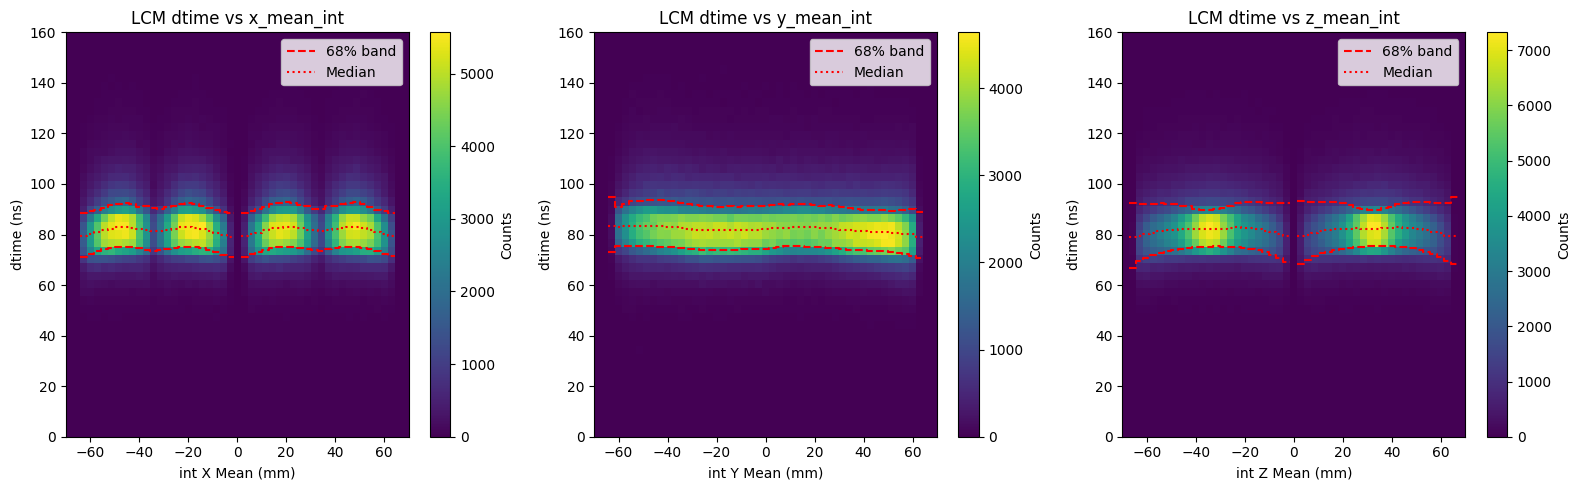

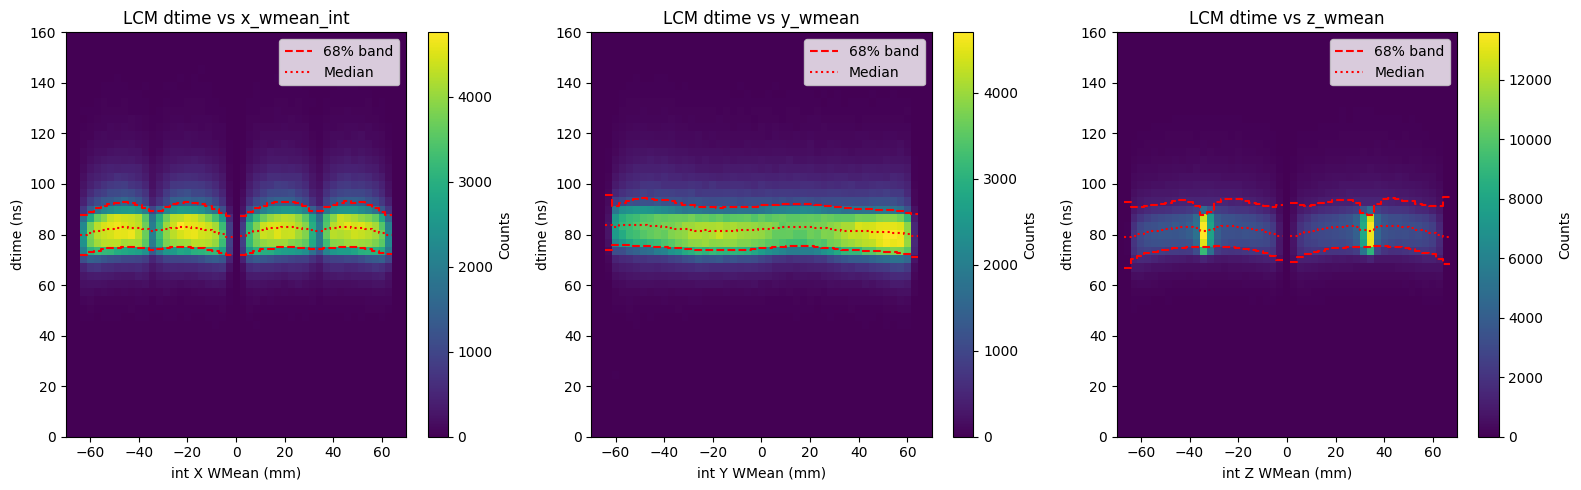

In [124]:
# comparing x_mean, x_mean_int, x_wmean_int in subplots
# x_mean is midpoint of the earliest segment per interaction per TPC
# x_mean_int is mean of all segments per interaction per TPC
# x_wmean_int is weighted mean of all segments per interaction per TPC, weighted by segment dE

def plot_heatmap_subplots(df, x_cols, y_col, titles, xlabels, ylabel, xrange, yrange):
    fig, axs = plt.subplots(1, 3, figsize=(16, 5))
    for i, x_col in enumerate(x_cols):
        ax = axs[i]
        h = ax.hist2d(
            df[x_col], df[y_col],
            bins=[xrange, yrange],
            cmap='viridis',
        )
        plt.colorbar(h[3], ax=ax, label='Counts')
        ax.set_title(titles[i])
        ax.set_xlabel(xlabels[i])
        ax.set_ylabel(ylabel)
        # Quantiles
        x_bin_centers = xrange[:-1]
        y_upper, y_centre, y_lower = [], [], []
        for j in range(len(xrange) - 1):
            mask = (df[x_col] >= xrange[j]) & (df[x_col] < xrange[j+1])
            yvals = df.loc[mask, y_col]
            if len(yvals) > 0:
                y_upper.append(np.nanquantile(yvals, 0.84))
                y_centre.append(np.nanquantile(yvals, 0.5))
                y_lower.append(np.nanquantile(yvals, 0.16))
            else:
                y_upper.append(np.nan)
                y_centre.append(np.nan)
                y_lower.append(np.nan)
        ax.step(x_bin_centers, y_upper, color='red', label='68% band', linestyle='--', where='post')
        ax.step(x_bin_centers, y_centre, color='red', label='Median', linestyle=':', where='post')
        ax.step(x_bin_centers, y_lower, color='red', linestyle='--', where='post')
        ax.legend()
    plt.tight_layout()
    plt.show()


plot_heatmap_subplots(
    df_truth_reco,
    x_cols=['x_mean_int', 'y_mean_int', 'z_mean_int'],
    y_col='trap_1_dtime_ns',
    titles=['LCM dtime vs x_mean_int', 'LCM dtime vs y_mean_int', 'LCM dtime vs z_mean_int'],
    xlabels=['int X Mean (mm)', 'int Y Mean (mm)', 'int Z Mean (mm)'],
    ylabel='dtime (ns)',
    xrange=np.linspace(-70, 70, 50),
    yrange=np.linspace(0, 160, 50)
)

plot_heatmap_subplots(
    df_truth_reco,
    x_cols=['x_wmean_int', 'y_wmean_int', 'z_wmean_int'],
    y_col='trap_1_dtime_ns',
    titles=['LCM dtime vs x_wmean_int', 'LCM dtime vs y_wmean', 'LCM dtime vs z_wmean'],
    xlabels=['int X WMean (mm)', 'int Y WMean (mm)', 'int Z WMean (mm)'],
    ylabel='dtime (ns)',
    xrange=np.linspace(-70, 70, 50),
    yrange=np.linspace(0, 160, 50)
)

In [125]:
def plot_bands_overlay_subplots(df, x_cols, y_col_list, titles, xlabels, ylabel, xrange, yrange, colors, labels):
    fig, axs = plt.subplots(1, len(x_cols), figsize=(15, 5))
    for i, x_col in enumerate(x_cols):
        ax = axs[i]
        for y_col, color, label in zip(y_col_list, colors, labels):
            x_bin_centers = xrange[:-1]
            y_upper, y_centre, y_lower = [], [], []
            for j in range(len(xrange) - 1):
                mask = (df[x_col] >= xrange[j]) & (df[x_col] < xrange[j+1])
                yvals = df.loc[mask, y_col]
                if len(yvals) > 0:
                    y_upper.append(np.nanquantile(yvals, 0.84))
                    y_centre.append(np.nanquantile(yvals, 0.5))
                    y_lower.append(np.nanquantile(yvals, 0.16))
                else:
                    y_upper.append(np.nan)
                    y_centre.append(np.nan)
                    y_lower.append(np.nan)
            ax.fill_between(x_bin_centers, y_lower, y_upper, color=color, alpha=0.2, label=f'{label} 68% band')
            ax.plot(x_bin_centers, y_centre, color=color, label=f'{label} median')
        ax.set_title(titles[i])
        ax.set_xlabel(xlabels[i])
        ax.set_ylabel(ylabel)
        ax.legend()
    plt.tight_layout()
    plt.show()

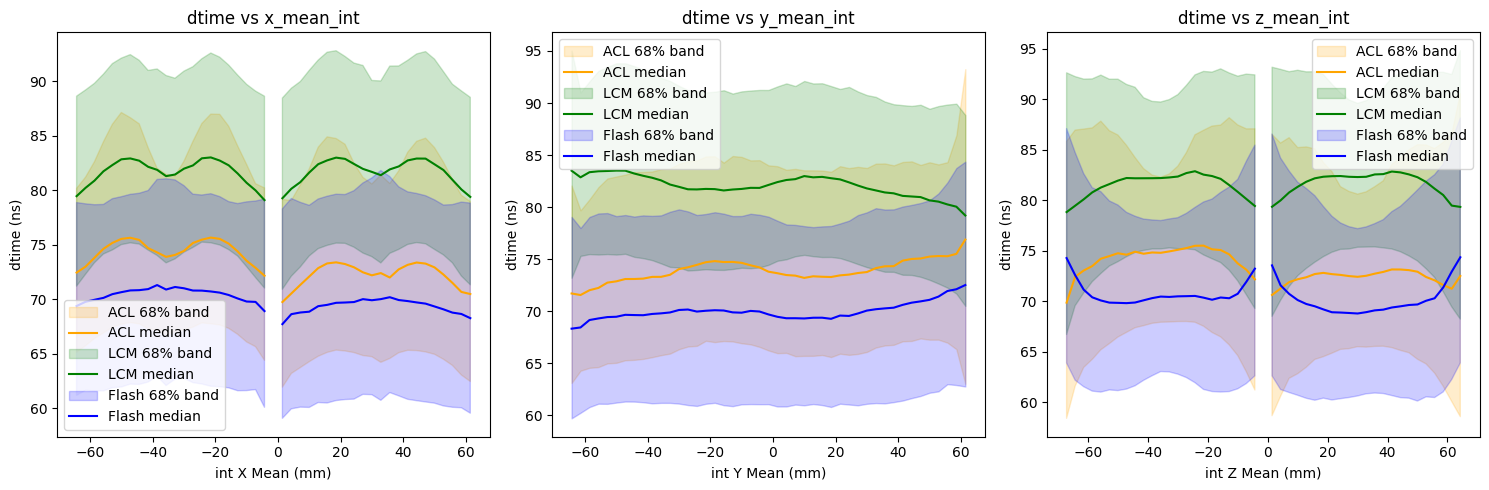

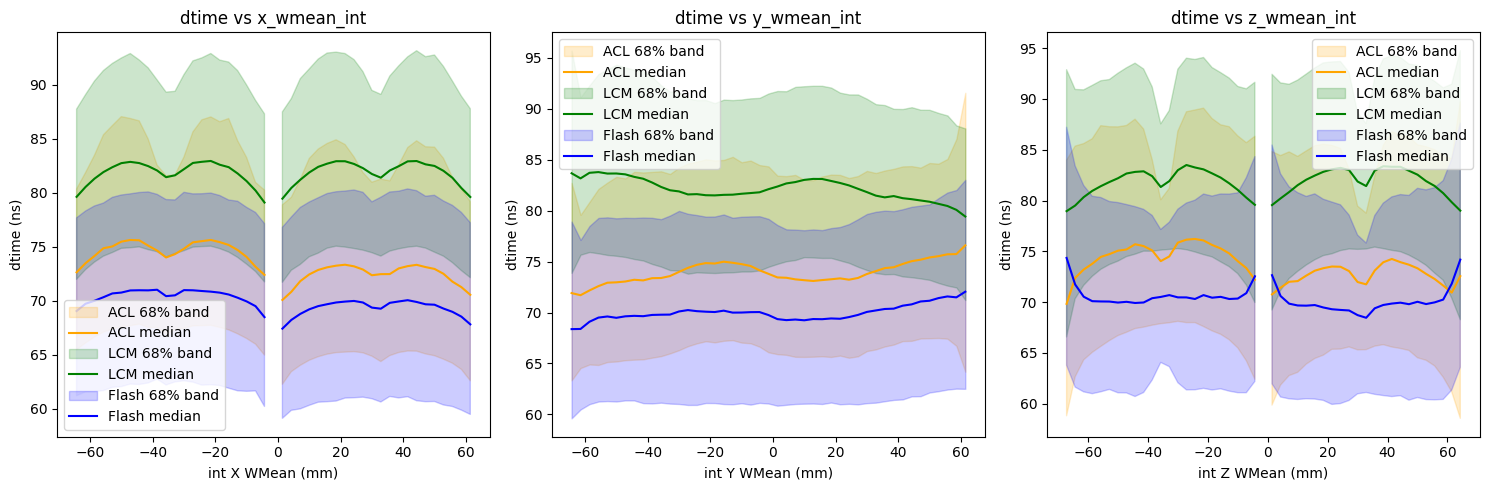

In [126]:
plot_bands_overlay_subplots(
    df_truth_reco,
    x_cols=['x_mean_int', 'y_mean_int', 'z_mean_int'],
    y_col_list=['trap_0_dtime_ns', 'trap_1_dtime_ns', 'flash_dtime_ns'],
    titles=['dtime vs x_mean_int', 'dtime vs y_mean_int', 'dtime vs z_mean_int'],
    xlabels=['int X Mean (mm)', 'int Y Mean (mm)', 'int Z Mean (mm)'],
    ylabel='dtime (ns)',
    xrange=np.linspace(-70, 70, 50),
    yrange=np.linspace(0, 160, 50),
    colors=['orange', 'green', 'blue'],
    labels=['ACL', 'LCM', 'Flash']
)

plot_bands_overlay_subplots(
    df_truth_reco,
    x_cols=['x_wmean_int', 'y_wmean_int', 'z_wmean_int'],
    y_col_list=['trap_0_dtime_ns', 'trap_1_dtime_ns', 'flash_dtime_ns'],
    titles=['dtime vs x_wmean_int', 'dtime vs y_wmean_int', 'dtime vs z_wmean_int'],
    xlabels=['int X WMean (mm)', 'int Y WMean (mm)', 'int Z WMean (mm)'],
    ylabel='dtime (ns)',
    xrange=np.linspace(-70, 70, 50),
    yrange=np.linspace(0, 160, 50),
    colors=['orange', 'green', 'blue'],
    labels=['ACL', 'LCM', 'Flash']
)


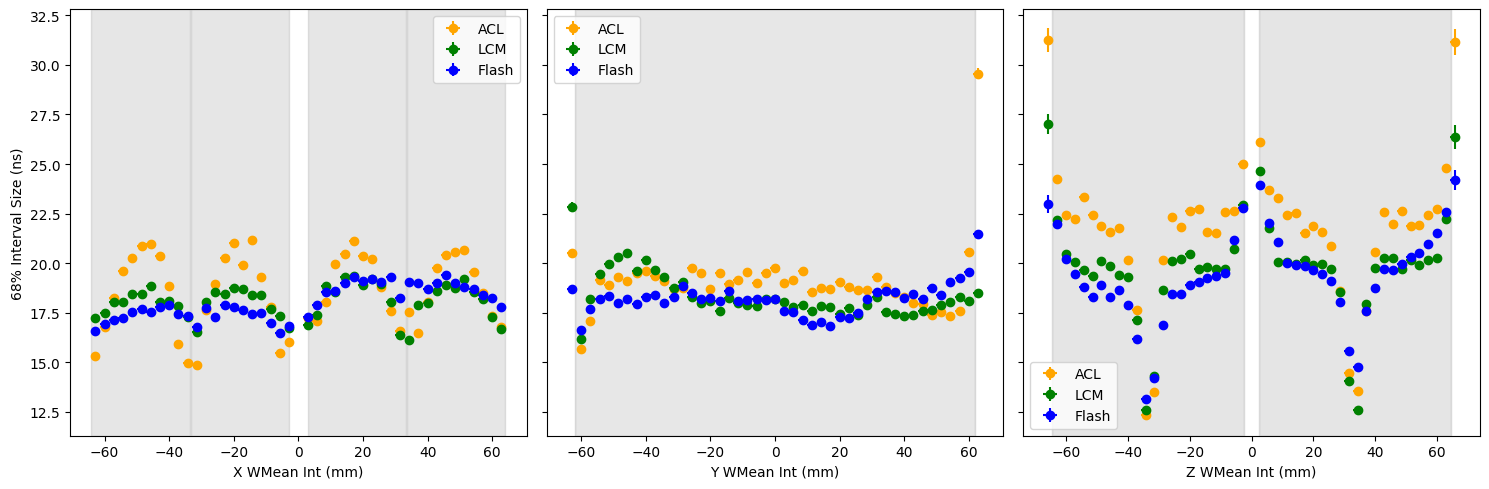

In [127]:
# function like plot_68_interval_size but for overlay as subplots xyz, with x-error bars
def plot_68_interval_size_overlay_subplots(df, x_cols, y_col_list, titles,
                                           xlabels, ylabel, xranges, yrange,
                                           colors, labels, overlay_bounds=None):
    fig, axs = plt.subplots(1, len(x_cols), figsize=(15, 5), sharey=True)
    for i, x_col in enumerate(x_cols):
        ax = axs[i]
        xrange = xranges[i]  # Use the specific xrange for this subplot
        if overlay_bounds is not None:
            i_bounds = overlay_bounds[i]
            for ii in range(len(i_bounds)):
                if i == 0:  # only label for first subplot
                    alpha = 0.2
                elif i == 1:
                    alpha = 0.05
                else:
                    alpha = 0.1
                ax.axvspan(i_bounds[ii][0], i_bounds[ii][1], color='gray', alpha=alpha/2)
        for y_col, color, label in zip(y_col_list, colors, labels):
            x_bin_centers = (xrange[:-1] + xrange[1:]) / 2
            x_bin_width = (xrange[1:] - xrange[:-1]) / 2
            y_upper, y_lower, y_size, y_err = [], [], [], []
            for j in range(len(xrange) - 1):
                mask = (df[x_col] >= xrange[j]) & (df[x_col] < xrange[j+1])
                yvals = df.loc[mask, y_col]
                n = len(yvals)
                if n > 0:
                    q84 = np.nanquantile(yvals, 0.84)
                    q16 = np.nanquantile(yvals, 0.16)
                    y_upper.append(q84)
                    y_lower.append(q16)
                    size = q84 - q16
                    y_size.append(size)
                    sigma = np.nanstd(yvals)
                    y_err.append(0.959 * sigma / np.sqrt(n))
                else:
                    y_upper.append(np.nan)
                    y_lower.append(np.nan)
                    y_size.append(np.nan)
                    y_err.append(np.nan)
            ax.errorbar(x_bin_centers, y_size, xerr=x_bin_width, yerr=y_err, fmt='o', color=color, label=label)
        ax.set_title(titles[i])
        ax.set_xlabel(xlabels[i])
        if i == 0:
            ax.set_ylabel(ylabel)
        ax.legend()
    plt.tight_layout()
    plt.show()

plot_68_interval_size_overlay_subplots(
    df_truth_reco_1int,
    x_cols=['x_wmean_int', 'y_wmean_int', 'z_wmean_int'],
    y_col_list=['trap_0_dtime_ns', 'trap_1_dtime_ns', 'flash_dtime_ns'],
    titles=[None, None, None], #['dtime vs x_wmean_int', 'dtime vs y_wmean_int', 'dtime vs z_wmean_int'],
    xlabels=['X WMean Int (mm)', 'Y WMean Int (mm)', 'Z WMean Int (mm)'],
    ylabel='68% Interval Size (ns)',
    xranges = [np.linspace(-70, 70, 50)]*3,
    yrange=np.linspace(0, 160, 50),
    colors=['orange', 'green', 'blue'],
    labels=['ACL', 'LCM', 'Flash'],
    overlay_bounds=[x_bounds,y_bounds,z_bounds]
)


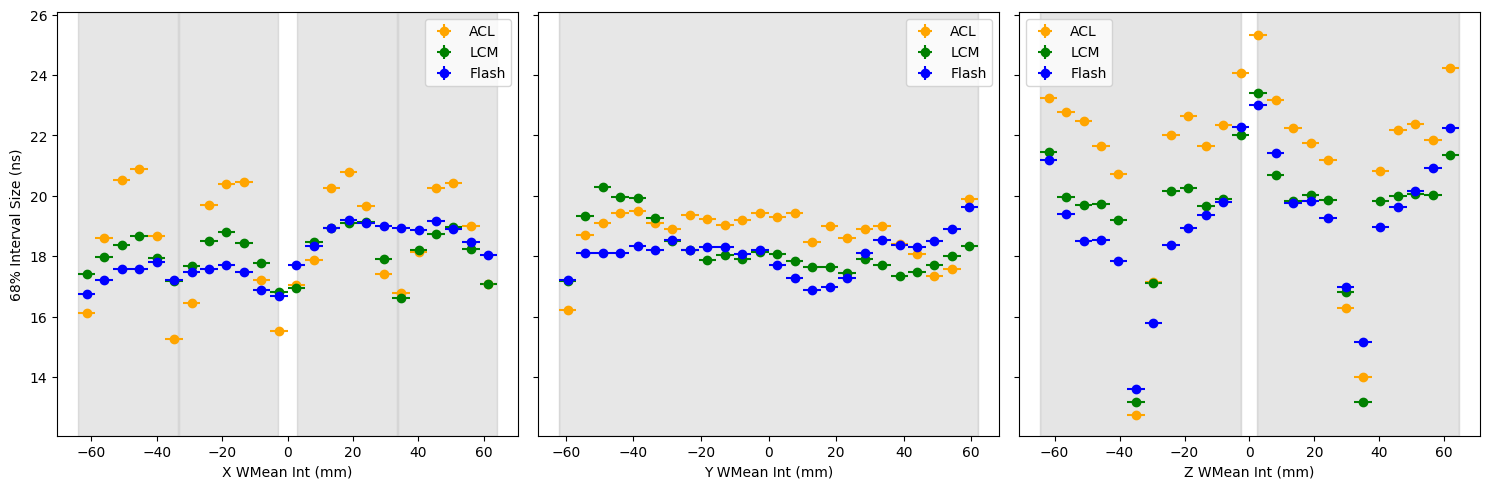

In [128]:
# get binning range from x_bounds
xmin = min([b[0] for b in x_bounds])
xmax = max([b[1] for b in x_bounds])
x_xrange = np.linspace(xmin, xmax, 25)
ymin = min([b[0] for b in y_bounds])
ymax = max([b[1] for b in y_bounds])
y_xrange = np.linspace(ymin, ymax, 25)
zmin = min([b[0] for b in z_bounds])
zmax = max([b[1] for b in z_bounds])
z_xrange = np.linspace(zmin, zmax, 25)


plot_68_interval_size_overlay_subplots(
    df_truth_reco_1int,
    x_cols=['x_wmean_int', 'y_wmean_int', 'z_wmean_int'],
    y_col_list=['trap_0_dtime_ns', 'trap_1_dtime_ns', 'flash_dtime_ns'],
    titles=[None, None, None], #['dtime vs x_wmean_int', 'dtime vs y_wmean_int', 'dtime vs z_wmean_int'],
    xlabels=['X WMean Int (mm)', 'Y WMean Int (mm)', 'Z WMean Int (mm)'],
    ylabel='68% Interval Size (ns)',
    xranges=[x_xrange, y_xrange, z_xrange],
    yrange=np.linspace(0, 160, 50),
    colors=['orange', 'green', 'blue'],
    labels=['ACL', 'LCM', 'Flash'],
    overlay_bounds=[x_bounds,y_bounds,z_bounds]
)

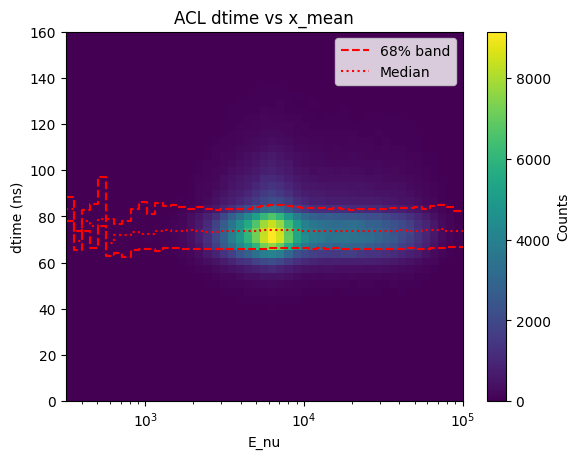

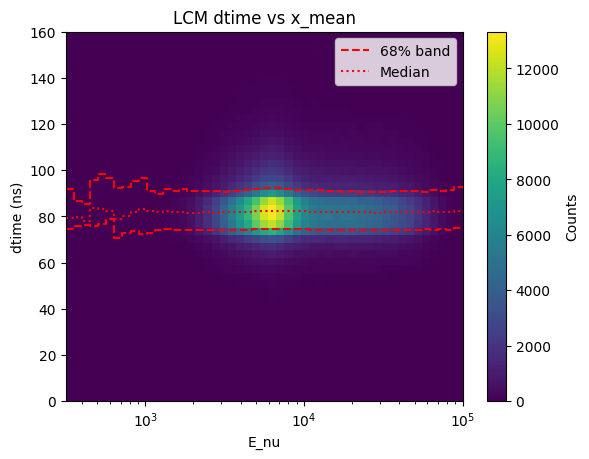

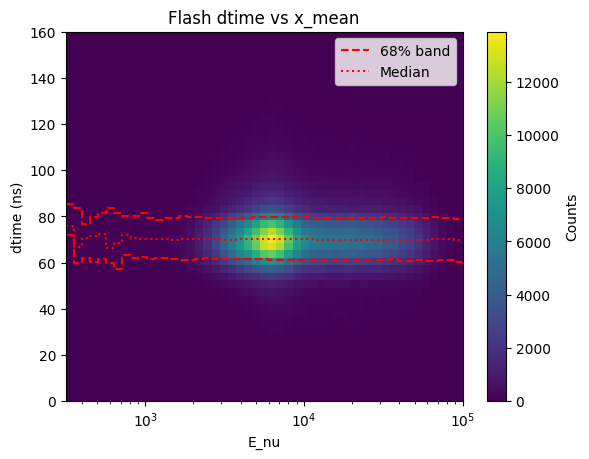

In [129]:
# plot dtime vs enu as a heatmap
xrange=np.logspace(2.5, 5, 50)  # 1 to 10,000
yrange=np.linspace(0, 160, 50)

plot_heatmap(
    df_truth_reco,
    x_col='enu',
    y_col='trap_0_dtime_ns',
    title='ACL dtime vs x_mean',
    xlabel='E_nu',
    ylabel='dtime (ns)',
    xrange=xrange,
    yrange=yrange,
    logx=True,
    logy=False
)
plot_heatmap(
    df_truth_reco,
    x_col='enu',
    y_col='trap_1_dtime_ns',
    title='LCM dtime vs x_mean',
    xlabel='E_nu',
    ylabel='dtime (ns)',
    xrange=xrange,
    yrange=yrange,
    logx=True,
    logy=False
)
plot_heatmap(
    df_truth_reco,
    x_col='enu',
    y_col='flash_dtime_ns',
    title='Flash dtime vs x_mean',
    xlabel='E_nu',
    ylabel='dtime (ns)',
    xrange=xrange,
    yrange=yrange,
    logx=True,
    logy=False
)

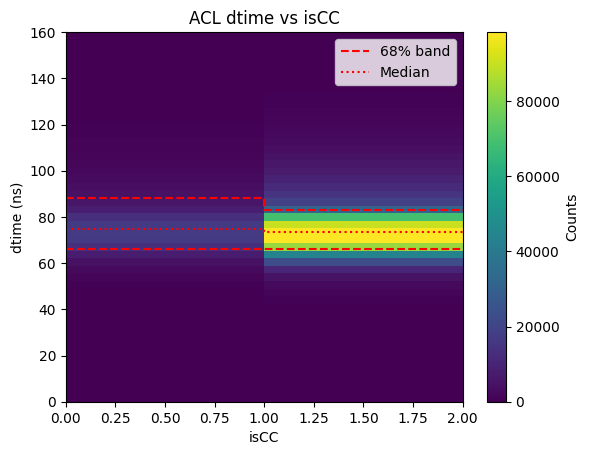

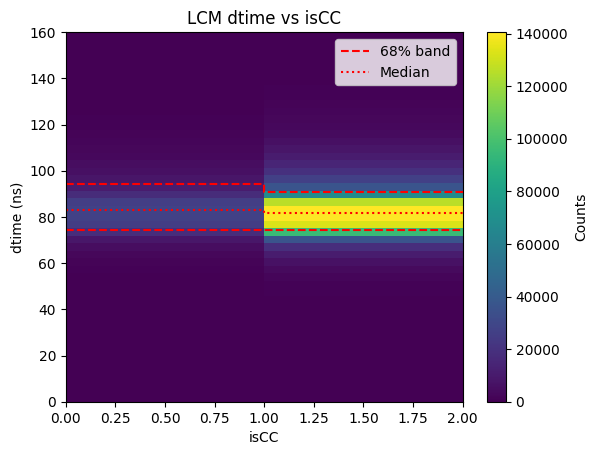

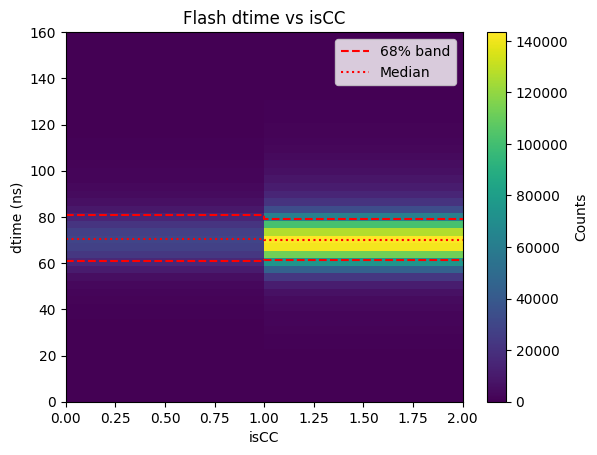

In [130]:
# plot dtime vs isCC as a heatmap
xrange = np.array([0, 1, 2])  # Assuming isCC is binary or categorical
yrange = np.linspace(0, 160, 50)

plot_heatmap(
    df_truth_reco,
    x_col='isCC',
    y_col='trap_0_dtime_ns',
    title='ACL dtime vs isCC',
    xlabel='isCC',
    ylabel='dtime (ns)',
    xrange=xrange,
    yrange=yrange,
    logx=False,
    logy=False
)
plot_heatmap(
    df_truth_reco,
    x_col='isCC',
    y_col='trap_1_dtime_ns',
    title='LCM dtime vs isCC',
    xlabel='isCC',
    ylabel='dtime (ns)',
    xrange=xrange,
    yrange=yrange,
    logx=False,
    logy=False
)
plot_heatmap(
    df_truth_reco,
    x_col='isCC',
    y_col='flash_dtime_ns',
    title='Flash dtime vs isCC',
    xlabel='isCC',
    ylabel='dtime (ns)',
    xrange=xrange,
    yrange=yrange,
    logx=False,
    logy=False
)

isCC = 0: 129078 / 288139 = 0.44797129163355187
isCC = 1: 644305 / 1287533 = 0.5004182417072028
isCC = 0: 201612 / 288139 = 0.6997039623237395
isCC = 1: 921722 / 1287533 = 0.7158822336980878
isCC = 0: 217194 / 288139 = 0.7537820288124829
isCC = 1: 976879 / 1287533 = 0.7587215240308404


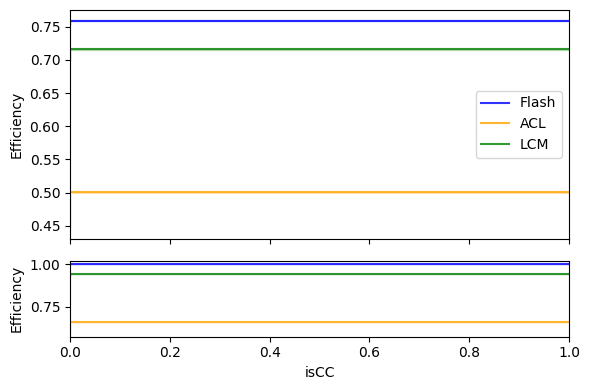

In [131]:
# Efficiency as a function of isCC
acl_true_isCC = df_truth_reco['isCC'].dropna()
acl_true_reco_isCC = acl_true_rec['isCC'].dropna()
# print ratio
print(f"isCC = 0: {acl_true_reco_isCC[acl_true_reco_isCC == 0].shape[0]} / {acl_true_isCC[acl_true_isCC == 0].shape[0]} = {acl_true_reco_isCC[acl_true_reco_isCC == 0].shape[0] / acl_true_isCC[acl_true_isCC == 0].shape[0] if acl_true_isCC[acl_true_isCC == 0].shape[0] > 0 else float('nan')}")
print(f"isCC = 1: {acl_true_reco_isCC[acl_true_reco_isCC == 1].shape[0]} / {acl_true_isCC[acl_true_isCC == 1].shape[0]} = {acl_true_reco_isCC[acl_true_reco_isCC == 1].shape[0] / acl_true_isCC[acl_true_isCC == 1].shape[0] if acl_true_isCC[acl_true_isCC == 1].shape[0] > 0 else float('nan')}")

lcm_true_isCC = df_truth_reco['isCC'].dropna()
lcm_true_reco_isCC = lcm_true_rec['isCC'].dropna()
# print ratio
print(f"isCC = 0: {lcm_true_reco_isCC[lcm_true_reco_isCC == 0].shape[0]} / {lcm_true_isCC[lcm_true_isCC == 0].shape[0]} = {lcm_true_reco_isCC[lcm_true_reco_isCC == 0].shape[0] / lcm_true_isCC[lcm_true_isCC == 0].shape[0] if lcm_true_isCC[lcm_true_isCC == 0].shape[0] > 0 else float('nan')}")
print(f"isCC = 1: {lcm_true_reco_isCC[lcm_true_reco_isCC == 1].shape[0]} / {lcm_true_isCC[lcm_true_isCC == 1].shape[0]} = {lcm_true_reco_isCC[lcm_true_reco_isCC == 1].shape[0] / lcm_true_isCC[lcm_true_isCC == 1].shape[0] if lcm_true_isCC[lcm_true_isCC == 1].shape[0] > 0 else float('nan')}")

flash_true_isCC = df_truth_reco['isCC'].dropna()
flash_true_reco_isCC = flash_true_rec['isCC'].dropna()
# print ratio
print(f"isCC = 0: {flash_true_reco_isCC[flash_true_reco_isCC == 0].shape[0]} / {flash_true_isCC[flash_true_isCC == 0].shape[0]} = {flash_true_reco_isCC[flash_true_reco_isCC == 0].shape[0] / flash_true_isCC[flash_true_isCC == 0].shape[0] if flash_true_isCC[flash_true_isCC == 0].shape[0] > 0 else float('nan')}")
print(f"isCC = 1: {flash_true_reco_isCC[flash_true_reco_isCC == 1].shape[0]} / {flash_true_isCC[flash_true_isCC == 1].shape[0]} = {flash_true_reco_isCC[flash_true_reco_isCC == 1].shape[0] / flash_true_isCC[flash_true_isCC == 1].shape[0] if flash_true_isCC[flash_true_isCC == 1].shape[0] > 0 else float('nan')}")


# not sure this is working!

# Use categorical bins for isCC
bins=np.array([0, 1, 2])
plot_histogram_ratio_with_error(
    df_A=[flash_true_reco_isCC, acl_true_reco_isCC, lcm_true_reco_isCC],
    df_B=[flash_true_isCC, acl_true_isCC, lcm_true_isCC],
    legend=['Flash', 'ACL', 'LCM'],
    cols=['blue', 'orange', 'green'],
    bins=bins,
    xlabel='isCC',
    ylabel='Efficiency',
    neg=False,
    xscale='linear'
)